


test 6 hr forecast for all SimVP models to compare

In [ ]:
# ============================================================
# Model-agnostic evaluator for MANY models vs persistence
# - Computes MAE, MSE, RMSE, R^2 for entire validation period
# - Computes Skill vs Persistence per pollutant: 1 - MSE_model/MSE_persist
# - Ranks models per pollutant (by Skill, higher is better)
#
# Assumptions (edit if needed):
# - NPZ contains X (T,Cx,H,W), Y (T,Cy,H,W), Mask (T,Cy,H,W)
# - time step is 6 hours, starting at 2022-01-01 00:00 UTC
# - validation period is 2024-12-21 00:00 to 2025-06-30 18:00 UTC
# ============================================================

import os, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import sys, os

print("Python:", sys.version)
print("Working dir:", os.getcwd())
print("Files in cwd:", os.listdir("."))

# Check for shadowing
print("torch.py exists?", os.path.exists("torch.py"))
print("torch folder exists?", os.path.exists("torch"))

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')


# -------------------------
# Paths (edit)
# -------------------------
DRIVE_NPZ_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"

# Optional: copy NPZ from Drive -> local disk to avoid Drive disconnect issues
LOCAL_NPZ_PATH = "/content/processed_simvp_data.npz"

# -------------------------
# Core config
# -------------------------
CONFIG = {
    "History": 8,     # 48h
    "Horizon": 1,     # 6h ahead
    "Batch_Size": 16,
    "Device": "cuda" if torch.cuda.is_available() else "cpu",
}

# Validation time window (UTC)
VAL_START = pd.Timestamp("2024-12-21 00:00:00", tz="UTC")
VAL_END   = pd.Timestamp("2025-06-30 18:00:00", tz="UTC")

# Pollutant channel labels in YOUR Y (based on your NC header)
# (0..5) = CO, NO2, O3, PM10, PM2.5, SO2
POLLUTANT_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

print("DEVICE:", CONFIG["Device"])


# ============================================================
# 0) Robust NPZ load (copy to local)
# ============================================================
def load_npz_safe(drive_path=DRIVE_NPZ_PATH, local_path=LOCAL_NPZ_PATH):
    if not os.path.exists(drive_path):
        raise FileNotFoundError(f"Missing: {drive_path}")
    if (not os.path.exists(local_path)) or (os.path.getsize(local_path) != os.path.getsize(drive_path)):
        print("Copying NPZ from Drive -> local disk ...")
        shutil.copy2(drive_path, local_path)
    print("Loading NPZ:", local_path)
    data = np.load(local_path)
    X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
    print("X:", X_full.shape, "Y:", Y_full.shape, "Mask:", M_full.shape)
    return X_full, Y_full, M_full


# ============================================================
# 1) Build val indices using your real date split
# ============================================================
def make_val_indices(T, history, horizon, start_time_utc="2022-01-01 00:00:00"):
    time_index = pd.date_range(pd.Timestamp(start_time_utc, tz="UTC"), periods=T, freq="6h")
    total_len = T - history - horizon + 1
    if total_len <= 0:
        raise ValueError("Not enough timesteps for history/horizon")

    i_all = np.arange(total_len)
    origin_t = i_all + history - 1
    target_t = origin_t + horizon
    target_times = time_index[target_t]

    val_mask = (target_times >= VAL_START) & (target_times <= VAL_END)
    val_indices = i_all[val_mask].tolist()

    print("Total samples possible:", total_len)
    print("VAL samples:", len(val_indices))
    if len(val_indices):
        print("VAL target time range:", target_times[val_mask].min(), "→", target_times[val_mask].max())

    return val_indices, time_index


# ============================================================
# 2) Dataset that returns origin_t and target_t (for persistence)
# ============================================================
class EvalDataset(Dataset):
    def __init__(self, X, Y, M, indices, history, horizon):
        self.X = X
        self.Y = Y
        self.M = M
        self.indices = list(indices)
        self.history = history
        self.horizon = horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, k):
        i = self.indices[k]
        x_seq = self.X[i : i + self.history]  # (history, Cx, H, W)
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])  # (history*Cx,H,W)

        origin_t = i + self.history - 1
        target_t = origin_t + self.horizon

        y = self.Y[target_t]     # (Cy,H,W)
        m = self.M[target_t]     # (Cy,H,W)  (assumed)

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y).float(),
                torch.from_numpy(m).float(),
                origin_t,
                target_t)


# ============================================================
# 3) Metrics helpers (masked, full val period)
# ============================================================
def _ensure_mask_bc_hw(mask, C):
    # mask: [B,C,H,W] or [B,H,W] or [B,1,H,W]
    if mask.dim() == 3:
        mask = mask.unsqueeze(1)
    if mask.shape[1] == 1:
        mask = mask.expand(-1, C, -1, -1)
    return mask

@torch.no_grad()
def compute_y_mean(val_loader, device):
    """Compute masked mean of y for R^2 (per channel)."""
    msum = None
    ysum = None
    first = True
    for x, y, m, origin_t, target_t in val_loader:
        y = y.to(device)
        m = m.to(device)
        C = y.shape[1]
        mC = _ensure_mask_bc_hw(m, C)

        if first:
            msum = torch.zeros(C, device=device)
            ysum = torch.zeros(C, device=device)
            first = False

        msum += mC.sum(dim=(0,2,3))
        ysum += (y * mC).sum(dim=(0,2,3))
    y_mean = ysum / (msum + 1e-8)
    return y_mean, msum

@torch.no_grad()
def evaluate_model_and_persistence(model, val_loader, Y_full_np, y_mean, device):
    """
    Returns per-channel + overall:
    MAE, MSE, RMSE, R2 for model and persistence
    plus Skill vs persistence = 1 - MSE_model/MSE_persist (per channel + overall)
    """
    C = None
    # sums for model
    abs_m = None
    sq_m  = None
    ss_res_m = None
    ss_tot = None

    # sums for persistence
    abs_p = None
    sq_p  = None
    ss_res_p = None

    msum = None

    for x, y, m, origin_t, target_t in val_loader:
        x = x.to(device)
        y = y.to(device)
        m = m.to(device)

        C = y.shape[1]
        mC = _ensure_mask_bc_hw(m, C)

        # model pred
        pred = model(x)

        # persistence pred: y(t+6)=y(t) -> use Y_full[origin_t]
        # origin_t is a python int list in batch; build numpy slice then torch
        origin_idx = np.array(origin_t)
        y_pers = torch.from_numpy(Y_full_np[origin_idx]).float().to(device)  # (B,C,H,W)

        # init
        if abs_m is None:
            abs_m = torch.zeros(C, device=device)
            sq_m  = torch.zeros(C, device=device)
            ss_res_m = torch.zeros(C, device=device)
            ss_tot = torch.zeros(C, device=device)

            abs_p = torch.zeros(C, device=device)
            sq_p  = torch.zeros(C, device=device)
            ss_res_p = torch.zeros(C, device=device)

            msum = torch.zeros(C, device=device)

        # accumulate mask counts
        msum += mC.sum(dim=(0,2,3))

        # model errors
        diff_m = (pred - y)
        abs_m += (diff_m.abs() * mC).sum(dim=(0,2,3))
        sq_m  += ((diff_m**2) * mC).sum(dim=(0,2,3))
        ss_res_m += (((pred - y)**2) * mC).sum(dim=(0,2,3))

        # persistence errors
        diff_p = (y_pers - y)
        abs_p += (diff_p.abs() * mC).sum(dim=(0,2,3))
        sq_p  += ((diff_p**2) * mC).sum(dim=(0,2,3))
        ss_res_p += (((y_pers - y)**2) * mC).sum(dim=(0,2,3))

        # SS_tot (same for both): sum((y - y_mean)^2)
        ss_tot += (((y - y_mean[None,:,None,None])**2) * mC).sum(dim=(0,2,3))

    eps = 1e-8
    # per-channel metrics
    mae_m = (abs_m / (msum + eps)).detach().cpu().numpy()
    mse_m = (sq_m  / (msum + eps)).detach().cpu().numpy()
    rmse_m = np.sqrt(mse_m)
    r2_m  = (1.0 - (ss_res_m / (ss_tot + eps))).detach().cpu().numpy()

    mae_p = (abs_p / (msum + eps)).detach().cpu().numpy()
    mse_p = (sq_p  / (msum + eps)).detach().cpu().numpy()
    rmse_p = np.sqrt(mse_p)
    r2_p  = (1.0 - (ss_res_p / (ss_tot + eps))).detach().cpu().numpy()

    skill = 1.0 - (mse_m / (mse_p + eps))

    # overall (mask-weighted aggregate)
    mae_m_all = (abs_m.sum() / (msum.sum() + eps)).item()
    mse_m_all = (sq_m.sum()  / (msum.sum() + eps)).item()
    rmse_m_all = float(np.sqrt(mse_m_all))
    r2_m_all = (1.0 - (ss_res_m.sum() / (ss_tot.sum() + eps))).item()

    mae_p_all = (abs_p.sum() / (msum.sum() + eps)).item()
    mse_p_all = (sq_p.sum()  / (msum.sum() + eps)).item()
    rmse_p_all = float(np.sqrt(mse_p_all))
    r2_p_all = (1.0 - (ss_res_p.sum() / (ss_tot.sum() + eps))).item()

    skill_all = 1.0 - (mse_m_all / (mse_p_all + eps))

    return {
        "model": {"MAE": mae_m_all, "MSE": mse_m_all, "RMSE": rmse_m_all, "R2": r2_m_all,
                  "MAE_c": mae_m, "MSE_c": mse_m, "RMSE_c": rmse_m, "R2_c": r2_m},
        "persist": {"MAE": mae_p_all, "MSE": mse_p_all, "RMSE": rmse_p_all, "R2": r2_p_all,
                    "MAE_c": mae_p, "MSE_c": mse_p, "RMSE_c": rmse_p, "R2_c": r2_p},
        "skill": {"Skill": skill_all, "Skill_c": skill},
    }


# ============================================================
# 4) Model loaders (standard SimVP & residual SimVP) + auto hid sizes
#    (You can add more model types if needed.)
# ============================================================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        # GroupNorm groups: try 8, then 4, else 2
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2) if transpose else nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T):
        super().__init__()
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1),
        )
    def forward(self, x):
        return self.dec(self.mid(self.enc(x)))

class ResidualSimVP(SimVP):
    def __init__(self, in_channels, out_channels, hid_S, hid_T):
        super().__init__(in_channels, out_channels, hid_S, hid_T)
    def forward(self, x):
        delta = super().forward(x)
        last_known_pollution = x[:, -6:, :, :]
        return last_known_pollution + delta

def infer_hids_from_ckpt(state_dict):
    # Works for the enc/dec Sequential-key style: enc.0.conv.weight etc.
    # hid_S = out_channels of enc.0.conv.weight
    hid_S = int(state_dict["enc.0.conv.weight"].shape[0])
    # hid_T = out_channels of mid.0.conv1.conv.weight
    hid_T = int(state_dict["mid.0.conv1.conv.weight"].shape[0])
    return hid_S, hid_T

def load_model_from_ckpt(ckpt_path, model_type, in_dim, out_dim, device):
    state = torch.load(ckpt_path, map_location=device)
    hid_S, hid_T = infer_hids_from_ckpt(state)
    if model_type == "simvp":
        model = SimVP(in_dim, out_dim, hid_S, hid_T).to(device)
    elif model_type == "residual":
        model = ResidualSimVP(in_dim, out_dim, hid_S, hid_T).to(device)
    else:
        raise ValueError("model_type must be 'simvp' or 'residual'")
    model.load_state_dict(state, strict=True)
    model.eval()
    return model


# ============================================================
# 5) MAIN: Evaluate many models, compute skill, rank
# ============================================================
def evaluate_many_models(model_specs, X_full, Y_full, M_full):
    """
    model_specs: list of dicts like:
      {"name": "resid_peak10", "ckpt": "...pth", "type": "residual"}
      {"name": "simvp_base", "ckpt": "...pth", "type": "simvp"}
    """
    T = X_full.shape[0]
    Cx = X_full.shape[1]
    Cy = Y_full.shape[1]
    assert Cy == len(POLLUTANT_NAMES), "Update POLLUTANT_NAMES to match Y channels"

    val_indices, time_index = make_val_indices(T, CONFIG["History"], CONFIG["Horizon"])
    val_ds = EvalDataset(X_full, Y_full, M_full, val_indices, CONFIG["History"], CONFIG["Horizon"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

    # pass 1 compute y_mean
    y_mean, msum = compute_y_mean(val_loader, CONFIG["Device"])

    # Evaluate each model
    rows = []
    per_pollutant_rows = []

    for spec in model_specs:
        name = spec["name"]
        ckpt = spec["ckpt"]
        mtype = spec["type"]
        if not os.path.exists(ckpt):
            print(f"⚠️ Missing checkpoint for {name}: {ckpt}")
            continue

        in_dim = Cx * CONFIG["History"]
        out_dim = Cy

        print(f"\n=== Evaluating {name} ({mtype}) ===")
        model = load_model_from_ckpt(ckpt, mtype, in_dim, out_dim, CONFIG["Device"])

        res = evaluate_model_and_persistence(model, val_loader, Y_full, y_mean, CONFIG["Device"])

        # overall summary row
        rows.append({
            "model": name,
            "type": mtype,
            "MAE": res["model"]["MAE"],
            "MSE": res["model"]["MSE"],
            "RMSE": res["model"]["RMSE"],
            "R2": res["model"]["R2"],
            "Skill_vs_Persist": res["skill"]["Skill"],
            "Persist_MSE": res["persist"]["MSE"],
            "Persist_R2": res["persist"]["R2"],
        })

        # per pollutant rows
        for j, pol in enumerate(POLLUTANT_NAMES):
            per_pollutant_rows.append({
                "model": name,
                "type": mtype,
                "pollutant": pol,
                "MAE": float(res["model"]["MAE_c"][j]),
                "MSE": float(res["model"]["MSE_c"][j]),
                "RMSE": float(res["model"]["RMSE_c"][j]),
                "R2": float(res["model"]["R2_c"][j]),
                "Skill_vs_Persist": float(res["skill"]["Skill_c"][j]),
                "Persist_MSE": float(res["persist"]["MSE_c"][j]),
                "Persist_R2": float(res["persist"]["R2_c"][j]),
            })

    overall_df = pd.DataFrame(rows).sort_values("Skill_vs_Persist", ascending=False)
    per_pol_df = pd.DataFrame(per_pollutant_rows)

    # ranking per pollutant by skill
    ranked = (per_pol_df
              .sort_values(["pollutant", "Skill_vs_Persist"], ascending=[True, False])
              .groupby("pollutant", group_keys=False)
              .apply(lambda g: g.assign(rank=np.arange(1, len(g)+1))))

    return overall_df, per_pol_df, ranked


# ============================================================
# 6) Example usage
#    Add your checkpoints here. You can compare any number.
# ============================================================
model_specs = [
    {"name": "residual_antilag_gpt_pro_Jesse", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_antilag_pro.pth", "type": "residual"},
    {"name": "residual_antilag_gpt", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_antilag.pth", "type": "residual"},
    {"name": "residual_antilag", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v7.pth", "type": "residual"},
    {"name": "simvp_standard", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v1.pth", "type": "simvp"},
    {"name": "residual_peak10", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v4.pth", "type": "residual"},
    {"name": "simvp_standard_MSE_Loss", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v5.pth", "type": "simvp"},
    {"name": "residual_MSE_Loss", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v6.pth", "type": "residual"}
]

# Load data
X_full, Y_full, M_full = load_npz_safe()

# Run after you fill in model_specs above:
overall_df, per_pol_df, ranked_df = evaluate_many_models(model_specs, X_full, Y_full, M_full)

# Print summaries:
display(overall_df)
display(ranked_df[ranked_df["rank"] <= 5])






Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Working dir: /content
Files in cwd: ['.config', 'drive', 'best_simvp_antilag.pth', 'processed_simvp_data.npz', 'sample_data']
torch.py exists? False
torch folder exists? False
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEVICE: cuda
Loading NPZ: /content/processed_simvp_data.npz
X: (5108, 32, 88, 120) Y: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Total samples possible: 5100
VAL samples: 768
VAL target time range: 2024-12-21 00:00:00+00:00 → 2025-06-30 18:00:00+00:00

=== Evaluating residual_antilag_gpt_pro_Jesse (residual) ===

=== Evaluating residual_antilag_gpt (residual) ===

=== Evaluating residual_antilag (residual) ===

=== Evaluating simvp_standard (simvp) ===

=== Evaluating residual_peak10 (residual) ===

=== Evaluating simvp_standard_MSE_Loss (simvp) ===

=== Evaluating residual_MSE_Loss (residual) ===


/tmp/ipython-input-1902170189.py:424: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(rank=np.arange(1, len(g)+1))))


,model,type,MAE,MSE,RMSE,R2,Skill_vs_Persist,Persist_MSE,Persist_R2
5,simvp_standard_MSE_Loss,simvp,0.026715,0.001783,0.042229,0.637660,0.371528,0.002838,0.423461
2,residual_antilag,residual,0.026389,0.001934,0.043979,0.607019,0.318381,0.002838,0.423461
6,residual_MSE_Loss,residual,0.026156,0.001942,0.044071,0.605362,0.315507,0.002838,0.423461
1,residual_antilag_gpt,residual,0.033079,0.002712,0.052073,0.449061,0.044406,0.002838,0.423461
4,residual_peak10,residual,0.031432,0.002838,0.053271,0.423414,-0.000079,0.002838,0.423461
0,residual_antilag_gpt_pro_Jesse,residual,0.036750,0.003449,0.058730,0.299172,-0.215574,0.002838,0.423461
3,simvp_standard,simvp,0.041200,0.003809,0.061719,0.226032,-0.342435,0.002838,0.423461


,model,type,pollutant,MAE,MSE,RMSE,R2,Skill_vs_Persist,Persist_MSE,Persist_R2,rank
24,residual_peak10,residual,CO,0.000903,0.000001,0.001174,0.347847,0.003459,0.000001,0.350316,1
0,residual_antilag_gpt_pro_Jesse,residual,CO,0.001245,0.000002,0.001574,-0.172100,-0.791060,0.000001,0.350316,2
36,residual_MSE_Loss,residual,CO,0.001694,0.000005,0.002237,-1.369322,-2.620507,0.000001,0.350316,3
12,residual_antilag,residual,CO,0.001825,0.000006,0.002433,-1.801866,-3.281468,0.000001,0.350316,4
30,simvp_standard_MSE_Loss,simvp,CO,0.001876,0.000006,0.002448,-1.837081,-3.335279,0.000001,0.350316,5
13,residual_antilag,residual,NO2,0.016517,0.000772,0.027776,0.546411,0.117230,0.000874,0.486181,1
37,residual_MSE_Loss,residual,NO2,0.016037,0.000781,0.027953,0.540610,0.105942,0.000874,0.486181,2
25,residual_peak10,residual,NO2,0.016667,0.000874,0.029562,0.486190,0.000029,0.000874,0.486181,3
31,simvp_standard_MSE_Loss,simvp,NO2,0.021969,0.001033,0.032143,0.392577,-0.182159,0.000874,0.486181,4
7,residual_antilag_gpt,residual,NO2,0.022490,0.001049,0.032394,0.383034,-0.200732,0.000874,0.486181,5


Stressed test

Mounting Google Drive...
Mounted at /content/drive
Copying NPZ from Drive -> local disk...
Local NPZ size: 4011023020
Device: cuda
>>> Loading processed data...
X_full: (5108, 32, 88, 120) Y_full: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Val samples: 765
in_dim: 256 out_dim: 6

STRESS TEST: residual_antilag_gpt  (residual)
Checkpoint: /content/drive/MyDrive/graphcast_project/best_simvp_antilag.pth
  Hid_S=64 Hid_T=256
Scanning validation set for maximum PM2.5 spike (The Fire)...
Found Peak PM2.5 at Validation Index: 209


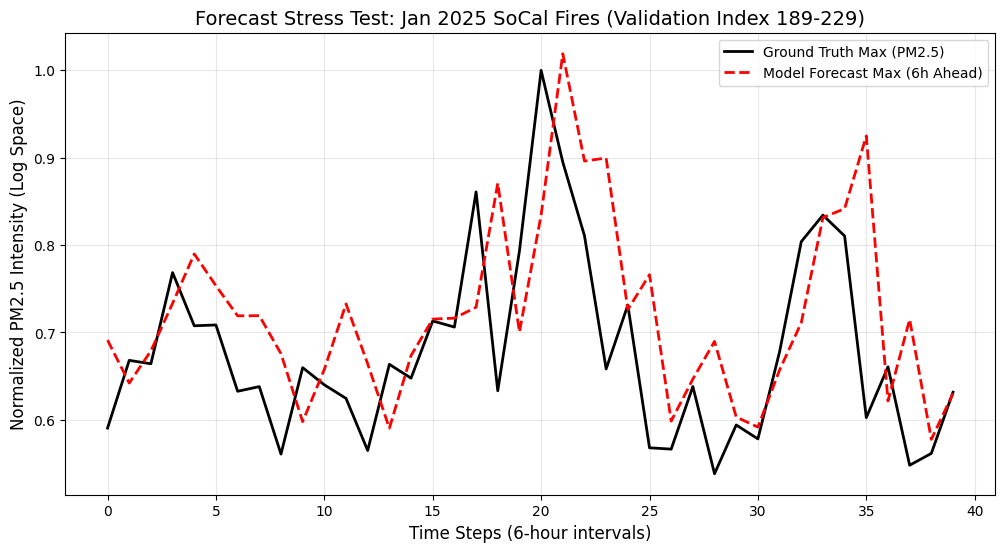

True Spike Amplitude: 0.4616
Predicted Spike Amplitude: 0.4414
Capture Ratio: 95.6%

==================== STRESS TEST SUMMARY ====================
                  model      type  \
0  residual_antilag_gpt  residual   

                                                ckpt  Hid_S  Hid_T  true_jump  \
0  /content/drive/MyDrive/graphcast_project/best_...     64    256   0.461645   

   pred_jump  capture_ratio_pct  
0    0.44142          95.618867  


In [ ]:
# ============================================================
# STRESS TEST ALL MODELS (NO TRAINING)
# - Loads processed_simvp_data.npz once
# - Builds val_loader once
# - For each model checkpoint:
#     * copy ckpt to local
#     * auto-detect Hid_S/Hid_T
#     * load either SimVP or ResidualSimVP
#     * run wildfire stress test (same logic)
# ============================================================

import os, shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --------------------------
# PATHS
# --------------------------
NPZ_DRIVE  = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'
NPZ_LOCAL  = '/content/processed_simvp_data.npz'

# Copy NPZ to local (Drive-safe)
print("Copying NPZ from Drive -> local disk...")
shutil.copy2(NPZ_DRIVE, NPZ_LOCAL)
assert os.path.exists(NPZ_LOCAL), f"❌ Missing NPZ local: {NPZ_LOCAL}"
print("Local NPZ size:", os.path.getsize(NPZ_LOCAL))

# --------------------------
# CONFIG (same)
# --------------------------
CONFIG = {
    'History': 8,
    'Horizon': 1,
    'Batch_Size': 16,
    'Hid_S': 128,   # placeholder; overwritten from ckpt
    'Hid_T': 256,   # placeholder; overwritten from ckpt
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}
print("Device:", CONFIG["Device"])

# ============================================================
# 1) DATASET (same)
# ============================================================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        # Target
        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ============================================================
# 2) MODEL BUILDING BLOCKS (shared)
# ============================================================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()

        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)

        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

# --- Standard SimVP (direct prediction) ---
class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        return self.dec(mid)

# --- Residual SimVP (persistence + delta) ---
class ResidualSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        delta = self.dec(mid)
        last_known_pollution = x[:, -6:, :, :]
        return last_known_pollution + delta

# ============================================================
# 3) LOAD DATA + BUILD val_loader ONCE (same split logic)
# ============================================================
print(">>> Loading processed data...")
data = np.load(NPZ_LOCAL)
X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

num_vars = X_full.shape[1]
in_dim = num_vars * CONFIG['History']
out_dim = Y_full.shape[1]  # should be 6

total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
train_idx_end = int(total_len * 0.85)

val_indices = range(train_idx_end, total_len)
val_ds = PollutionDataset(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "Mask:", M_full.shape)
print("Val samples:", len(val_ds))
print("in_dim:", in_dim, "out_dim:", out_dim)

# ============================================================
# 4) Your stress test (LOGIC UNCHANGED)
#    (Only change is: parameterize channel idx for PM2.5 = 4)
# ============================================================
PM25_CHANNEL = 4  # ["CO","NO2","O3","PM10","PM2.5","SO2"]

def plot_wildfire_event(model, val_loader, device='cuda'):
    """
    Plots the Jan 2025 Palisades/Eaton Fire event.
    """
    model.eval()

    print("Scanning validation set for maximum PM2.5 spike (The Fire)...")

    all_preds_max = []
    all_targets_max = []

    # Run inference on the whole validation set
    with torch.no_grad():
        for x, y, mask in val_loader:
            x = x.to(device)
            pred = model(x)

            # We take the MAX value over the grid (Spatial Max) to catch the fire hotspot
            all_preds_max.append(pred[:, PM25_CHANNEL, :, :].amax(dim=(1,2)).cpu().numpy())
            all_targets_max.append(y[:, PM25_CHANNEL, :, :].amax(dim=(1,2)).numpy())

    # Flatten into a single time series
    y_true = np.concatenate(all_targets_max)
    y_pred = np.concatenate(all_preds_max)

    # 2. LOCATE THE FIRE (The highest peak in the test set)
    peak_idx = np.argmax(y_true)
    print(f"Found Peak PM2.5 at Validation Index: {peak_idx}")

    # Zoom in: 10 days before and 10 days after the peak
    start_slice = max(0, peak_idx - 20)
    end_slice = min(len(y_true), peak_idx + 20)

    slice_true = y_true[start_slice:end_slice]
    slice_pred = y_pred[start_slice:end_slice]

    # 3. PLOT
    plt.figure(figsize=(12, 6))
    plt.plot(slice_true, label='Ground Truth Max (PM2.5)', color='black', linewidth=2)
    plt.plot(slice_pred, label='Model Forecast Max (6h Ahead)', color='red', linestyle='--', linewidth=2)

    plt.title(f"Forecast Stress Test: Jan 2025 SoCal Fires (Validation Index {start_slice}-{end_slice})", fontsize=14)
    plt.ylabel("Normalized PM2.5 Intensity (Log Space)", fontsize=12)
    plt.xlabel("Time Steps (6-hour intervals)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. QUANTIFY THE 'JUMP' CAPTURE
    true_jump = slice_true.max() - slice_true.min()
    pred_jump = slice_pred.max() - slice_pred.min()
    print(f"True Spike Amplitude: {true_jump:.4f}")
    print(f"Predicted Spike Amplitude: {pred_jump:.4f}")
    print(f"Capture Ratio: {pred_jump/true_jump*100:.1f}%")

# ============================================================
# 5) Model loader for EACH checkpoint
#    - copies ckpt to local for Drive stability
#    - infers Hid_S/Hid_T from ckpt
#    - loads correct architecture (simvp vs residual)
# ============================================================
def load_model_for_ckpt(ckpt_drive_path, model_kind):
    """
    model_kind: "simvp" or "residual"
    """
    assert model_kind in ("simvp", "residual")

    # Copy ckpt to local
    ckpt_local_path = "/content/" + os.path.basename(ckpt_drive_path)
    shutil.copy2(ckpt_drive_path, ckpt_local_path)
    assert os.path.exists(ckpt_local_path), f"Missing local ckpt: {ckpt_local_path}"

    # Load state
    state = torch.load(ckpt_local_path, map_location=CONFIG["Device"])

    # Infer Hid_S/Hid_T from checkpoint (works for your enc/mid naming)
    CONFIG["Hid_S"] = int(state["enc.0.conv.weight"].shape[0])
    CONFIG["Hid_T"] = int(state["mid.0.conv1.conv.weight"].shape[0])
    print(f"  Hid_S={CONFIG['Hid_S']} Hid_T={CONFIG['Hid_T']}")

    # Build model
    if model_kind == "simvp":
        model = SimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG["Device"])
    else:
        model = ResidualSimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG["Device"])

    # Load weights
    model.load_state_dict(state, strict=True)
    model.eval()
    return model, ckpt_local_path

# ============================================================
# 6) LIST YOUR MODELS HERE
#    Fill in with your actual checkpoint files + type.
# ============================================================
MODEL_SPECS = [
    #{"name": "residual_antilag_gpt_pro_Jesse", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_antilag_pro.pth", "type": "residual"},
    {"name": "residual_antilag_gpt", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_antilag.pth", "type": "residual"},
    #{"name": "residual_antilag", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v7.pth", "type": "residual"},
    #{"name": "simvp_standard", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v1.pth", "type": "simvp"},
    #{"name": "residual_peak10", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v4.pth", "type": "residual"},
    #{"name": "simvp_standard_MSE_Loss", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v5.pth", "type": "simvp"},
    #{"name": "residual_MSE_Loss", "ckpt": "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v6.pth", "type": "residual"}
]

# ============================================================
# 7) RUN STRESS TEST FOR ALL MODELS
# ============================================================
assert len(MODEL_SPECS) > 0, "Please fill MODEL_SPECS with your checkpoints."

summary_rows = []

for spec in MODEL_SPECS:
    name = spec["name"]
    ckpt = spec["ckpt"]
    mtype = spec["type"]

    print("\n============================================================")
    print(f"STRESS TEST: {name}  ({mtype})")
    print("Checkpoint:", ckpt)

    if not os.path.exists(ckpt):
        print("  ⚠️ Missing ckpt, skipping.")
        continue

    model, ckpt_local = load_model_for_ckpt(ckpt, mtype)

    # run your stress test
    plot_wildfire_event(model, val_loader, device=CONFIG["Device"])

    # optional: capture one scalar summary for table
    # (same computation as inside plot_wildfire_event, but without changing its logic)
    # We'll re-run quickly, but only collecting jumps; this keeps the plotted function untouched.
    with torch.no_grad():
        all_preds_max = []
        all_targets_max = []
        for x, y, mask in val_loader:
            x = x.to(CONFIG["Device"])
            pred = model(x)
            all_preds_max.append(pred[:, PM25_CHANNEL, :, :].amax(dim=(1,2)).detach().cpu().numpy())
            all_targets_max.append(y[:, PM25_CHANNEL, :, :].amax(dim=(1,2)).numpy())
        y_true = np.concatenate(all_targets_max)
        y_pred = np.concatenate(all_preds_max)
        peak_idx = int(np.argmax(y_true))
        start_slice = max(0, peak_idx - 20)
        end_slice = min(len(y_true), peak_idx + 20)
        slice_true = y_true[start_slice:end_slice]
        slice_pred = y_pred[start_slice:end_slice]
        true_jump = float(slice_true.max() - slice_true.min())
        pred_jump = float(slice_pred.max() - slice_pred.min())
        ratio = float(pred_jump / (true_jump + 1e-12) * 100.0)

    summary_rows.append({
        "model": name,
        "type": mtype,
        "ckpt": ckpt,
        "Hid_S": CONFIG["Hid_S"],
        "Hid_T": CONFIG["Hid_T"],
        "true_jump": true_jump,
        "pred_jump": pred_jump,
        "capture_ratio_pct": ratio,
    })

# Show summary ranking
import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values("capture_ratio_pct", ascending=False)
print("\n==================== STRESS TEST SUMMARY ====================")
print(summary_df)


Test SimVPv2 6-72 hours results

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying NPZ/CKPT to local disk...
Local NPZ: /content/processed_simvp_data.npz exists: True size: 4011023020
Local CKPT: /content/best_simvpv2_72h.pth exists: True size: 23906181
Device: cuda
Loading NPZ...
VAL samples: 764
VAL target time span (covers all leads): 2024-12-19 06:00:00+00:00  →  2025-06-30 18:00:00+00:00
Loading checkpoint...
✅ Loaded: /content/best_simvpv2_72h.pth

=== 6h (lead=6) metrics (compare with other 6h models) ===
pollutant  RMSE_model  RMSE_pers  Skill_RMSE  R2_model  R2_pers
       CO    0.001552   0.001167   -0.329653 -0.123993 0.364260
      NO2    0.033434   0.029684   -0.126317  0.349716 0.487397
       O3    0.013605   0.011979   -0.135751  0.123041 0.320151
     PM10    0.084710   0.076682   -0.104686  0.285121 0.414193
    PM2.5    0.081513   0.074050   -0.100777  0.357005 0.469349
      SO2    0.0729

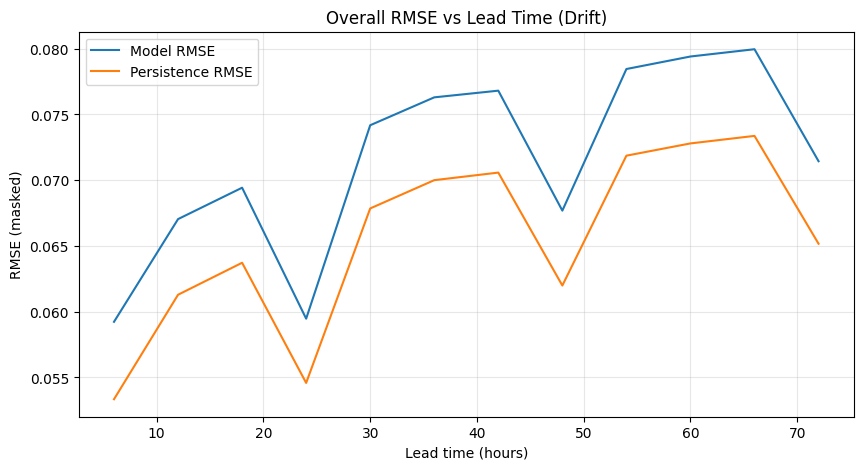

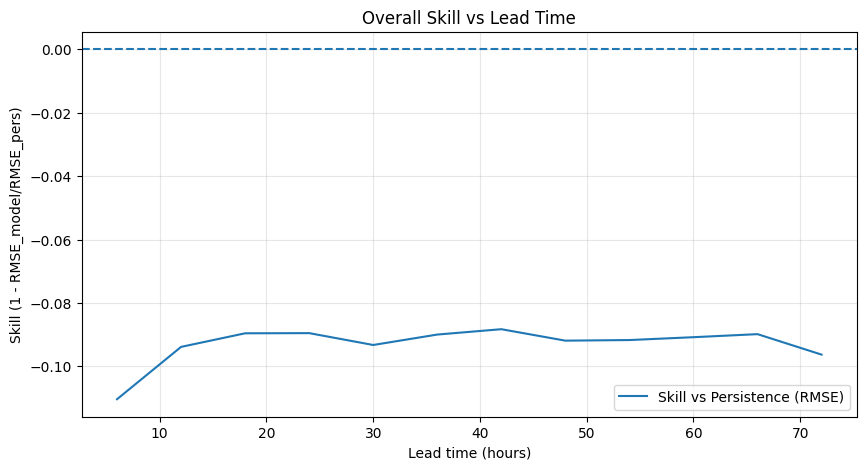

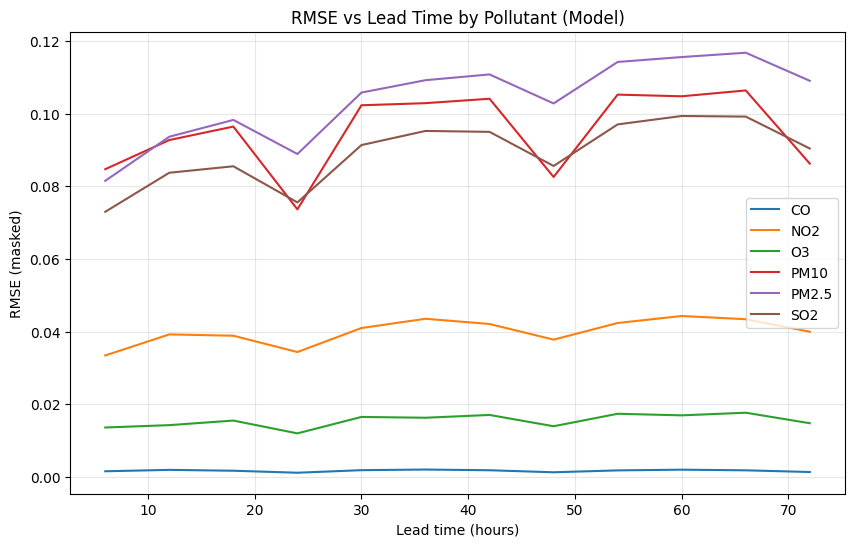

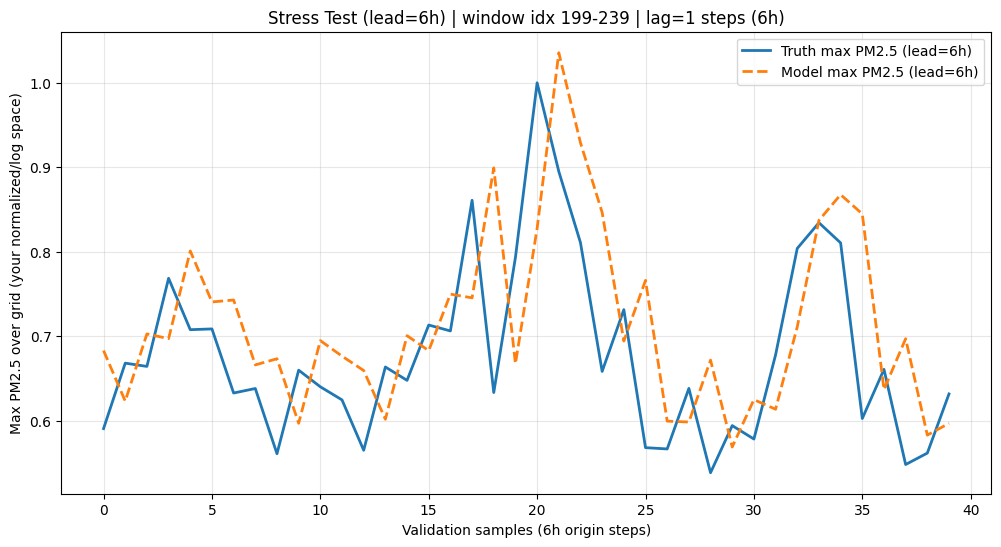

Lead 6h | True spike amplitude: 0.4616 | Pred spike amplitude: 0.4668 | Capture ratio: 101.1%
Lead 6h | Peak lag in window: 1 steps (6 hours)


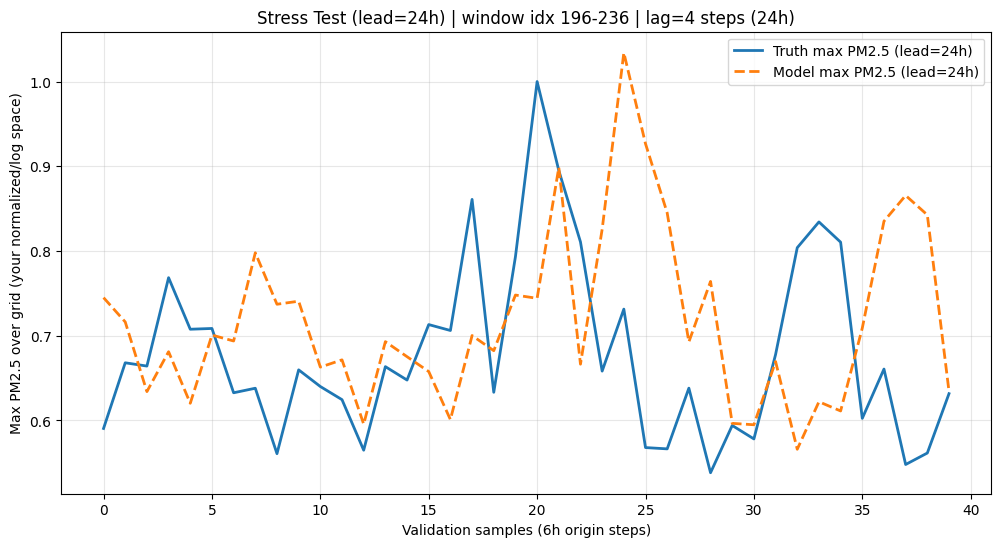

Lead 24h | True spike amplitude: 0.4616 | Pred spike amplitude: 0.4680 | Capture ratio: 101.4%
Lead 24h | Peak lag in window: 4 steps (24 hours)


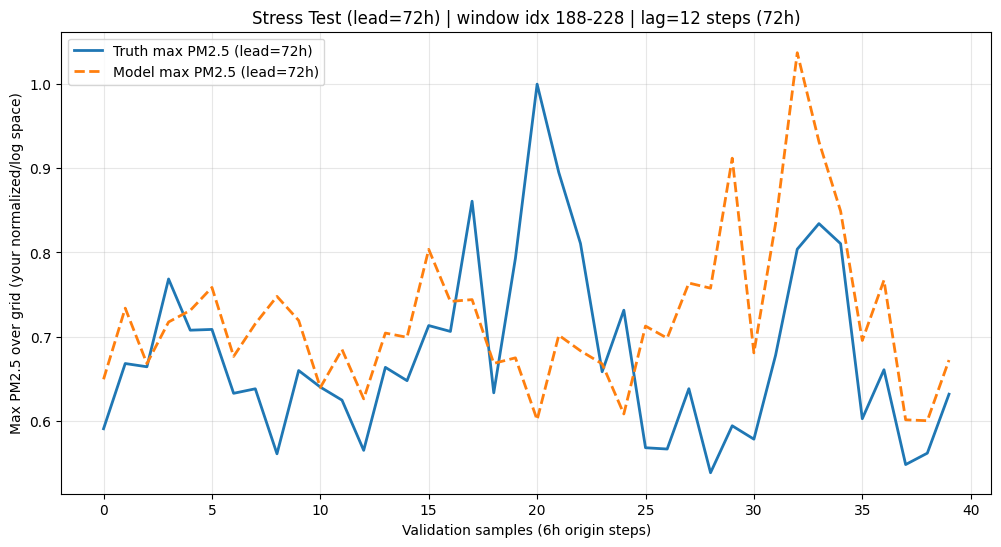

Lead 72h | True spike amplitude: 0.4616 | Pred spike amplitude: 0.4372 | Capture ratio: 94.7%
Lead 72h | Peak lag in window: 12 steps (72 hours)


In [ ]:
# ============================================================
# EVALUATION-ONLY: SimVPv2 72h (12x6h) metrics + persistence + drift + stress test
# - No training
# - Computes metrics for lead times: 6,12,...,72h
# - Compares lead=6h to other models easily (lead_idx=0)
# ============================================================

import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 0) Mount Drive + (optional) copy NPZ/CKPT to local disk for stability
# ----------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive")

NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/best_simvpv2_72h.pth"

# Optional local copies (recommended if Drive I/O disconnects)
NPZ_PATH  = "/content/processed_simvp_data.npz"
CKPT_PATH = "/content/best_simvpv2_72h.pth"

print("Copying NPZ/CKPT to local disk...")
assert os.path.exists(NPZ_DRIVE),  f"Missing NPZ on Drive: {NPZ_DRIVE}"
assert os.path.exists(CKPT_DRIVE), f"Missing CKPT on Drive: {CKPT_DRIVE}"
shutil.copy2(NPZ_DRIVE, NPZ_PATH)
shutil.copy2(CKPT_DRIVE, CKPT_PATH)
print("Local NPZ:", NPZ_PATH, "exists:", os.path.exists(NPZ_PATH), "size:", os.path.getsize(NPZ_PATH))
print("Local CKPT:", CKPT_PATH, "exists:", os.path.exists(CKPT_PATH), "size:", os.path.getsize(CKPT_PATH))

# ----------------------------
# 1) CONFIG (must match training)
# ----------------------------
CONFIG = {
    "History": 8,
    "Horizon": 12,   # 12 * 6h = 72h
    "Batch_Size": 8,
    "Hid_S": 64,
    "Hid_T": 256,
    "Device": "cuda" if torch.cuda.is_available() else "cpu",
}
DEVICE = CONFIG["Device"]
print("Device:", DEVICE)

# Your pollutant order (from your file header earlier)
TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_IDX = 4  # index of PM2.5 in TARGET_NAMES

START_TIME = "2022-01-01 00:00:00"
FREQ = "6h"

# ----------------------------
# 2) Dataset (same as training multi-step)
# ----------------------------
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = self.X[i : i + CONFIG["History"]]  # (T_in, C_in, H, W)
        x_seq = torch.from_numpy(x_seq).float()

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        y_seq = self.Y[t0:t1]                      # (T_out, 6, H, W)
        m_seq = self.M[t0:t1]

        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")

        y_seq = torch.from_numpy(y_seq).float()
        m_seq = torch.from_numpy(m_seq).float()

        y_last = torch.from_numpy(self.Y[i + CONFIG["History"] - 1]).float()  # (6,H,W)
        return x_seq, y_seq, m_seq, y_last

# ----------------------------
# 3) Model definition (same as training)
# ----------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)

    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPv2ResidualMultiStep(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]
        hid_T = CONFIG["Hid_T"]
        T_out = CONFIG["Horizon"]

        self.enc1 = BasicConv2d(in_channels, hid_S, 3, 1, 1)
        self.enc2 = BasicConv2d(hid_S, hid_S, 3, 2, 1)
        self.enc3 = BasicConv2d(hid_S, hid_S, 3, 2, 1)

        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])

        self.temporal = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=hid_S,
                nhead=4,
                dim_feedforward=hid_S * 4,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=2
        )

        self.to_future = nn.Linear(hid_S, hid_S * T_out)

        self.dec1 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.dec2 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.out  = nn.Conv2d(hid_S, out_channels, 3, 1, 1)

    def forward(self, x_seq):
        # x_seq: (B, T_in, C_in, H, W)
        B, T_in, C_in, H, W = x_seq.shape
        T_out = CONFIG["Horizon"]
        hid_S = CONFIG["Hid_S"]

        x = x_seq.reshape(B * T_in, C_in, H, W)
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)
        z = self.mid(z)

        _, _, Hs, Ws = z.shape
        z = z.view(B, T_in, hid_S, Hs, Ws)

        z_tokens = z.permute(0, 3, 4, 1, 2).reshape(B * Hs * Ws, T_in, hid_S)
        z_tokens = self.temporal(z_tokens)

        z_last = z_tokens[:, -1, :]
        z_future = self.to_future(z_last).view(B * Hs * Ws, T_out, hid_S)

        z_future = z_future.view(B, Hs, Ws, T_out, hid_S).permute(0, 3, 4, 1, 2).contiguous()

        z_dec = z_future.reshape(B * T_out, hid_S, Hs, Ws)
        z_dec = self.dec1(z_dec)
        z_dec = self.dec2(z_dec)
        delta = self.out(z_dec).view(B, T_out, 6, H, W)

        # residual anchor from last timestep pollution channels (assumes pollution is last 6 channels in X)
        last_pollution = x_seq[:, -1, -6:, :, :]  # (B,6,H,W)
        last_pollution = last_pollution.unsqueeze(1).expand(B, T_out, 6, H, W)

        return last_pollution + delta  # (B,T_out,6,H,W)

# ----------------------------
# 4) Load data + build val_loader (same split as training)
# ----------------------------
print("Loading NPZ...")
data = np.load(NPZ_PATH)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]

T = Y_full.shape[0]
C_out = Y_full.shape[1]
assert C_out == 6, f"Expected 6 outputs, got {C_out}"
num_vars = X_full.shape[1]

total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
train_idx_end = int(total_len * 0.85)
val_indices = list(range(train_idx_end, total_len))

val_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

time_index = pd.date_range(START_TIME, periods=T, freq=FREQ, tz="UTC")
t_first = val_indices[0] + CONFIG["History"]
t_last  = val_indices[-1] + CONFIG["History"] + CONFIG["Horizon"] - 1
print(f"VAL samples: {len(val_ds)}")
print(f"VAL target time span (covers all leads): {time_index[t_first]}  →  {time_index[t_last]}")

# ----------------------------
# 5) Load checkpoint
# ----------------------------
print("Loading checkpoint...")
model = SimVPv2ResidualMultiStep(in_channels=num_vars, out_channels=6).to(DEVICE)
state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state, strict=True)
model.eval()
print("✅ Loaded:", CKPT_PATH)

# ----------------------------
# 6) Metrics per lead + persistence baseline + skill
# ----------------------------
@torch.no_grad()
def evaluate_per_lead(model, loader, device):
    T_out = CONFIG["Horizon"]
    C = 6
    eps = 1e-8

    # Pass 1: y_mean per (lead, channel)
    sum_m = torch.zeros(T_out, C, device=device, dtype=torch.float64)
    sum_y = torch.zeros(T_out, C, device=device, dtype=torch.float64)

    for x_seq, y_seq, m_seq, y_last in loader:
        y_seq = y_seq.to(device)
        m_seq = m_seq.to(device)
        sum_m += m_seq.sum(dim=(0,3,4)).double()
        sum_y += (y_seq * m_seq).sum(dim=(0,3,4)).double()

    y_mean = sum_y / (sum_m + eps)  # (T_out, C)

    # Pass 2: MAE/MSE/RMSE/R2 for model + persistence
    mae_num_m = torch.zeros(T_out, C, device=device, dtype=torch.float64)
    mse_num_m = torch.zeros(T_out, C, device=device, dtype=torch.float64)
    ss_res_m  = torch.zeros(T_out, C, device=device, dtype=torch.float64)

    mae_num_p = torch.zeros(T_out, C, device=device, dtype=torch.float64)
    mse_num_p = torch.zeros(T_out, C, device=device, dtype=torch.float64)
    ss_res_p  = torch.zeros(T_out, C, device=device, dtype=torch.float64)

    ss_tot = torch.zeros(T_out, C, device=device, dtype=torch.float64)

    for x_seq, y_seq, m_seq, y_last in loader:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        m_seq = m_seq.to(device)
        y_last = y_last.to(device)

        pred_seq = model(x_seq)  # (B,T_out,C,H,W)
        pers_seq = y_last.unsqueeze(1).expand_as(y_seq)  # (B,T_out,C,H,W)

        diff_m = pred_seq - y_seq
        diff_p = pers_seq - y_seq

        mae_num_m += (diff_m.abs() * m_seq).sum(dim=(0,3,4)).double()
        mse_num_m += ((diff_m**2) * m_seq).sum(dim=(0,3,4)).double()
        ss_res_m  += ((diff_m**2) * m_seq).sum(dim=(0,3,4)).double()

        mae_num_p += (diff_p.abs() * m_seq).sum(dim=(0,3,4)).double()
        mse_num_p += ((diff_p**2) * m_seq).sum(dim=(0,3,4)).double()
        ss_res_p  += ((diff_p**2) * m_seq).sum(dim=(0,3,4)).double()

        ss_tot += (((y_seq - y_mean[None,:, :, None, None])**2) * m_seq).sum(dim=(0,3,4)).double()

    # per lead/channel
    mae_m = mae_num_m / (sum_m + eps)
    mse_m = mse_num_m / (sum_m + eps)
    rmse_m = torch.sqrt(mse_m)
    r2_m = 1.0 - (ss_res_m / (ss_tot + eps))

    mae_p = mae_num_p / (sum_m + eps)
    mse_p = mse_num_p / (sum_m + eps)
    rmse_p = torch.sqrt(mse_p)
    r2_p = 1.0 - (ss_res_p / (ss_tot + eps))

    skill_rmse = 1.0 - (rmse_m / (rmse_p + eps))  # >0 means better than persistence

    # Build DataFrame
    leads = [(k+1)*6 for k in range(T_out)]
    rows = []
    for k, lead_h in enumerate(leads):
        for c in range(C):
            rows.append({
                "lead_hours": lead_h,
                "pollutant": TARGET_NAMES[c] if c < len(TARGET_NAMES) else f"Y{c}",
                "MAE_model": float(mae_m[k,c].cpu()),
                "MSE_model": float(mse_m[k,c].cpu()),
                "RMSE_model": float(rmse_m[k,c].cpu()),
                "R2_model": float(r2_m[k,c].cpu()),
                "MAE_pers": float(mae_p[k,c].cpu()),
                "MSE_pers": float(mse_p[k,c].cpu()),
                "RMSE_pers": float(rmse_p[k,c].cpu()),
                "R2_pers": float(r2_p[k,c].cpu()),
                "Skill_RMSE": float(skill_rmse[k,c].cpu()),
                "mask_count": float(sum_m[k,c].cpu()),
            })
    df = pd.DataFrame(rows)

    # Overall (aggregate across pollutants/pixels) per lead
    sum_m_lead = sum_m.sum(dim=1)  # (T_out,)
    mae_m_lead = mae_num_m.sum(dim=1) / (sum_m_lead + eps)
    mse_m_lead = mse_num_m.sum(dim=1) / (sum_m_lead + eps)
    rmse_m_lead = torch.sqrt(mse_m_lead)
    r2_m_lead = 1.0 - (ss_res_m.sum(dim=1) / (ss_tot.sum(dim=1) + eps))

    mae_p_lead = mae_num_p.sum(dim=1) / (sum_m_lead + eps)
    mse_p_lead = mse_num_p.sum(dim=1) / (sum_m_lead + eps)
    rmse_p_lead = torch.sqrt(mse_p_lead)
    r2_p_lead = 1.0 - (ss_res_p.sum(dim=1) / (ss_tot.sum(dim=1) + eps))

    skill_lead = 1.0 - (rmse_m_lead / (rmse_p_lead + eps))

    df_overall = pd.DataFrame({
        "lead_hours": leads,
        "MAE_model": mae_m_lead.cpu().numpy(),
        "MSE_model": mse_m_lead.cpu().numpy(),
        "RMSE_model": rmse_m_lead.cpu().numpy(),
        "R2_model": r2_m_lead.cpu().numpy(),
        "MAE_pers": mae_p_lead.cpu().numpy(),
        "MSE_pers": mse_p_lead.cpu().numpy(),
        "RMSE_pers": rmse_p_lead.cpu().numpy(),
        "R2_pers": r2_p_lead.cpu().numpy(),
        "Skill_RMSE": skill_lead.cpu().numpy(),
    })

    return df, df_overall

df_pollutant, df_overall = evaluate_per_lead(model, val_loader, DEVICE)

print("\n=== 6h (lead=6) metrics (compare with other 6h models) ===")
print(df_pollutant[df_pollutant["lead_hours"] == 6][
    ["pollutant","RMSE_model","RMSE_pers","Skill_RMSE","R2_model","R2_pers"]
].to_string(index=False))

print("\n=== Overall drift summary (all pollutants combined) ===")
print(df_overall[["lead_hours","RMSE_model","RMSE_pers","Skill_RMSE","R2_model"]].to_string(index=False))

# Save tables for later comparisons
df_pollutant.to_csv("/content/drive/MyDrive/graphcast_project/simvpv2_72h_metrics_per_pollutant.csv", index=False)
df_overall.to_csv("/content/drive/MyDrive/graphcast_project/simvpv2_72h_metrics_overall.csv", index=False)
print("\nSaved CSVs to /content/ (you can download them):")
print(" - /content/drive/MyDrive/graphcast_project/simvpv2_72h_metrics_per_pollutant.csv")
print(" - /content/drive/MyDrive/graphcast_project/simvpv2_72h_metrics_overall.csv")

# ----------------------------
# 7) Drift plots (RMSE + Skill vs lead time)
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["RMSE_model"], label="Model RMSE")
plt.plot(df_overall["lead_hours"], df_overall["RMSE_pers"], label="Persistence RMSE")
plt.xlabel("Lead time (hours)")
plt.ylabel("RMSE (masked)")
plt.title("Overall RMSE vs Lead Time (Drift)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["Skill_RMSE"], label="Skill vs Persistence (RMSE)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Lead time (hours)")
plt.ylabel("Skill (1 - RMSE_model/RMSE_pers)")
plt.title("Overall Skill vs Lead Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Optional: per-pollutant drift (RMSE vs lead)
plt.figure(figsize=(10,6))
for pol in TARGET_NAMES:
    tmp = df_pollutant[df_pollutant["pollutant"] == pol].sort_values("lead_hours")
    plt.plot(tmp["lead_hours"], tmp["RMSE_model"], label=f"{pol}")
plt.xlabel("Lead time (hours)")
plt.ylabel("RMSE (masked)")
plt.title("RMSE vs Lead Time by Pollutant (Model)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ----------------------------
# 8) Stress test function (same idea as your old one)
#    Choose lead_idx=0 for 6h, lead_idx=3 for 24h, lead_idx=11 for 72h
# ----------------------------
@torch.no_grad()
def plot_wildfire_stress_multihorizon(model, loader, lead_idx=0, pm25_channel=PM25_IDX, device=DEVICE, window=20):
    """
    lead_idx: 0->6h, 1->12h, ..., 11->72h
    """
    model.eval()

    all_pred_max = []
    all_true_max = []

    for x_seq, y_seq, m_seq, y_last in loader:
        x_seq = x_seq.to(device)
        pred_seq = model(x_seq)               # (B,T_out,6,H,W)

        # spatial max for PM2.5 at selected lead
        p_pred = pred_seq[:, lead_idx, pm25_channel].amax(dim=(1,2)).detach().cpu().numpy()
        p_true = y_seq[:, lead_idx, pm25_channel].amax(dim=(1,2)).detach().cpu().numpy()

        all_pred_max.append(p_pred)
        all_true_max.append(p_true)

    y_true = np.concatenate(all_true_max)
    y_pred = np.concatenate(all_pred_max)

    peak_idx = int(np.argmax(y_true))
    start = max(0, peak_idx - window)
    end   = min(len(y_true), peak_idx + window)

    slice_true = y_true[start:end]
    slice_pred = y_pred[start:end]

    # quantify lag in this window
    t_true = int(np.argmax(slice_true))
    t_pred = int(np.argmax(slice_pred))
    lag_steps = t_pred - t_true

    lead_hours = (lead_idx + 1) * 6

    plt.figure(figsize=(12,6))
    plt.plot(slice_true, label=f"Truth max PM2.5 (lead={lead_hours}h)", linewidth=2)
    plt.plot(slice_pred, label=f"Model max PM2.5 (lead={lead_hours}h)", linestyle="--", linewidth=2)
    plt.title(f"Stress Test (lead={lead_hours}h) | window idx {start}-{end} | lag={lag_steps} steps ({lag_steps*6}h)")
    plt.xlabel("Validation samples (6h origin steps)")
    plt.ylabel("Max PM2.5 over grid (your normalized/log space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    true_jump = float(slice_true.max() - slice_true.min())
    pred_jump = float(slice_pred.max() - slice_pred.min())
    print(f"Lead {lead_hours}h | True spike amplitude: {true_jump:.4f} | Pred spike amplitude: {pred_jump:.4f} | Capture ratio: {pred_jump/(true_jump+1e-8)*100:.1f}%")
    print(f"Lead {lead_hours}h | Peak lag in window: {lag_steps} steps ({lag_steps*6} hours)")

# ---- Run the same stress test you use for other 6h models:
plot_wildfire_stress_multihorizon(model, val_loader, lead_idx=0, pm25_channel=PM25_IDX)

# Optional: see how stress performance drifts with lead time:
plot_wildfire_stress_multihorizon(model, val_loader, lead_idx=3, pm25_channel=PM25_IDX)   # 24h
plot_wildfire_stress_multihorizon(model, val_loader, lead_idx=11, pm25_channel=PM25_IDX)  # 72h


Test 72 hour SimVP Residual antilag

Below is an evaluation-only program (no training) for your ResidualSimVPSeq (anti‑lag) 72h model that will:

Load processed_simvp_data.npz + best_simvp_72h.pth

Rebuild the same Dataset + Model (flat input, multi-step output)

Compute MAE / MSE / RMSE / R² for every lead time: 6, 12, …, 72 hours

Compute the same metrics for persistence baseline (
𝑦
^
(
𝑡
+
ℎ
)
=
𝑦
(
𝑡
)
y
^
	​

(t+h)=y(t) )

Produce drift curves vs lead time (RMSE + Skill vs persistence)

Run stress test for every lead time (6…72h) on PM2.5, producing a summary table and (optionally) plots.

✅ For comparing with your other 6h models, use lead_idx=0 (6h) in both the metrics table and the stress test.

Mounting Google Drive...
Mounted at /content/drive
Copying files Drive -> local...
Local NPZ: /content/processed_simvp_data.npz size: 4011023020
Local CKPT: /content/best_simvp_72h.pth size: 23965349
Device: cuda
Loading NPZ...
Val samples: 764
X_full: (5108, 32, 88, 120) Y_full: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Loading checkpoint...
Detected Hid_S=64  Hid_T=256
✅ Loaded: /content/best_simvp_72h.pth

=== Per-lead OVERALL drift (all pollutants combined) ===
 lead_hours  MAE_model  MSE_model  RMSE_model  R2_model  RMSE_pers  Skill_RMSE
          6   0.025460   0.001742    0.041735  0.648611   0.053343    0.217608
         12   0.030808   0.002509    0.050089  0.493087   0.061289    0.182742
         18   0.030765   0.002516    0.050157  0.491489   0.063721    0.212866
         24   0.030293   0.002493    0.049934  0.495705   0.054583    0.085159
         30   0.032694   0.002808    0.052987  0.432242   0.067852    0.219085
         36   0.034273   0.003064    0.055350  0.37916

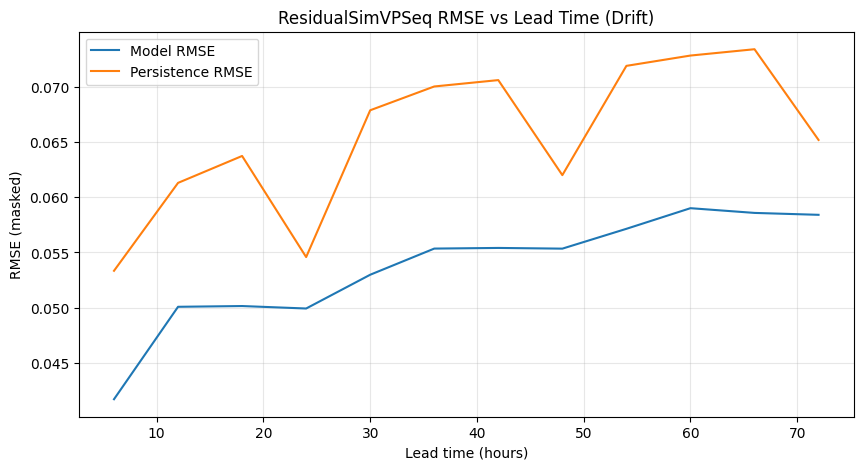

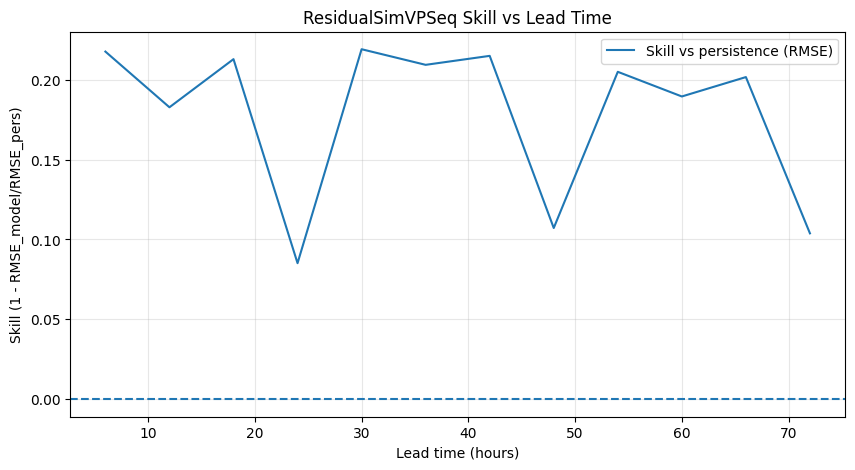


Anchored event (from 6h truth peak):
 - peak sample idx (lead=6h): 219
 - absolute target index in Y_full: 4552

=== Stress test summary (PM2.5 spatial max), every 6h lead ===
 lead_hours   ok  lag_steps  lag_hours  true_amp  pred_amp  capture_%
          6 True          1          6  0.461645  0.316301  68.516118
         12 True        -18       -108  0.461645  2.534791 549.077878
         18 True        -17       -102  0.461645  1.153764 249.924418
         24 True        -16        -96  0.461645  2.793972 605.220694
         30 True        -15        -90  0.461645  2.421913 524.626712
         36 True        -15        -90  0.461645  3.801435 823.454031
         42 True        -13        -78  0.461645  1.825063 395.338888
         48 True        -12        -72  0.461645  2.787627 603.846409
         54 True        -12        -72  0.461645  1.592750 345.016047
         60 True        -11        -66  0.461645  2.463727 533.684235
         66 True        -15        -90  0.461645  0.5

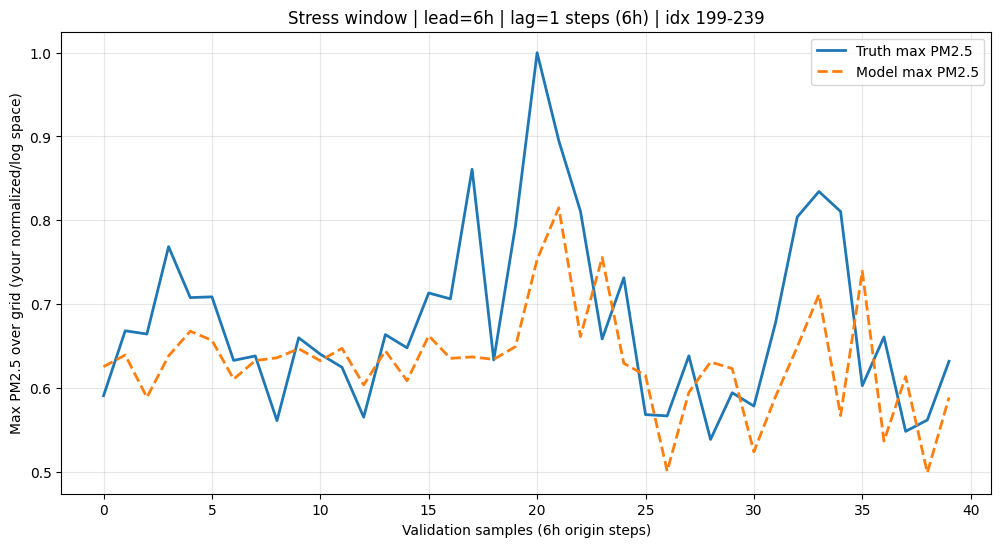

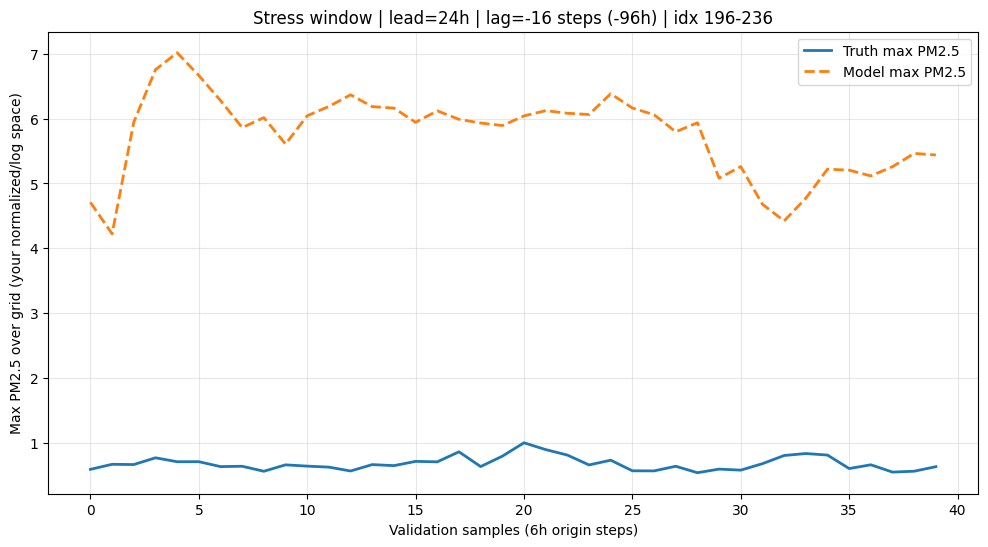

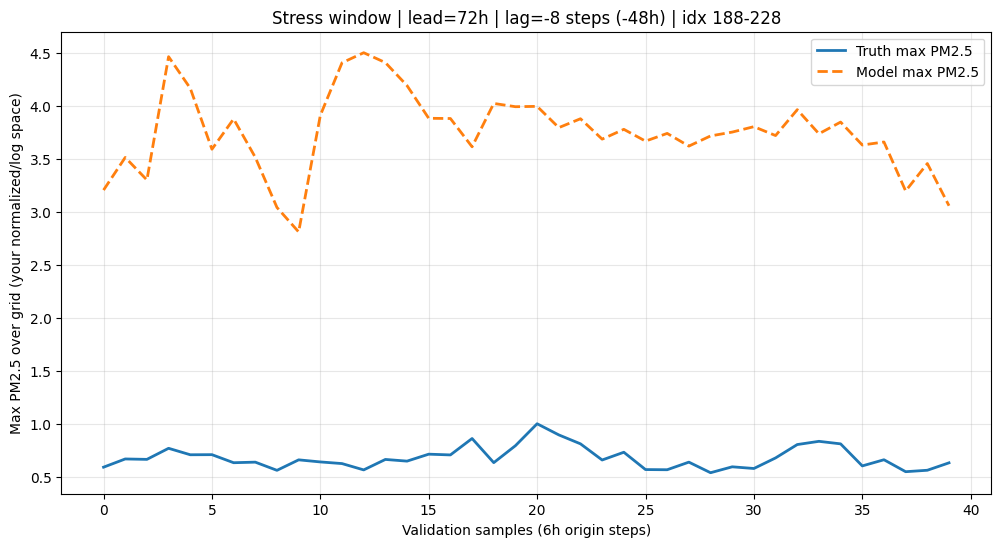


Saved stress summary CSV:
 - /content/residual_simvp_72h_stress_pm25_summary.csv


In [ ]:
# ============================================================
# EVAL-ONLY: ResidualSimVPSeq (anti-lag) 72h
# - Metrics per lead: 6..72h (MAE/MSE/RMSE/R2) + persistence baseline
# - Stress test per lead on PM2.5 (spatial max) + lag/capture summary
# ============================================================

import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive")

# --------------------------
# Paths (edit if needed)
# --------------------------
NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/best_simvp_72h.pth"

# Copy to local disk (prevents Drive disconnect issues)
NPZ_PATH  = "/content/processed_simvp_data.npz"
CKPT_PATH = "/content/best_simvp_72h.pth"

assert os.path.exists(NPZ_DRIVE),  f"❌ Missing NPZ on Drive: {NPZ_DRIVE}"
assert os.path.exists(CKPT_DRIVE), f"❌ Missing CKPT on Drive: {CKPT_DRIVE}"

print("Copying files Drive -> local...")
shutil.copy2(NPZ_DRIVE, NPZ_PATH)
shutil.copy2(CKPT_DRIVE, CKPT_PATH)
print("Local NPZ:", NPZ_PATH, "size:", os.path.getsize(NPZ_PATH))
print("Local CKPT:", CKPT_PATH, "size:", os.path.getsize(CKPT_PATH))

# --------------------------
# Config (must match training)
# --------------------------
CONFIG = {
    "History": 8,
    "Horizon": 12,
    "Batch_Size": 8,
    "Hid_S": 64,     # will auto-infer from checkpoint (safe)
    "Hid_T": 256,    # will auto-infer from checkpoint (safe)
    "Device": "cuda" if torch.cuda.is_available() else "cpu",
}
DEVICE = CONFIG["Device"]
print("Device:", DEVICE)

# Pollutant order (change if yours differs)
TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_IDX = 4  # PM2.5 index in TARGET_NAMES

# --------------------------
# Dataset (same logic as your training)
# --------------------------
class PollutionDatasetSeq(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input: flatten (T,C,H,W)->(T*C,H,W)
        x_seq = self.X[i : i + CONFIG["History"]]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        # Target sequence
        t_start = i + CONFIG["History"]
        t_end = t_start + CONFIG["Horizon"]
        if t_end > len(self.Y):
            t_end = len(self.Y)

        y_seq = self.Y[t_start:t_end]
        m_seq = self.M[t_start:t_end]

        if len(y_seq) < CONFIG["Horizon"]:
            pad_len = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad_len),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad_len),(0,0),(0,0),(0,0)), mode="constant", constant_values=0)

        last_frame_idx = i + CONFIG["History"] - 1
        y_last = self.Y[last_frame_idx]  # (6,H,W)

        return (
            torch.from_numpy(x_flat).float(),        # (T*C,H,W)
            torch.from_numpy(y_seq).float(),         # (Horizon,6,H,W)
            torch.from_numpy(m_seq).float(),         # (Horizon,6,H,W)
            torch.from_numpy(y_last).float(),        # (6,H,W)
        )

# --------------------------
# Model (same as your training)
# --------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)

    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVPSeq(nn.Module):
    def __init__(self, in_channels, out_channels_per_step):
        super().__init__()
        hid_S, hid_T = CONFIG["Hid_S"], CONFIG["Hid_T"]
        self.horizon = CONFIG["Horizon"]
        self.out_c = out_channels_per_step

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
        )

        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])

        total_out_channels = self.out_c * self.horizon
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, total_out_channels, 3, 1, 1),
        )

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        flat_delta = self.dec(mid)  # (B, 72, H, W)

        B, _, H, W = flat_delta.shape
        delta_seq = flat_delta.view(B, self.horizon, self.out_c, H, W)

        last_known = x[:, -self.out_c:, :, :].unsqueeze(1)  # (B,1,6,H,W)
        return last_known + delta_seq  # (B,Horizon,6,H,W)

# --------------------------
# Load data + build val loader (same split logic)
# --------------------------
print("Loading NPZ...")
data = np.load(NPZ_PATH)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]

num_vars = X_full.shape[1]
in_dim = num_vars * CONFIG["History"]
out_dim = Y_full.shape[1]
assert out_dim == 6, f"Expected Y_full channels=6, got {out_dim}"

total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
train_idx_end = int(total_len * 0.85)
val_indices = list(range(train_idx_end, total_len))

val_ds = PollutionDatasetSeq(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)
print("Val samples:", len(val_ds))
print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "Mask:", M_full.shape)

# --------------------------
# Load checkpoint (auto-infer Hid_S/Hid_T if needed)
# --------------------------
print("Loading checkpoint...")
state = torch.load(CKPT_PATH, map_location=DEVICE)

# infer Hid_S from enc.0.conv.weight (shape [Hid_S, in_dim, 3, 3])
if "enc.0.conv.weight" in state:
    CONFIG["Hid_S"] = int(state["enc.0.conv.weight"].shape[0])
# infer Hid_T from mid.0.conv1.conv.weight (shape [Hid_T, Hid_S, 3, 3])
if "mid.0.conv1.conv.weight" in state:
    CONFIG["Hid_T"] = int(state["mid.0.conv1.conv.weight"].shape[0])

print(f"Detected Hid_S={CONFIG['Hid_S']}  Hid_T={CONFIG['Hid_T']}")

model = ResidualSimVPSeq(in_channels=in_dim, out_channels_per_step=6).to(DEVICE)
model.load_state_dict(state, strict=True)
model.eval()
print("✅ Loaded:", CKPT_PATH)

# --------------------------
# Metrics per lead (model + persistence)
# --------------------------
@torch.no_grad()
def eval_metrics_per_lead(model, loader, device):
    H = CONFIG["Horizon"]
    C = 6
    eps = 1e-8

    sum_m  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y2 = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_model = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_model  = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_pers = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_pers  = torch.zeros(H, C, device=device, dtype=torch.float64)

    for x, y_seq, m_seq, y_last in loader:
        x      = x.to(device)
        y_seq  = y_seq.to(device)   # (B,H,C,H,W)
        m_seq  = m_seq.to(device)
        y_last = y_last.to(device)  # (B,C,H,W)

        pred = model(x)  # (B,H,C,H,W)
        pers = y_last.unsqueeze(1).expand_as(y_seq)

        # accumulate moments of y
        sum_m  += m_seq.sum(dim=(0,3,4)).double()
        sum_y  += (y_seq * m_seq).sum(dim=(0,3,4)).double()
        sum_y2 += ((y_seq**2) * m_seq).sum(dim=(0,3,4)).double()

        # model errors
        diff_m = pred - y_seq
        abs_m_model += (diff_m.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_model  += ((diff_m**2) * m_seq).sum(dim=(0,3,4)).double()

        # persistence errors
        diff_p = pers - y_seq
        abs_m_pers += (diff_p.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_pers  += ((diff_p**2) * m_seq).sum(dim=(0,3,4)).double()

    mean = sum_y / (sum_m + eps)
    sst = sum_y2 - 2*mean*sum_y + (mean**2)*sum_m
    sst = torch.clamp(sst, min=0.0)

    # per lead/channel
    mae_model = abs_m_model / (sum_m + eps)
    mse_model = sq_m_model  / (sum_m + eps)
    rmse_model = torch.sqrt(mse_model)
    r2_model = 1.0 - (sq_m_model / (sst + eps))

    mae_pers = abs_m_pers / (sum_m + eps)
    mse_pers = sq_m_pers  / (sum_m + eps)
    rmse_pers = torch.sqrt(mse_pers)
    r2_pers = 1.0 - (sq_m_pers / (sst + eps))

    skill_rmse = 1.0 - (rmse_model / (rmse_pers + eps))

    leads = [(k+1)*6 for k in range(H)]
    rows = []
    for k, lh in enumerate(leads):
        for c in range(C):
            rows.append({
                "lead_hours": lh,
                "pollutant": TARGET_NAMES[c],
                "MAE_model": float(mae_model[k,c].cpu()),
                "MSE_model": float(mse_model[k,c].cpu()),
                "RMSE_model": float(rmse_model[k,c].cpu()),
                "R2_model": float(r2_model[k,c].cpu()),
                "MAE_pers": float(mae_pers[k,c].cpu()),
                "MSE_pers": float(mse_pers[k,c].cpu()),
                "RMSE_pers": float(rmse_pers[k,c].cpu()),
                "R2_pers": float(r2_pers[k,c].cpu()),
                "Skill_RMSE": float(skill_rmse[k,c].cpu()),
                "mask_count": float(sum_m[k,c].cpu()),
            })
    df = pd.DataFrame(rows)

    # overall per lead (aggregate across pollutants/pixels)
    sum_mL = sum_m.sum(dim=1)
    abs_model_L = abs_m_model.sum(dim=1)
    sq_model_L  = sq_m_model.sum(dim=1)
    abs_pers_L  = abs_m_pers.sum(dim=1)
    sq_pers_L   = sq_m_pers.sum(dim=1)
    sst_L       = sst.sum(dim=1)

    df_overall = pd.DataFrame({
        "lead_hours": leads,
        "MAE_model": (abs_model_L/(sum_mL+eps)).cpu().numpy(),
        "MSE_model": (sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "RMSE_model": torch.sqrt(sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "R2_model": (1.0 - (sq_model_L/(sst_L+eps))).cpu().numpy(),
        "MAE_pers": (abs_pers_L/(sum_mL+eps)).cpu().numpy(),
        "MSE_pers": (sq_pers_L/(sum_mL+eps)).cpu().numpy(),
        "RMSE_pers": torch.sqrt(sq_pers_L/(sum_mL+eps)).cpu().numpy(),
        "R2_pers": (1.0 - (sq_pers_L/(sst_L+eps))).cpu().numpy(),
        "Skill_RMSE": (1.0 - (torch.sqrt(sq_model_L/(sum_mL+eps)) / (torch.sqrt(sq_pers_L/(sum_mL+eps)) + eps))).cpu().numpy()
    })

    return df, df_overall

df_pol, df_overall = eval_metrics_per_lead(model, val_loader, DEVICE)

print("\n=== Per-lead OVERALL drift (all pollutants combined) ===")
print(df_overall[["lead_hours","MAE_model","MSE_model","RMSE_model","R2_model","RMSE_pers","Skill_RMSE"]].to_string(index=False))

print("\n=== 6h-only (lead=6h) per-pollutant (compare to other 6h models) ===")
print(df_pol[df_pol["lead_hours"]==6][["pollutant","MAE_model","MSE_model","RMSE_model","R2_model","RMSE_pers","Skill_RMSE"]].to_string(index=False))

# Save tables
df_pol.to_csv("/content/residual_simvp_72h_metrics_per_pollutant.csv", index=False)
df_overall.to_csv("/content/residual_simvp_72h_metrics_overall.csv", index=False)
print("\nSaved CSVs:")
print(" - /content/residual_simvp_72h_metrics_per_pollutant.csv")
print(" - /content/residual_simvp_72h_metrics_overall.csv")

# Drift plots
plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["RMSE_model"], label="Model RMSE")
plt.plot(df_overall["lead_hours"], df_overall["RMSE_pers"], label="Persistence RMSE")
plt.xlabel("Lead time (hours)")
plt.ylabel("RMSE (masked)")
plt.title("ResidualSimVPSeq RMSE vs Lead Time (Drift)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["Skill_RMSE"], label="Skill vs persistence (RMSE)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Lead time (hours)")
plt.ylabel("Skill (1 - RMSE_model/RMSE_pers)")
plt.title("ResidualSimVPSeq Skill vs Lead Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------------
# Stress test for EVERY lead (PM2.5 spatial max), anchored to the same event time
# --------------------------
@torch.no_grad()
def collect_pm25_max_series(model, loader, device, pm25_idx=PM25_IDX):
    """
    Returns:
      true_max: (N, Horizon)
      pred_max: (N, Horizon)
    where each entry is spatial max over H,W for PM2.5.
    """
    true_list = []
    pred_list = []

    for x, y_seq, m_seq, y_last in loader:
        x = x.to(device)
        pred = model(x).detach()     # (B,H,C,H,W)
        y_seq = y_seq.to(device)

        # (B,H,H,W) -> max over (H,W) => (B,H)
        p_pred = pred[:, :, pm25_idx, :, :].amax(dim=(2,3)).cpu().numpy()
        p_true = y_seq[:, :, pm25_idx, :, :].amax(dim=(2,3)).cpu().numpy()

        pred_list.append(p_pred)
        true_list.append(p_true)

    return np.concatenate(true_list, axis=0), np.concatenate(pred_list, axis=0)

true_max, pred_max = collect_pm25_max_series(model, val_loader, DEVICE, pm25_idx=PM25_IDX)
N, H = true_max.shape
assert H == CONFIG["Horizon"]

val_start_i = val_indices[0]

# Anchor event time using 6h truth peak (lead_idx=0)
j0 = int(np.argmax(true_max[:, 0]))
t_peak_abs = val_indices[j0] + CONFIG["History"] + 0  # absolute Y index for t+6h peak
print("\nAnchored event (from 6h truth peak):")
print(" - peak sample idx (lead=6h):", j0)
print(" - absolute target index in Y_full:", t_peak_abs)

def stress_summary_all_leads(true_max, pred_max, window=20):
    """
    window=20 => ~10 days before/after (since each sample is 6h origin steps)
    Returns a DataFrame with lag/capture for each lead.
    """
    rows = []
    for k in range(CONFIG["Horizon"]):
        # find sample index that corresponds to the SAME absolute target time t_peak_abs
        # target time for sample j at lead k is: t = val_indices[j] + History + k
        # so require: val_indices[j] = t_peak_abs - History - k
        val_i_needed = t_peak_abs - CONFIG["History"] - k
        j_center = int(val_i_needed - val_start_i)

        if j_center < 0 or j_center >= N:
            rows.append({
                "lead_hours": (k+1)*6,
                "ok": False,
                "lag_steps": np.nan,
                "lag_hours": np.nan,
                "true_amp": np.nan,
                "pred_amp": np.nan,
                "capture_%": np.nan
            })
            continue

        s = max(0, j_center - window)
        e = min(N, j_center + window)

        y_true = true_max[s:e, k]
        y_pred = pred_max[s:e, k]

        t_true = int(np.argmax(y_true))
        t_pred = int(np.argmax(y_pred))
        lag_steps = t_pred - t_true
        lag_hours = lag_steps * 6

        true_amp = float(y_true.max() - y_true.min())
        pred_amp = float(y_pred.max() - y_pred.min())
        capture = float(pred_amp / (true_amp + 1e-8) * 100.0)

        rows.append({
            "lead_hours": (k+1)*6,
            "ok": True,
            "lag_steps": lag_steps,
            "lag_hours": lag_hours,
            "true_amp": true_amp,
            "pred_amp": pred_amp,
            "capture_%": capture
        })

    return pd.DataFrame(rows)

stress_df = stress_summary_all_leads(true_max, pred_max, window=20)
print("\n=== Stress test summary (PM2.5 spatial max), every 6h lead ===")
print(stress_df.to_string(index=False))

# Optional plots: plot a few leads (set to range(12) to plot all)
PLOT_LEADS = [0, 3, 11]  # 6h, 24h, 72h
# PLOT_LEADS = list(range(12))  # uncomment to plot all 12 leads

def plot_stress_lead(true_max, pred_max, lead_idx, window=20):
    val_i_needed = t_peak_abs - CONFIG["History"] - lead_idx
    j_center = int(val_i_needed - val_start_i)
    if j_center < 0 or j_center >= N:
        print(f"Lead {(lead_idx+1)*6}h: target time not in validation window.")
        return
    s = max(0, j_center - window)
    e = min(N, j_center + window)

    y_true = true_max[s:e, lead_idx]
    y_pred = pred_max[s:e, lead_idx]

    t_true = int(np.argmax(y_true))
    t_pred = int(np.argmax(y_pred))
    lag_steps = t_pred - t_true

    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Truth max PM2.5", linewidth=2)
    plt.plot(y_pred, label="Model max PM2.5", linestyle="--", linewidth=2)
    plt.title(f"Stress window | lead={(lead_idx+1)*6}h | lag={lag_steps} steps ({lag_steps*6}h) | idx {s}-{e}")
    plt.xlabel("Validation samples (6h origin steps)")
    plt.ylabel("Max PM2.5 over grid (your normalized/log space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

for k in PLOT_LEADS:
    plot_stress_lead(true_max, pred_max, lead_idx=k, window=20)

# Save stress table
stress_df.to_csv("/content/residual_simvp_72h_stress_pm25_summary.csv", index=False)
print("\nSaved stress summary CSV:")
print(" - /content/residual_simvp_72h_stress_pm25_summary.csv")


EarthTransformer Validation

Mounting Google Drive...
Mounted at /content/drive
Copying Drive -> local ...
Local NPZ: /content/processed_simvp_data.npz size: 4011023020
Local CKPT: /content/earthformer_3day.pth size: 17298211
Device: cuda
Loading NPZ...
X_full: (5108, 32, 88, 120) Y_full: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Loading CKPT state dict...

=== Inferred EarthTransformer config from checkpoint ===
in_channels_ckpt=32  out_channels=6
patch_size=(t=2, h=4, w=4)
embed_dim=256  dim_feedforward=1024  num_layers=4
t_tokens=4 => history=8  horizon=12

Val samples: 764
Total possible samples: 5089
✅ Loaded EarthTransformer checkpoint

=== 6h (lead=6) per-pollutant (compare to other 6h models) ===
pollutant  RMSE_model  RMSE_pers  Skill_RMSE    R2_model  R2_pers
       CO    0.016203   0.001167  -12.879260 -121.467187 0.364260
      NO2    0.035054   0.029684   -0.180892    0.285171 0.487397
       O3    0.021199   0.011979   -0.769700   -1.129181 0.320151
     PM10    0.077950   0.076682   -0.016527    0

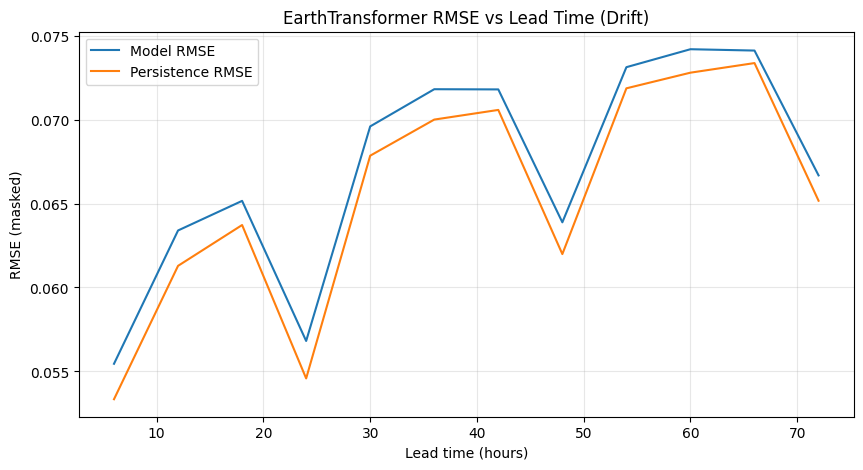

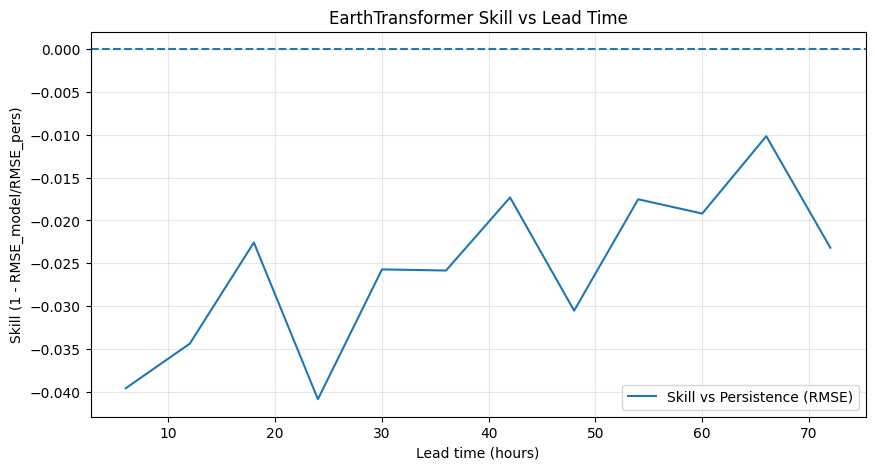


Saved CSVs:
 - /content/earthtransformer_metrics_per_pollutant.csv
 - /content/earthtransformer_metrics_overall.csv

Anchored event (from 6h truth peak):
peak sample idx: 219 | absolute target index: 4552

=== Stress test summary (PM2.5 spatial max), every 6h lead ===
 lead_hours   ok  lag_steps  lag_hours  true_amp  pred_amp  capture_%
          6 True          1          6  0.461645  0.453785  98.297338
         12 True          2         12  0.461645  0.466412 101.032584
         18 True          3         18  0.461645  0.457869  99.181973
         24 True          4         24  0.461645  0.478335 103.615320
         30 True          5         30  0.461645  0.457382  99.076448
         36 True          6         36  0.461645  0.464878 100.700310
         42 True          7         42  0.461645  0.467509 101.270243
         48 True          8         48  0.461645  0.458902  99.405791
         54 True          9         54  0.461645  0.459023  99.432053
         60 True         10   

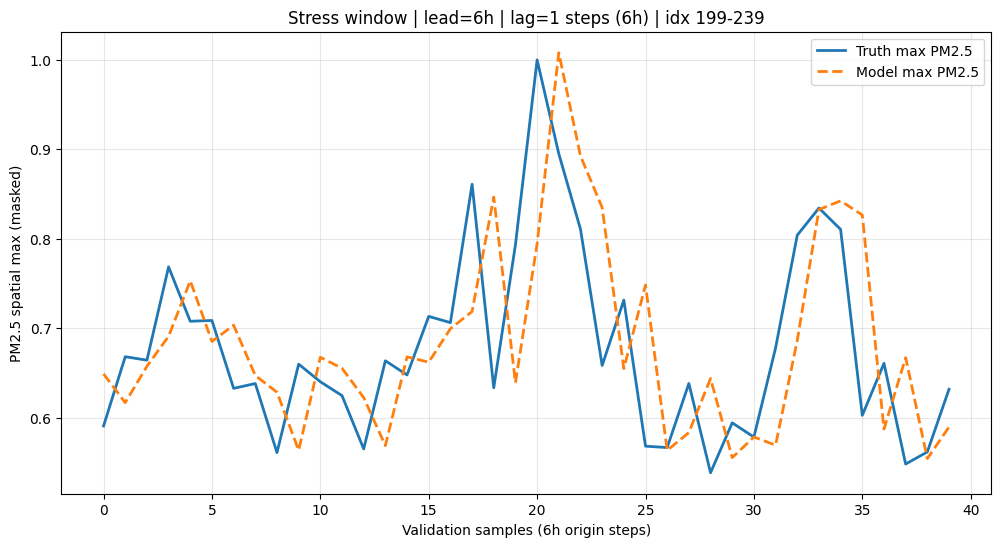

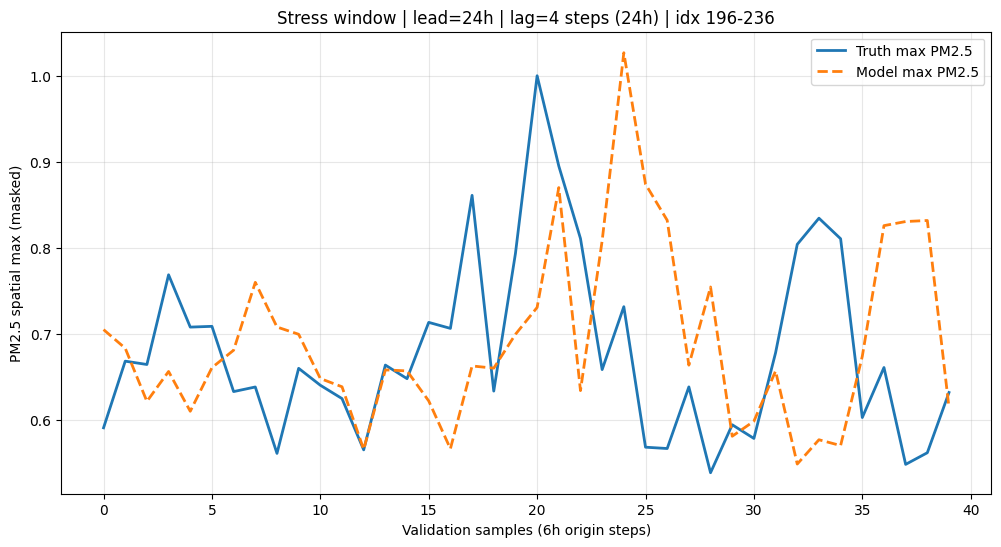

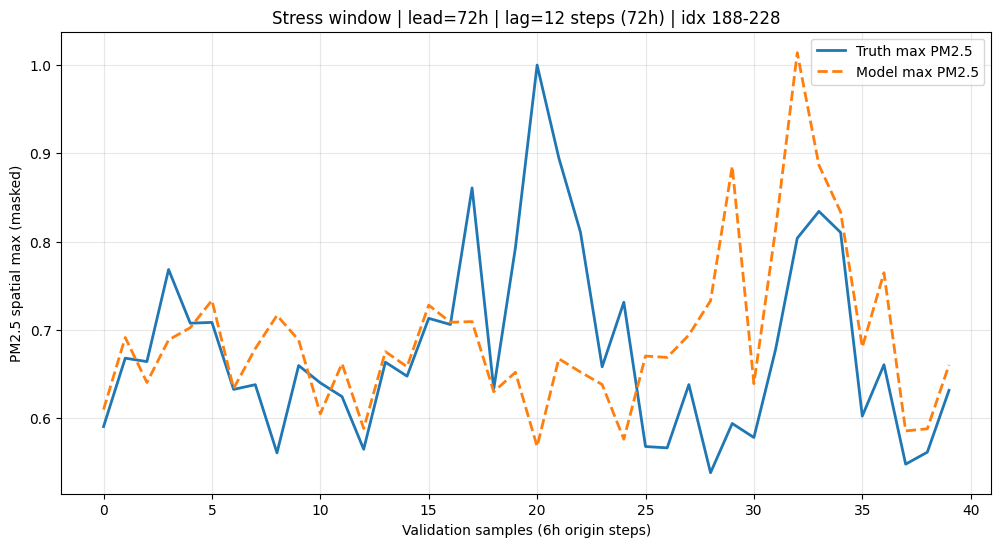

In [ ]:
# ============================================================
# EVAL-ONLY: EarthTransformer / EarthFormer-style 72h
# - Metrics per lead: 6..72h (MAE/MSE/RMSE/R2) + persistence baseline
# - Stress test per lead (PM2.5 spatial max) + lag/capture summary
# ============================================================

import os, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 0) Mount Drive + copy files local (recommended)
# ----------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive")

NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/earthformer_3day.pth"   # <<< EDIT THIS

NPZ_PATH  = "/content/processed_simvp_data.npz"
CKPT_PATH = "/content/earthformer_3day.pth"

assert os.path.exists(NPZ_DRIVE),  f"❌ Missing NPZ on Drive: {NPZ_DRIVE}"
assert os.path.exists(CKPT_DRIVE), f"❌ Missing CKPT on Drive: {CKPT_DRIVE}"

print("Copying Drive -> local ...")
shutil.copy2(NPZ_DRIVE, NPZ_PATH)
shutil.copy2(CKPT_DRIVE, CKPT_PATH)

print("Local NPZ:", NPZ_PATH, "size:", os.path.getsize(NPZ_PATH))
print("Local CKPT:", CKPT_PATH, "size:", os.path.getsize(CKPT_PATH))

# ----------------------------
# 1) Basic config (we will infer key parts from checkpoint)
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_IDX = 4

# IMPORTANT: must match training for EarthTransformer
# (nhead does NOT change parameter shapes but DOES change how weights are used)
NUM_HEADS_DEFAULT = 4

# ----------------------------
# 2) Load NPZ (to get H/W + arrays)
# ----------------------------
print("Loading NPZ...")
data = np.load(NPZ_PATH)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
T_total, C_in, H_img, W_img = X_full.shape
assert Y_full.shape[1] == 6, f"Expected 6 pollution channels, got {Y_full.shape[1]}"

print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "Mask:", M_full.shape)

# ----------------------------
# 3) Load checkpoint state dict + infer patch/history/horizon/embed_dim/etc
# ----------------------------
print("Loading CKPT state dict...")
state = torch.load(CKPT_PATH, map_location="cpu")
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]  # handle lightning-style

# infer patch_embed
assert "patch_embed.weight" in state, "❌ This checkpoint doesn't look like EarthformerDirect (missing patch_embed.weight)."
pe_w = state["patch_embed.weight"]  # (embed_dim, in_channels, kt, kh, kw)
embed_dim = int(pe_w.shape[0])
in_channels_ckpt = int(pe_w.shape[1])
patch_t, patch_h, patch_w = [int(x) for x in pe_w.shape[2:5]]

# infer out_channels from up_patch (ConvTranspose3d)
assert "up_patch.weight" in state, "❌ Missing up_patch.weight in checkpoint."
up_w = state["up_patch.weight"]  # (embed_dim, out_channels, kT, kH, kW) for ConvTranspose3d
out_channels = int(up_w.shape[1])

# infer num_tokens from pos_embed
assert "pos_embed" in state, "❌ Missing pos_embed in checkpoint."
num_tokens = int(state["pos_embed"].shape[1])

# infer time expansion factor from decoder_proj
assert "decoder_proj.weight" in state, "❌ Missing decoder_proj.weight in checkpoint."
dp_w = state["decoder_proj.weight"]  # (embed_dim * factor, embed_dim)
time_expansion_factor = int(dp_w.shape[0] // dp_w.shape[1])

# infer t_tokens from num_tokens and image/patch sizes
h_tokens = H_img // patch_h
w_tokens = W_img // patch_w
t_tokens = int(num_tokens // (h_tokens * w_tokens))

history = t_tokens * patch_t
horizon = t_tokens * time_expansion_factor

# infer num_layers + dim_feedforward
layer_ids = set()
for k in state.keys():
    m = re.match(r"transformer\.layers\.(\d+)\.", k)
    if m:
        layer_ids.add(int(m.group(1)))
num_layers = (max(layer_ids) + 1) if layer_ids else 1

# dim_feedforward from linear1 weight if present
ff = None
for k in state.keys():
    if k.endswith("linear1.weight"):
        ff = int(state[k].shape[0])
        break
dim_feedforward = ff if ff is not None else embed_dim * 4

print("\n=== Inferred EarthTransformer config from checkpoint ===")
print(f"in_channels_ckpt={in_channels_ckpt}  out_channels={out_channels}")
print(f"patch_size=(t={patch_t}, h={patch_h}, w={patch_w})")
print(f"embed_dim={embed_dim}  dim_feedforward={dim_feedforward}  num_layers={num_layers}")
print(f"t_tokens={t_tokens} => history={history}  horizon={horizon}")

# sanity checks
if in_channels_ckpt != C_in:
    print(f"⚠️ WARNING: NPZ input channels={C_in} but checkpoint expects {in_channels_ckpt}.")
    print("   This will fail unless your NPZ and training channels match.")
assert out_channels == 6, f"Expected out_channels=6, got {out_channels}"

# Choose num_heads (must match training!)
# If you trained with something else, set NUM_HEADS here.
NUM_HEADS = NUM_HEADS_DEFAULT
assert embed_dim % NUM_HEADS == 0, "embed_dim must be divisible by num_heads"

CONFIG = {
    "History": history,
    "Horizon": horizon,
    "Batch_Size": 8,
}

# ----------------------------
# 4) Dataset for EarthTransformer (B,C,T,H,W)
# ----------------------------
class PollutionDatasetEarth(Dataset):
    """
    Returns:
      x:      (C_in, T_in, H, W)  -> batch becomes (B,C_in,T_in,H,W)
      y_seq:  (T_out, 6, H, W)    -> batch (B,T_out,6,H,W)
      m_seq:  (T_out, 6, H, W)
      y_last: (6, H, W)
    """
    def __init__(self, X, Y, M, indices):
        self.X = X
        self.Y = Y
        self.M = M
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = self.X[i : i + CONFIG["History"]]            # (T_in, C_in, H, W)
        x = torch.from_numpy(x_seq).float().permute(1,0,2,3) # (C_in, T_in, H, W)

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]

        y_seq = self.Y[t0:t1]     # (T_out,6,H,W)
        m_seq = self.M[t0:t1]

        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="constant", constant_values=0)

        y_seq = torch.from_numpy(y_seq).float()
        m_seq = torch.from_numpy(m_seq).float()

        y_last = torch.from_numpy(self.Y[i + CONFIG["History"] - 1]).float()  # (6,H,W)

        return x, y_seq, m_seq, y_last

# ----------------------------
# 5) EarthformerDirect model (must match checkpoint key names)
# ----------------------------
class EarthformerDirect(nn.Module):
    def __init__(self, in_channels, out_channels, img_size):
        super().__init__()
        self.patch_size = (patch_t, patch_h, patch_w)
        self.embed_dim = embed_dim
        self.horizon = CONFIG["Horizon"]

        # patch embedding (Conv3d)
        self.patch_embed = nn.Conv3d(
            in_channels, self.embed_dim,
            kernel_size=self.patch_size,
            stride=self.patch_size
        )

        # compute tokens
        t_tokens_local = CONFIG["History"] // self.patch_size[0]
        h_tokens_local = img_size[0] // self.patch_size[1]
        w_tokens_local = img_size[1] // self.patch_size[2]
        self.num_tokens = t_tokens_local * h_tokens_local * w_tokens_local

        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, self.embed_dim))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=NUM_HEADS,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # expand time in feature space
        # horizon = t_tokens * time_expansion_factor  (inferred)
        self.time_expansion_factor = time_expansion_factor
        self.decoder_proj = nn.Linear(self.embed_dim, self.embed_dim * self.time_expansion_factor)

        # upsample space only
        self.up_patch = nn.ConvTranspose3d(
            self.embed_dim, out_channels,
            kernel_size=(1, self.patch_size[1], self.patch_size[2]),
            stride=(1, self.patch_size[1], self.patch_size[2])
        )

    def forward(self, x):
        """
        x: (B, C_in, T_in, H, W)
        returns: (B, Horizon, 6, H, W)
        """
        B, C, T, H, W = x.shape

        x_embed = self.patch_embed(x)              # (B, E, t', h', w')
        _, _, t_p, h_p, w_p = x_embed.shape

        tokens = x_embed.flatten(2).transpose(1, 2)  # (B, num_tokens, E)
        tokens = tokens + self.pos_embed
        tokens = self.transformer(tokens)            # (B, num_tokens, E)

        tokens = self.decoder_proj(tokens)           # (B, num_tokens, E*factor)

        # reshape into (B, E, Horizon, h', w')
        # IMPORTANT: use reshape/contiguous to avoid the view stride error
        tokens = tokens.transpose(1, 2).contiguous()                        # (B, E*factor, num_tokens)
        tokens = tokens.reshape(B, self.embed_dim, self.horizon, h_p, w_p)  # (B, E, Horizon, h', w')

        delta_pred = self.up_patch(tokens)  # (B, 6, Horizon, H, W)

        # Residual anchor: assume pollution channels are last 6 channels in X
        last_pollution = x[:, -6:, -1:, :, :]       # (B, 6, 1, H, W)
        pred = last_pollution + delta_pred          # broadcast over Horizon
        return pred.permute(0, 2, 1, 3, 4)          # (B, Horizon, 6, H, W)

# ----------------------------
# 6) Build val_loader (same split logic)
# ----------------------------
total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
train_idx_end = int(total_len * 0.85)
val_indices = list(range(train_idx_end, total_len))

val_ds = PollutionDatasetEarth(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

print("\nVal samples:", len(val_ds))
print("Total possible samples:", total_len)

# ----------------------------
# 7) Load model weights
# ----------------------------
model = EarthformerDirect(in_channels=C_in, out_channels=6, img_size=(H_img, W_img)).to(DEVICE)
try:
    model.load_state_dict(state, strict=True)
except Exception as e:
    print("\n❌ Failed to load state_dict. This usually means your EarthTransformer training code differs.")
    print("   If so: paste your exact model class, keep the evaluator functions below unchanged.")
    raise e

model.eval()
print("✅ Loaded EarthTransformer checkpoint")

# ----------------------------
# 8) Metrics per lead (model + persistence)
# ----------------------------
@torch.no_grad()
def eval_metrics_per_lead(model, loader, device):
    H = CONFIG["Horizon"]
    C = 6
    eps = 1e-8

    sum_m  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y2 = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_model = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_model  = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_pers = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_pers  = torch.zeros(H, C, device=device, dtype=torch.float64)

    for x, y_seq, m_seq, y_last in loader:
        x      = x.to(device)      # (B,C,T,H,W)
        y_seq  = y_seq.to(device)  # (B,H,C,H,W)
        m_seq  = m_seq.to(device)
        y_last = y_last.to(device) # (B,C,H,W)

        pred = model(x)  # (B,H,C,H,W)
        pers = y_last.unsqueeze(1).expand_as(y_seq)

        sum_m  += m_seq.sum(dim=(0,3,4)).double()
        sum_y  += (y_seq * m_seq).sum(dim=(0,3,4)).double()
        sum_y2 += ((y_seq**2) * m_seq).sum(dim=(0,3,4)).double()

        diff_m = pred - y_seq
        abs_m_model += (diff_m.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_model  += ((diff_m**2) * m_seq).sum(dim=(0,3,4)).double()

        diff_p = pers - y_seq
        abs_m_pers += (diff_p.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_pers  += ((diff_p**2) * m_seq).sum(dim=(0,3,4)).double()

    mean = sum_y / (sum_m + eps)
    sst = sum_y2 - 2*mean*sum_y + (mean**2)*sum_m
    sst = torch.clamp(sst, min=0.0)

    mae_model = abs_m_model / (sum_m + eps)
    mse_model = sq_m_model  / (sum_m + eps)
    rmse_model = torch.sqrt(mse_model)
    r2_model = 1.0 - (sq_m_model / (sst + eps))

    mae_pers = abs_m_pers / (sum_m + eps)
    mse_pers = sq_m_pers  / (sum_m + eps)
    rmse_pers = torch.sqrt(mse_pers)
    r2_pers = 1.0 - (sq_m_pers / (sst + eps))

    skill_rmse = 1.0 - (rmse_model / (rmse_pers + eps))

    leads = [(k+1)*6 for k in range(H)]
    rows = []
    for k, lh in enumerate(leads):
        for c in range(C):
            rows.append({
                "lead_hours": lh,
                "pollutant": TARGET_NAMES[c],
                "MAE_model": float(mae_model[k,c].cpu()),
                "MSE_model": float(mse_model[k,c].cpu()),
                "RMSE_model": float(rmse_model[k,c].cpu()),
                "R2_model": float(r2_model[k,c].cpu()),
                "MAE_pers": float(mae_pers[k,c].cpu()),
                "MSE_pers": float(mse_pers[k,c].cpu()),
                "RMSE_pers": float(rmse_pers[k,c].cpu()),
                "R2_pers": float(r2_pers[k,c].cpu()),
                "Skill_RMSE": float(skill_rmse[k,c].cpu()),
                "mask_count": float(sum_m[k,c].cpu()),
            })
    df = pd.DataFrame(rows)

    # overall per lead (aggregate across pollutants/pixels)
    sum_mL = sum_m.sum(dim=1)
    abs_model_L = abs_m_model.sum(dim=1)
    sq_model_L  = sq_m_model.sum(dim=1)
    abs_pers_L  = abs_m_pers.sum(dim=1)
    sq_pers_L   = sq_m_pers.sum(dim=1)
    sst_L       = sst.sum(dim=1)

    df_overall = pd.DataFrame({
        "lead_hours": leads,
        "MAE_model": (abs_model_L/(sum_mL+eps)).cpu().numpy(),
        "MSE_model": (sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "RMSE_model": torch.sqrt(sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "R2_model": (1.0 - (sq_model_L/(sst_L+eps))).cpu().numpy(),
        "RMSE_pers": torch.sqrt(sq_pers_L/(sum_mL+eps)).cpu().numpy(),
        "Skill_RMSE": (1.0 - (torch.sqrt(sq_model_L/(sum_mL+eps)) / (torch.sqrt(sq_pers_L/(sum_mL+eps)) + eps))).cpu().numpy()
    })

    return df, df_overall

df_pol, df_overall = eval_metrics_per_lead(model, val_loader, DEVICE)

print("\n=== 6h (lead=6) per-pollutant (compare to other 6h models) ===")
print(df_pol[df_pol["lead_hours"]==6][["pollutant","RMSE_model","RMSE_pers","Skill_RMSE","R2_model","R2_pers"]].to_string(index=False))

print("\n=== Overall drift (all pollutants combined) ===")
print(df_overall[["lead_hours","RMSE_model","RMSE_pers","Skill_RMSE","R2_model"]].to_string(index=False))

# Drift plots
plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["RMSE_model"], label="Model RMSE")
plt.plot(df_overall["lead_hours"], df_overall["RMSE_pers"], label="Persistence RMSE")
plt.xlabel("Lead time (hours)")
plt.ylabel("RMSE (masked)")
plt.title("EarthTransformer RMSE vs Lead Time (Drift)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["Skill_RMSE"], label="Skill vs Persistence (RMSE)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Lead time (hours)")
plt.ylabel("Skill (1 - RMSE_model/RMSE_pers)")
plt.title("EarthTransformer Skill vs Lead Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Save tables
df_pol.to_csv("/content/earthtransformer_metrics_per_pollutant.csv", index=False)
df_overall.to_csv("/content/earthtransformer_metrics_overall.csv", index=False)
print("\nSaved CSVs:")
print(" - /content/earthtransformer_metrics_per_pollutant.csv")
print(" - /content/earthtransformer_metrics_overall.csv")

# ----------------------------
# 9) Stress test per lead (PM2.5 spatial max), aligned across leads
# ----------------------------
@torch.no_grad()
def collect_pm25_max_series(model, loader, device, pm25_idx=PM25_IDX):
    true_list, pred_list = [], []
    for x, y_seq, m_seq, y_last in loader:
        x = x.to(device)
        y_seq = y_seq.to(device)     # (B,H,C,H,W)
        m_seq = m_seq.to(device)

        pred = model(x)              # (B,H,C,H,W)

        # mask PM2.5 for fair max
        mask_pm = m_seq[:, :, pm25_idx, :, :]          # (B,H,H,W)
        p_pred = pred[:, :, pm25_idx, :, :].masked_fill(mask_pm < 0.5, -1e9).amax(dim=(2,3)).cpu().numpy()
        p_true = y_seq[:, :, pm25_idx, :, :].masked_fill(mask_pm < 0.5, -1e9).amax(dim=(2,3)).cpu().numpy()

        pred_list.append(p_pred)
        true_list.append(p_true)

    return np.concatenate(true_list, axis=0), np.concatenate(pred_list, axis=0)

true_max, pred_max = collect_pm25_max_series(model, val_loader, DEVICE, pm25_idx=PM25_IDX)
N, Hh = true_max.shape
assert Hh == CONFIG["Horizon"]

val_start_i = val_indices[0]

# Anchor event using lead=6h truth peak (lead_idx=0)
j0 = int(np.argmax(true_max[:, 0]))
t_peak_abs = val_indices[j0] + CONFIG["History"] + 0  # absolute target time index
print("\nAnchored event (from 6h truth peak):")
print("peak sample idx:", j0, "| absolute target index:", t_peak_abs)

def stress_summary_all_leads(true_max, pred_max, window=20):
    rows = []
    for k in range(CONFIG["Horizon"]):
        # Align to same absolute target time for every lead:
        # target time for sample j at lead k is val_indices[j] + History + k
        # so require val_indices[j] = t_peak_abs - History - k
        val_i_needed = t_peak_abs - CONFIG["History"] - k
        j_center = int(val_i_needed - val_start_i)

        lead_hours = (k+1)*6
        if j_center < 0 or j_center >= len(true_max):
            rows.append({"lead_hours": lead_hours, "ok": False, "lag_steps": np.nan, "lag_hours": np.nan,
                         "true_amp": np.nan, "pred_amp": np.nan, "capture_%": np.nan})
            continue

        s = max(0, j_center - window)
        e = min(len(true_max), j_center + window)

        y_true = true_max[s:e, k]
        y_pred = pred_max[s:e, k]

        t_true = int(np.argmax(y_true))
        t_pred = int(np.argmax(y_pred))
        lag_steps = t_pred - t_true

        true_amp = float(y_true.max() - y_true.min())
        pred_amp = float(y_pred.max() - y_pred.min())
        capture = float(pred_amp / (true_amp + 1e-8) * 100.0)

        rows.append({
            "lead_hours": lead_hours,
            "ok": True,
            "lag_steps": lag_steps,
            "lag_hours": lag_steps * 6,
            "true_amp": true_amp,
            "pred_amp": pred_amp,
            "capture_%": capture
        })
    return pd.DataFrame(rows)

stress_df = stress_summary_all_leads(true_max, pred_max, window=20)
print("\n=== Stress test summary (PM2.5 spatial max), every 6h lead ===")
print(stress_df.to_string(index=False))

stress_df.to_csv("/content/earthtransformer_stress_pm25_summary.csv", index=False)
print("\nSaved stress summary CSV:")
print(" - /content/earthtransformer_stress_pm25_summary.csv")

# Optional plots (choose leads to visualize)
PLOT_LEADS = [0, 3, 11]  # 6h, 24h, 72h
# PLOT_LEADS = list(range(CONFIG["Horizon"]))  # uncomment to plot all leads

def plot_stress_lead(true_max, pred_max, lead_idx, window=20):
    lead_hours = (lead_idx+1)*6
    val_i_needed = t_peak_abs - CONFIG["History"] - lead_idx
    j_center = int(val_i_needed - val_start_i)
    if j_center < 0 or j_center >= len(true_max):
        print(f"Lead {lead_hours}h not alignable in validation window.")
        return
    s = max(0, j_center - window)
    e = min(len(true_max), j_center + window)

    y_true = true_max[s:e, lead_idx]
    y_pred = pred_max[s:e, lead_idx]

    t_true = int(np.argmax(y_true))
    t_pred = int(np.argmax(y_pred))
    lag_steps = t_pred - t_true

    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Truth max PM2.5", linewidth=2)
    plt.plot(y_pred, label="Model max PM2.5", linestyle="--", linewidth=2)
    plt.title(f"Stress window | lead={lead_hours}h | lag={lag_steps} steps ({lag_steps*6}h) | idx {s}-{e}")
    plt.xlabel("Validation samples (6h origin steps)")
    plt.ylabel("PM2.5 spatial max (masked)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

for k in PLOT_LEADS:
    plot_stress_lead(true_max, pred_max, k, window=20)


validation on SimpV1+v2 hybrid medel

Mounting Google Drive...
Mounted at /content/drive
Copying Drive -> local ...
Local NPZ: /content/processed_simvp_data.npz size: 4011023020
Local CKPT: /content/best_simvp_hybrid_72h_v10.pth size: 92259379
Device: cuda
Loading NPZ...
X_full: (5108, 32, 88, 120) Y_full: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Loading CKPT...

=== Inferred SimVPHybrid config from checkpoint ===
in_channels_ckpt=32  (NPZ C_in=32)
History(T_in)=8  Horizon(T_out)=12
Hid_S=64  Hid_T=256

Total possible samples: 5089
VAL samples: 764
✅ Loaded SimVPHybrid weights

=== 6h (lead=6) per-pollutant (compare to your other 6h models) ===
pollutant  RMSE_model  RMSE_pers  Skill_RMSE  R2_model
       CO    0.000853   0.001167    0.269726  0.660954
      NO2    0.027017   0.029684    0.089850  0.575373
       O3    0.008776   0.011979    0.267392  0.635114
     PM10    0.049259   0.076682    0.357627  0.758271
    PM2.5    0.058922   0.074050    0.204297  0.664022
      SO2    0.053655   0.064912    0.173414  0.5714

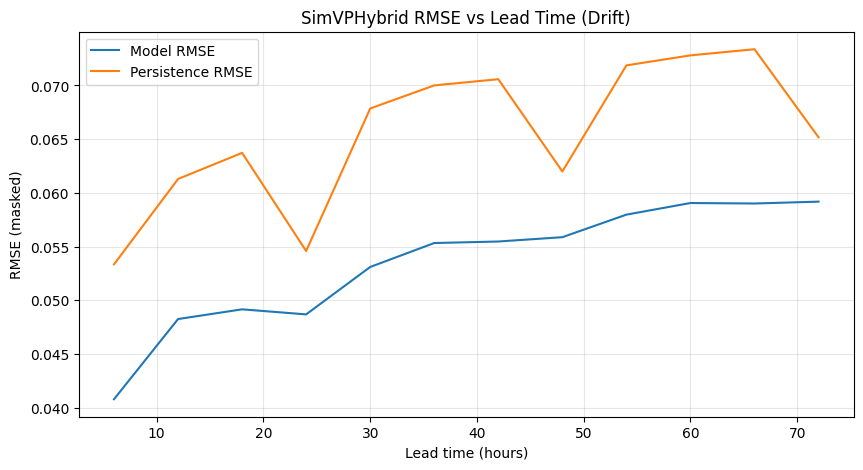

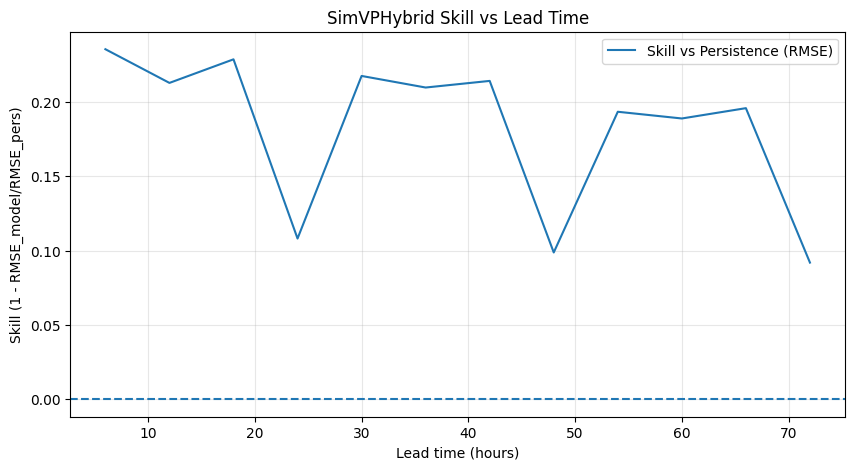


Saved CSVs:
 - /content/simvp_hybrid_72h_metrics_per_pollutant.csv
 - /content/simvp_hybrid_72h_metrics_overall.csv

Anchored event (from 6h truth peak):
peak sample idx: 219 | absolute target index: 4552

=== Stress test summary (PM2.5 spatial max), every 6h lead ===
 lead_hours   ok  lag_steps  lag_hours  true_amp  pred_amp  capture_%
          6 True          1          6  0.461645  0.336837  72.964449
         12 True          4         24  0.461645  0.180929  39.192283
         18 True          0          0  0.461645  0.189147  40.972449
         24 True         12         72  0.461645  0.196938  42.660015
         30 True         12         72  0.461645  0.203851  44.157423
         36 True         13         78  0.461645  0.209265  45.330355
         42 True          5         30  0.461645  0.175604  38.038769
         48 True          7         42  0.461645  0.186146  40.322401
         54 True         11         66  0.461645  0.206296  44.687188
         60 True          9   

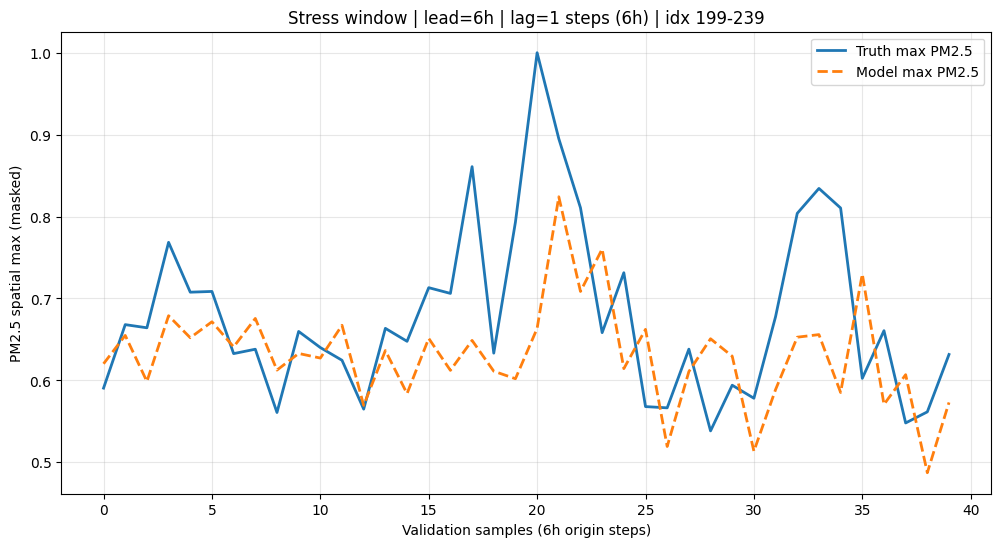

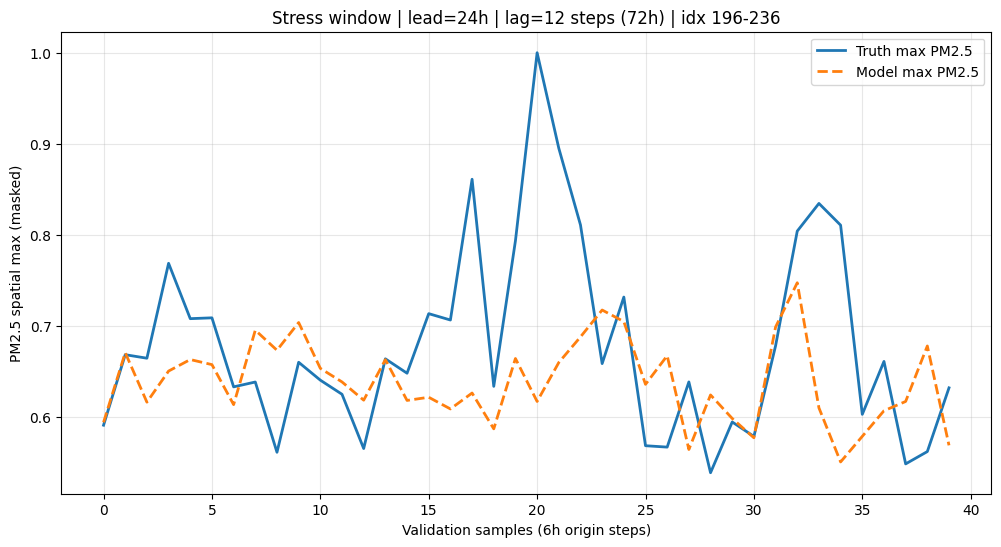

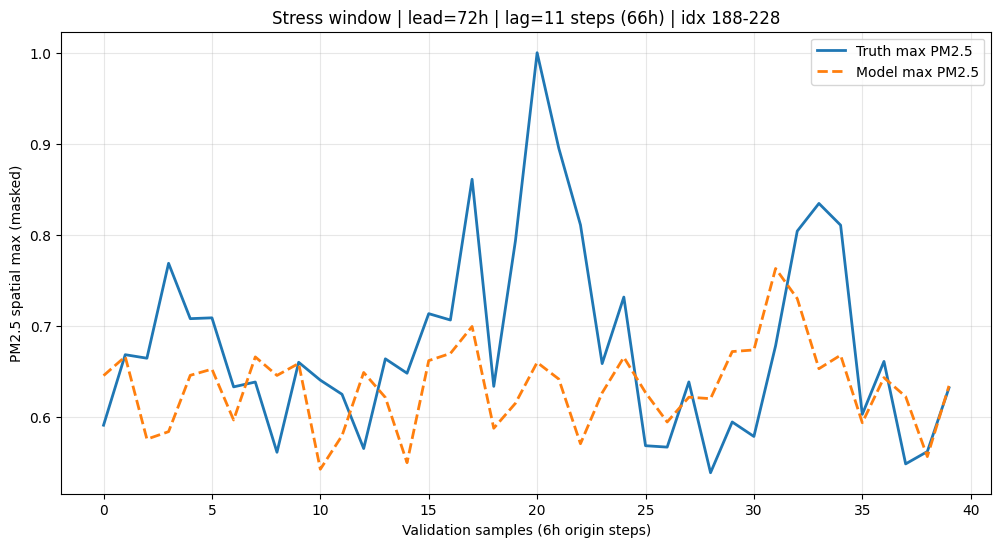

In [ ]:
# ============================================================
# EVAL-ONLY: SimVPHybrid 72h
# - Loads NPZ + best_simvp_hybrid_72h_v10.pth
# - Computes per-lead (6..72h): MAE / MSE / RMSE / R^2
# - Computes persistence baseline: yhat(t+h)=y(t)
# - Computes Skill vs persistence
# - Stress test per lead (PM2.5 spatial max): lag + capture%
# - Saves CSVs + plots drift curves
# ============================================================

import os, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive")

# --------------------------
# Paths (EDIT if needed)
# --------------------------
NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth"  # <--- your hybrid ckpt

# Copy to local disk to avoid Drive disconnect / transport errors
NPZ_PATH  = "/content/processed_simvp_data.npz"
CKPT_PATH = "/content/best_simvp_hybrid_72h_v10.pth"

assert os.path.exists(NPZ_DRIVE),  f"❌ Missing NPZ on Drive: {NPZ_DRIVE}"
assert os.path.exists(CKPT_DRIVE), f"❌ Missing CKPT on Drive: {CKPT_DRIVE}"

print("Copying Drive -> local ...")
shutil.copy2(NPZ_DRIVE, NPZ_PATH)
shutil.copy2(CKPT_DRIVE, CKPT_PATH)
print("Local NPZ:", NPZ_PATH, "size:", os.path.getsize(NPZ_PATH))
print("Local CKPT:", CKPT_PATH, "size:", os.path.getsize(CKPT_PATH))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Pollutant order (adjust if needed)
TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_IDX = 4

# --------------------------
# Load NPZ
# --------------------------
print("Loading NPZ...")
data = np.load(NPZ_PATH)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
T_total, C_in, H_img, W_img = X_full.shape
assert Y_full.shape[1] == 6, f"Expected Y channels=6, got {Y_full.shape[1]}"
print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "Mask:", M_full.shape)

# --------------------------
# Load checkpoint state dict + infer CONFIG from shapes
# (so you don't accidentally mismatch History/Horizon/Hid_S/Hid_T)
# --------------------------
print("Loading CKPT...")
state = torch.load(CKPT_PATH, map_location="cpu")
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]  # lightning style

# Infer Hid_S from encoder first conv: enc.0.conv.weight = [hid_S, in_channels, 3, 3]
assert "enc.0.conv.weight" in state, "❌ Not a SimVPHybrid checkpoint (missing enc.0.conv.weight)."
hid_S = int(state["enc.0.conv.weight"].shape[0])
in_ch_ckpt = int(state["enc.0.conv.weight"].shape[1])

# Infer Hid_T from mid reducer conv: mid.0.conv.weight = [hid_T, T_in*hid_S, 1, 1]
assert "mid.0.conv.weight" in state, "❌ Not a SimVPHybrid checkpoint (missing mid.0.conv.weight)."
hid_T = int(state["mid.0.conv.weight"].shape[0])
mid_in = int(state["mid.0.conv.weight"].shape[1])
T_in = int(mid_in // hid_S)

# Infer Horizon from time_projector: time_projector.weight = [T_out*hid_S, hid_T, 1, 1]
assert "time_projector.weight" in state, "❌ Not a SimVPHybrid checkpoint (missing time_projector.weight)."
tproj_out = int(state["time_projector.weight"].shape[0])
T_out = int(tproj_out // hid_S)

print("\n=== Inferred SimVPHybrid config from checkpoint ===")
print(f"in_channels_ckpt={in_ch_ckpt}  (NPZ C_in={C_in})")
print(f"History(T_in)={T_in}  Horizon(T_out)={T_out}")
print(f"Hid_S={hid_S}  Hid_T={hid_T}")

if in_ch_ckpt != C_in:
    print("⚠️ WARNING: NPZ channels != checkpoint channels. This will fail unless they match exactly.")

# Global CONFIG used by the model code (match training)
CONFIG = {
    "History": T_in,
    "Horizon": T_out,
    "Batch_Size": 8,   # safe eval batch size; change if you want
    "Hid_S": hid_S,
    "Hid_T": hid_T,
    "Device": DEVICE,
    "Lag_Penalty": 10.0,
}

# --------------------------
# Dataset (same as your training: x_seq is (T,C,H,W))
# --------------------------
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float()  # (T_in,C_in,H,W)

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        if t1 > len(self.Y): t1 = len(self.Y)

        y_seq = self.Y[t0:t1]
        m_seq = self.M[t0:t1]

        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")

        y_last = torch.from_numpy(self.Y[i + CONFIG["History"] - 1]).float()  # (6,H,W)

        return x_seq, torch.from_numpy(y_seq).float(), torch.from_numpy(m_seq).float(), y_last

# --------------------------
# Model blocks (same as your training)
# --------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)  # must divide out_c
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]
        hid_T = CONFIG["Hid_T"]
        T_in  = CONFIG["History"]
        T_out = CONFIG["Horizon"]

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
        )

        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        # x_seq: (B,T_in,C,H,W)
        B, T_in, C, H, W = x_seq.shape
        hid_S = CONFIG["Hid_S"]
        T_out = CONFIG["Horizon"]

        x_flat = x_seq.reshape(B*T_in, C, H, W)
        embed = self.enc(x_flat)  # (B*T_in,hid_S,H',W')
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in*hid_S, Hp, Wp)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)  # (B,T_out*hid_S,Hp,Wp)

        future_flat = future_features.view(B*T_out, hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)               # (B*T_out,6,H,W)
        delta_seq = delta_flat.view(B, T_out, 6, H, W)

        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)  # assumes pollution are last 6 channels
        return last_frame + delta_seq  # (B,T_out,6,H,W)

# --------------------------
# Build val loader (same split logic as training: 85/15)
# --------------------------
total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
train_idx_end = int(total_len * 0.85)
val_indices = list(range(train_idx_end, total_len))

val_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

print("\nTotal possible samples:", total_len)
print("VAL samples:", len(val_ds))

# --------------------------
# Load model weights
# --------------------------
model = SimVPHybrid(in_channels=C_in, out_channels=6).to(DEVICE)
model.load_state_dict(state, strict=True)
model.eval()
print("✅ Loaded SimVPHybrid weights")

# ============================================================
# Metrics per lead: MAE / MSE / RMSE / R2 + persistence + skill
# ============================================================
@torch.no_grad()
def eval_metrics_per_lead(model, loader, device):
    H = CONFIG["Horizon"]
    C = 6
    eps = 1e-8

    sum_m  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y  = torch.zeros(H, C, device=device, dtype=torch.float64)
    sum_y2 = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_model = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_model  = torch.zeros(H, C, device=device, dtype=torch.float64)

    abs_m_pers = torch.zeros(H, C, device=device, dtype=torch.float64)
    sq_m_pers  = torch.zeros(H, C, device=device, dtype=torch.float64)

    for x_seq, y_seq, m_seq, y_last in loader:
        x_seq  = x_seq.to(device)   # (B,T,C,H,W)
        y_seq  = y_seq.to(device)   # (B,H,C,H,W)
        m_seq  = m_seq.to(device)
        y_last = y_last.to(device)  # (B,C,H,W)

        pred = model(x_seq)  # (B,H,C,H,W)
        pers = y_last.unsqueeze(1).expand_as(y_seq)

        sum_m  += m_seq.sum(dim=(0,3,4)).double()
        sum_y  += (y_seq * m_seq).sum(dim=(0,3,4)).double()
        sum_y2 += ((y_seq**2) * m_seq).sum(dim=(0,3,4)).double()

        diff_m = pred - y_seq
        abs_m_model += (diff_m.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_model  += ((diff_m**2) * m_seq).sum(dim=(0,3,4)).double()

        diff_p = pers - y_seq
        abs_m_pers += (diff_p.abs() * m_seq).sum(dim=(0,3,4)).double()
        sq_m_pers  += ((diff_p**2) * m_seq).sum(dim=(0,3,4)).double()

    mean = sum_y / (sum_m + eps)
    sst = sum_y2 - 2*mean*sum_y + (mean**2)*sum_m
    sst = torch.clamp(sst, min=0.0)

    mae_model = abs_m_model / (sum_m + eps)
    mse_model = sq_m_model  / (sum_m + eps)
    rmse_model = torch.sqrt(mse_model)
    r2_model = 1.0 - (sq_m_model / (sst + eps))

    mae_pers = abs_m_pers / (sum_m + eps)
    mse_pers = sq_m_pers  / (sum_m + eps)
    rmse_pers = torch.sqrt(mse_pers)
    r2_pers = 1.0 - (sq_m_pers / (sst + eps))

    skill_rmse = 1.0 - (rmse_model / (rmse_pers + eps))

    leads = [(k+1)*6 for k in range(H)]
    rows = []
    for k, lh in enumerate(leads):
        for c in range(C):
            rows.append({
                "lead_hours": lh,
                "pollutant": TARGET_NAMES[c],
                "MAE_model": float(mae_model[k,c].cpu()),
                "MSE_model": float(mse_model[k,c].cpu()),
                "RMSE_model": float(rmse_model[k,c].cpu()),
                "R2_model": float(r2_model[k,c].cpu()),
                "MAE_pers": float(mae_pers[k,c].cpu()),
                "MSE_pers": float(mse_pers[k,c].cpu()),
                "RMSE_pers": float(rmse_pers[k,c].cpu()),
                "R2_pers": float(r2_pers[k,c].cpu()),
                "Skill_RMSE": float(skill_rmse[k,c].cpu()),
                "mask_count": float(sum_m[k,c].cpu()),
            })
    df = pd.DataFrame(rows)

    # overall per lead (aggregate)
    sum_mL = sum_m.sum(dim=1)
    abs_model_L = abs_m_model.sum(dim=1)
    sq_model_L  = sq_m_model.sum(dim=1)
    abs_pers_L  = abs_m_pers.sum(dim=1)
    sq_pers_L   = sq_m_pers.sum(dim=1)
    sst_L       = sst.sum(dim=1)

    df_overall = pd.DataFrame({
        "lead_hours": leads,
        "MAE_model": (abs_model_L/(sum_mL+eps)).cpu().numpy(),
        "MSE_model": (sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "RMSE_model": torch.sqrt(sq_model_L/(sum_mL+eps)).cpu().numpy(),
        "R2_model": (1.0 - (sq_model_L/(sst_L+eps))).cpu().numpy(),
        "RMSE_pers": torch.sqrt(sq_pers_L/(sum_mL+eps)).cpu().numpy(),
        "Skill_RMSE": (1.0 - (torch.sqrt(sq_model_L/(sum_mL+eps)) / (torch.sqrt(sq_pers_L/(sum_mL+eps)) + eps))).cpu().numpy()
    })

    return df, df_overall

df_pol, df_overall = eval_metrics_per_lead(model, val_loader, DEVICE)

print("\n=== 6h (lead=6) per-pollutant (compare to your other 6h models) ===")
print(df_pol[df_pol["lead_hours"]==6][["pollutant","RMSE_model","RMSE_pers","Skill_RMSE","R2_model"]].to_string(index=False))

print("\n=== Overall drift (all pollutants combined) ===")
print(df_overall[["lead_hours","RMSE_model","RMSE_pers","Skill_RMSE","R2_model"]].to_string(index=False))

# Drift plots
plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["RMSE_model"], label="Model RMSE")
plt.plot(df_overall["lead_hours"], df_overall["RMSE_pers"], label="Persistence RMSE")
plt.xlabel("Lead time (hours)")
plt.ylabel("RMSE (masked)")
plt.title("SimVPHybrid RMSE vs Lead Time (Drift)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_overall["lead_hours"], df_overall["Skill_RMSE"], label="Skill vs Persistence (RMSE)")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Lead time (hours)")
plt.ylabel("Skill (1 - RMSE_model/RMSE_pers)")
plt.title("SimVPHybrid Skill vs Lead Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Save tables
df_pol.to_csv("/content/simvp_hybrid_72h_metrics_per_pollutant.csv", index=False)
df_overall.to_csv("/content/simvp_hybrid_72h_metrics_overall.csv", index=False)
print("\nSaved CSVs:")
print(" - /content/simvp_hybrid_72h_metrics_per_pollutant.csv")
print(" - /content/simvp_hybrid_72h_metrics_overall.csv")

# ============================================================
# Stress test per lead (PM2.5 spatial max), aligned across leads
# ============================================================
@torch.no_grad()
def collect_pm25_max_series(model, loader, device, pm25_idx=PM25_IDX):
    true_list, pred_list = [], []
    for x_seq, y_seq, m_seq, y_last in loader:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        m_seq = m_seq.to(device)

        pred = model(x_seq)  # (B,H,C,H,W)

        # mask PM2.5 for fair max
        mask_pm = m_seq[:, :, pm25_idx, :, :]  # (B,H,H,W)
        p_pred = pred[:, :, pm25_idx, :, :].masked_fill(mask_pm < 0.5, -1e9).amax(dim=(2,3)).cpu().numpy()
        p_true = y_seq[:, :, pm25_idx, :, :].masked_fill(mask_pm < 0.5, -1e9).amax(dim=(2,3)).cpu().numpy()

        pred_list.append(p_pred)
        true_list.append(p_true)

    return np.concatenate(true_list, axis=0), np.concatenate(pred_list, axis=0)

true_max, pred_max = collect_pm25_max_series(model, val_loader, DEVICE, pm25_idx=PM25_IDX)
N, Hh = true_max.shape

val_start_i = val_indices[0]

# Anchor event using lead=6h truth peak (lead_idx=0)
j0 = int(np.argmax(true_max[:, 0]))
t_peak_abs = val_indices[j0] + CONFIG["History"] + 0  # absolute target index for the 6h lead peak

print("\nAnchored event (from 6h truth peak):")
print("peak sample idx:", j0, "| absolute target index:", t_peak_abs)

def stress_summary_all_leads(true_max, pred_max, window=20):
    rows = []
    for k in range(CONFIG["Horizon"]):
        lead_hours = (k+1)*6

        # Align to same absolute target time for every lead:
        # target time for sample j at lead k is val_indices[j] + History + k
        # so val_indices[j] must equal t_peak_abs - History - k
        val_i_needed = t_peak_abs - CONFIG["History"] - k
        j_center = int(val_i_needed - val_start_i)

        if j_center < 0 or j_center >= len(true_max):
            rows.append({"lead_hours": lead_hours, "ok": False,
                         "lag_steps": np.nan, "lag_hours": np.nan,
                         "true_amp": np.nan, "pred_amp": np.nan, "capture_%": np.nan})
            continue

        s = max(0, j_center - window)
        e = min(len(true_max), j_center + window)

        y_true = true_max[s:e, k]
        y_pred = pred_max[s:e, k]

        t_true = int(np.argmax(y_true))
        t_pred = int(np.argmax(y_pred))
        lag_steps = t_pred - t_true

        true_amp = float(y_true.max() - y_true.min())
        pred_amp = float(y_pred.max() - y_pred.min())
        capture = float(pred_amp / (true_amp + 1e-8) * 100.0)

        rows.append({
            "lead_hours": lead_hours,
            "ok": True,
            "lag_steps": lag_steps,
            "lag_hours": lag_steps * 6,
            "true_amp": true_amp,
            "pred_amp": pred_amp,
            "capture_%": capture
        })
    return pd.DataFrame(rows)

stress_df = stress_summary_all_leads(true_max, pred_max, window=20)
print("\n=== Stress test summary (PM2.5 spatial max), every 6h lead ===")
print(stress_df.to_string(index=False))

stress_df.to_csv("/content/simvp_hybrid_72h_stress_pm25_summary.csv", index=False)
print("\nSaved stress summary CSV:")
print(" - /content/simvp_hybrid_72h_stress_pm25_summary.csv")

# Optional plots: choose which leads to visualize
PLOT_LEADS = [0, 3, 11]  # 6h, 24h, 72h
# PLOT_LEADS = list(range(CONFIG["Horizon"]))  # uncomment to plot all leads

def plot_stress_lead(true_max, pred_max, lead_idx, window=20):
    lead_hours = (lead_idx+1)*6
    val_i_needed = t_peak_abs - CONFIG["History"] - lead_idx
    j_center = int(val_i_needed - val_start_i)
    if j_center < 0 or j_center >= len(true_max):
        print(f"Lead {lead_hours}h not alignable in validation window.")
        return

    s = max(0, j_center - window)
    e = min(len(true_max), j_center + window)

    y_true = true_max[s:e, lead_idx]
    y_pred = pred_max[s:e, lead_idx]

    t_true = int(np.argmax(y_true))
    t_pred = int(np.argmax(y_pred))
    lag_steps = t_pred - t_true

    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Truth max PM2.5", linewidth=2)
    plt.plot(y_pred, label="Model max PM2.5", linestyle="--", linewidth=2)
    plt.title(f"Stress window | lead={lead_hours}h | lag={lag_steps} steps ({lag_steps*6}h) | idx {s}-{e}")
    plt.xlabel("Validation samples (6h origin steps)")
    plt.ylabel("PM2.5 spatial max (masked)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

for k in PLOT_LEADS:
    plot_stress_lead(true_max, pred_max, k, window=20)


validation on hybrid new version version 11

In [ ]:
# ============================================================
# MULTI-MODEL EVALUATOR for Hybrid SimVP checkpoints
# - Compare multiple checkpoints on the SAME validation period
# - Metrics per lead: MAE / MSE / R^2 + Persistence + Skill vs Pers
# - Stressed test: PM2.5 spatial MAX spike (overlay models)
# ============================================================

import os, shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# 0) Mount Drive + copy NPZ local
# -----------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

NPZ_CANDIDATES = [
    "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz",
    "/content/drive/MyDrive/isef/s.npz",
]
NPZ_LOCAL = "/content/local_data.npz"

def copy_first_existing(src_list, dst):
    for src in src_list:
        if os.path.exists(src):
            print(f">>> Copying NPZ: {src} -> {dst}")
            shutil.copy2(src, dst)
            return src
    raise FileNotFoundError(f"None of these NPZ paths exist:\n{src_list}")

if not os.path.exists(NPZ_LOCAL):
    npz_src = copy_first_existing(NPZ_CANDIDATES, NPZ_LOCAL)
else:
    print("✅ NPZ already exists locally:", NPZ_LOCAL)

assert os.path.exists(NPZ_LOCAL), f"❌ NPZ missing: {NPZ_LOCAL}"
data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
T_total = len(X_full)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "M_full:", M_full.shape)

# 6-hour time index for date-based validation window
time_index = pd.date_range("2022-01-01 00:00:00", periods=T_total, freq="6h", tz="UTC")

# -----------------------------
# 1) Choose a common validation date range (recommended)
# -----------------------------
VAL_START = pd.Timestamp("2024-12-21 00:00:00", tz="UTC")
VAL_END   = pd.Timestamp("2025-06-30 18:00:00", tz="UTC")

# pollution channel order in Y (you confirmed this)
POLLUTANTS = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_IDX = 4

# -----------------------------
# 2) Model list you want to compare (EDIT THIS)
# -----------------------------
MODELS = [
    # Example entries — replace paths with yours.
    # preproc flags MUST match how each model was trained!
    {
       "name": "hybrid_v7_decoupled",
       "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
       "tp_div": 100.0, "tcrw_div": 200.0, "co_mul_x": 50.0, "co_mul_y": 50.0

    },
    #{
    #    "name": "hybrid_v5_scaled",
    #    "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #    "tp_div": 100.0,     # same as your newer training code
    #    "tcrw_div": 200.0,
    #    "co_mul_x": 50.0,    # X channel 26 multiplied
    #    "co_mul_y": 50.0,    # Y channel 0 multiplied
    #},
    # Add more:
    {
       "name": "hybrid_v4_unscaled",
       "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
       "tp_div": 100.0, "tcrw_div": 200.0, "co_mul_x": 50.0, "co_mul_y": 50.0

    },
    #{
    #   "name": "hybrid_v6_scaled",
    #   "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
    #   "tp_div": 100.0, "tcrw_div": 200.0, "co_mul_x": 50.0, "co_mul_y": 50.0

    #},


    # {
    #   "name": "hybrid_old_noscale",
    #   "ckpt_drive": "...pth",
    #   "tp_div": None, "tcrw_div": None, "co_mul_x": None, "co_mul_y": None
    # },
]

# -----------------------------
# 3) Dataset (matches your newer hybrid training preproc)
# -----------------------------
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices, cfg, History, Horizon):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)
        self.cfg = cfg
        self.History = History
        self.Horizon = Horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = torch.from_numpy(self.X[i : i + self.History]).float().clone()  # (T,C,H,W)

        # Optional scaling (must match training!)
        if self.cfg.get("tp_div") is not None and x_seq.shape[1] > 5:
            x_seq[:, 5, :, :] /= float(self.cfg["tp_div"])
        if self.cfg.get("tcrw_div") is not None and x_seq.shape[1] > 6:
            x_seq[:, 6, :, :] /= float(self.cfg["tcrw_div"])
        if self.cfg.get("co_mul_x") is not None and x_seq.shape[1] > 26:
            x_seq[:, 26, :, :] *= float(self.cfg["co_mul_x"])

        t0 = i + self.History
        t1 = t0 + self.Horizon
        if t1 > len(self.Y):
            t1 = len(self.Y)

        y_seq = torch.from_numpy(self.Y[t0:t1]).float().clone()   # (T_out,6,H,W)
        m_seq = torch.from_numpy(self.M[t0:t1]).float()

        # Target CO scaling (channel 0 in Y)
        if self.cfg.get("co_mul_y") is not None:
            y_seq[:, 0, :, :] *= float(self.cfg["co_mul_y"])

        # pad (rare if indices bounded)
        if len(y_seq) < self.Horizon:
            pad = self.Horizon - len(y_seq)
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode="replicate")
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode="replicate")

        # baseline last frame pollution from *x_seq* (already scaled)
        y_last = x_seq[-1, -6:, :, :]  # (6,H,W)

        return x_seq, y_seq, m_seq, y_last

# -----------------------------
# 4) Hybrid SimVP model definition (must match training)
# -----------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, Hid_S, Hid_T, History, Horizon):
        super().__init__()
        self.Hid_S = Hid_S
        self.History = History
        self.Horizon = Horizon

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, Hid_S, 3, 1, 1),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1)
        )

        mid_in_channels = History * Hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, Hid_T, 1, 1, 0),
            Inception(Hid_T, Hid_T),
            Inception(Hid_T, Hid_T),
            Inception(Hid_T, Hid_T),
            Inception(Hid_T, Hid_T),
        )

        self.time_projector = nn.Conv2d(Hid_T, Horizon * Hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(Hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, C, H, W)
        B, T_in, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T_in, C, H, W)
        embed  = self.enc(x_flat)  # (B*T_in, Hid_S, H', W')
        _, _, Hs, Ws = embed.shape

        embed_grouped = embed.view(B, T_in * self.Hid_S, Hs, Ws)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)  # (B, Horizon*Hid_S, Hs, Ws)

        future_flat = future_features.view(B * self.Horizon, self.Hid_S, Hs, Ws)
        delta_flat  = self.dec(future_flat)              # (B*Horizon, 6, H, W)
        delta_seq   = delta_flat.view(B, self.Horizon, 6, H, W)

        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)  # (B,1,6,H,W)
        return last_frame + delta_seq                       # (B,Horizon,6,H,W)

# -----------------------------
# 5) Helper: infer config from checkpoint
# -----------------------------
def infer_from_state_dict(state):
    Hid_S = int(state["enc.0.conv.weight"].shape[0])
    in_channels = int(state["enc.0.conv.weight"].shape[1])

    Hid_T = int(state["mid.0.conv.weight"].shape[0])
    mid_in = int(state["mid.0.conv.weight"].shape[1])
    History = int(mid_in // Hid_S)

    tp_out = int(state["time_projector.weight"].shape[0])
    Horizon = int(tp_out // Hid_S)

    out_channels = int(state["dec.2.weight"].shape[0])  # should be 6
    return in_channels, out_channels, Hid_S, Hid_T, History, Horizon

# -----------------------------
# 6) Helper: build val indices for SAME date window
# -----------------------------
def build_val_indices_by_date(History, Horizon):
    # sample i predicts targets at times [i+History, ..., i+History+Horizon-1]
    # require those to lie within [VAL_START, VAL_END]
    # convert times to indices
    def idx_of(ts):
        # exact match expected on 6h grid
        loc = np.where(time_index.values == np.datetime64(ts.to_datetime64()))[0]
        if len(loc) == 0:
            raise ValueError(f"Timestamp {ts} not found in 6h time_index.")
        return int(loc[0])

    start_idx = idx_of(VAL_START)
    end_idx   = idx_of(VAL_END)

    i_min = start_idx - History
    i_max = end_idx - History - (Horizon - 1)

    total_len = T_total - History - Horizon + 1
    i_min = max(0, i_min)
    i_max = min(total_len - 1, i_max)

    if i_max < i_min:
        return []

    return list(range(i_min, i_max + 1))

# -----------------------------
# 7) Metrics evaluator (model + persistence)
# -----------------------------
@torch.no_grad()
def evaluate_model_and_persistence(model, loader, Horizon, out_channels=6):
    eps = 1e-8
    T_out = Horizon
    C = out_channels

    # pass 1: masked mean of y per (t,c)
    sum_m = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)
    sum_y = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)

    for x_seq, y_seq, m_seq, y_last in loader:
        y = y_seq.to(DEVICE).to(torch.float64)
        m = m_seq.to(DEVICE).to(torch.float64)
        sum_m += m.sum(dim=(0,3,4))
        sum_y += (y*m).sum(dim=(0,3,4))
    y_mean = sum_y / (sum_m + eps)  # (T,C)

    # pass 2: errors
    mae_num_model = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)
    mse_num_model = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)
    sse_model     = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)

    mae_num_pers  = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)
    mse_num_pers  = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)
    sse_pers      = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)

    sst           = torch.zeros((T_out, C), device=DEVICE, dtype=torch.float64)

    for x_seq, y_seq, m_seq, y_last in loader:
        x = x_seq.to(DEVICE)
        y = y_seq.to(DEVICE)
        m = m_seq.to(DEVICE)
        y_last = y_last.to(DEVICE)

        pred = model(x)
        pred = torch.nan_to_num(pred, nan=0.0, posinf=100.0, neginf=-100.0)

        pers = y_last.unsqueeze(1).expand_as(y)

        y64 = y.to(torch.float64); m64 = m.to(torch.float64)
        pred64 = pred.to(torch.float64); pers64 = pers.to(torch.float64)

        diff_m = pred64 - y64
        diff_p = pers64 - y64

        mae_num_model += (diff_m.abs()*m64).sum(dim=(0,3,4))
        mse_num_model += ((diff_m**2)*m64).sum(dim=(0,3,4))
        sse_model     += ((diff_m**2)*m64).sum(dim=(0,3,4))

        mae_num_pers  += (diff_p.abs()*m64).sum(dim=(0,3,4))
        mse_num_pers  += ((diff_p**2)*m64).sum(dim=(0,3,4))
        sse_pers      += ((diff_p**2)*m64).sum(dim=(0,3,4))

        sst += (((y64 - y_mean[None, :, :, None, None])**2) * m64).sum(dim=(0,3,4))

    mae_model = mae_num_model / (sum_m + eps)
    mse_model = mse_num_model / (sum_m + eps)
    r2_model  = 1.0 - (sse_model / (sst + eps))

    mae_pers  = mae_num_pers / (sum_m + eps)
    mse_pers  = mse_num_pers / (sum_m + eps)
    r2_pers   = 1.0 - (sse_pers / (sst + eps))

    skill_mse = 1.0 - (mse_model / (mse_pers + eps))

    return {
        "mae_model": mae_model.detach().cpu().numpy(),
        "mse_model": mse_model.detach().cpu().numpy(),
        "r2_model":  r2_model.detach().cpu().numpy(),
        "mae_pers":  mae_pers.detach().cpu().numpy(),
        "mse_pers":  mse_pers.detach().cpu().numpy(),
        "r2_pers":   r2_pers.detach().cpu().numpy(),
        "skill_mse": skill_mse.detach().cpu().numpy(),
    }

# -----------------------------
# 8) Stressed test (overlay): PM2.5 spatial MAX at a fixed event time
# -----------------------------
def find_event_time_idx_pm25(val_start=VAL_START, val_end=VAL_END):
    # Find the time index in [val_start, val_end] where PM2.5 spatial max is highest
    start_idx = np.where(time_index.values == np.datetime64(val_start.to_datetime64()))[0][0]
    end_idx   = np.where(time_index.values == np.datetime64(val_end.to_datetime64()))[0][0]
    pm = Y_full[start_idx:end_idx+1, PM25_IDX]  # (T,H,W)
    pm_max = np.nanmax(pm.reshape(pm.shape[0], -1), axis=1)
    rel = int(np.argmax(pm_max))
    return int(start_idx + rel)

EVENT_T_IDX = find_event_time_idx_pm25()
print("\n🔥 Event center time (max PM2.5 spatial MAX in val window):", time_index[EVENT_T_IDX])

@torch.no_grad()
def stressed_series_for_model(model, cfg, History, Horizon, lead_step, window=20):
    """
    Returns a DF indexed by timestamp with columns:
    true_max, pers_max, pred_max
    for target time = center +/- window steps.
    lead_step: 0=>+6h, 1=>+12h, ...
    """
    # For target time t, we need sample index i = t - (lead_step+1) - History
    # last input time = t - (lead_step+1)
    rows = []
    for t in range(EVENT_T_IDX - window, EVENT_T_IDX + window + 1):
        i = t - (lead_step + 1) - History
        last_input_t = t - (lead_step + 1)
        if i < 0:
            continue
        if i + History > T_total:
            continue

        # Build x_seq and apply SAME scaling as dataset
        x_seq = torch.from_numpy(X_full[i:i+History]).float().clone()  # (T,C,H,W)
        if cfg.get("tp_div") is not None and x_seq.shape[1] > 5:
            x_seq[:, 5, :, :] /= float(cfg["tp_div"])
        if cfg.get("tcrw_div") is not None and x_seq.shape[1] > 6:
            x_seq[:, 6, :, :] /= float(cfg["tcrw_div"])
        if cfg.get("co_mul_x") is not None and x_seq.shape[1] > 26:
            x_seq[:, 26, :, :] *= float(cfg["co_mul_x"])

        x_seq = x_seq.unsqueeze(0).to(DEVICE)  # (1,T,C,H,W)

        pred_seq = model(x_seq)  # (1,Horizon,6,H,W)
        pred_pm  = pred_seq[0, lead_step, PM25_IDX].detach().cpu().numpy()
        pred_max = float(np.nanmax(pred_pm))

        true_pm  = Y_full[t, PM25_IDX]
        true_max = float(np.nanmax(true_pm))

        pers_pm  = Y_full[last_input_t, PM25_IDX] if last_input_t >= 0 else np.nan
        pers_max = float(np.nanmax(pers_pm)) if np.isfinite(pers_pm).any() else np.nan

        rows.append({
            "time": time_index[t],
            "true_max": true_max,
            "pers_max": pers_max,
            "pred_max": pred_max,
        })
    return pd.DataFrame(rows).set_index("time")

# -----------------------------
# 9) Main loop: evaluate all models
# -----------------------------
all_rows = []
per_model_metrics = {}

for spec in MODELS:
    name = spec["name"]
    ckpt_drive = spec["ckpt_drive"]
    print(f"\n==============================")
    print(f"=== Evaluating {name} ===")
    print(f"CKPT: {ckpt_drive}")

    if not os.path.exists(ckpt_drive):
        print("⚠️ Missing checkpoint, skipping.")
        continue

    ckpt_local = f"/content/{name}.pth"
    shutil.copy2(ckpt_drive, ckpt_local)

    state = torch.load(ckpt_local, map_location="cpu")

    try:
        in_c, out_c, Hid_S, Hid_T, History, Horizon = infer_from_state_dict(state)
    except Exception as e:
        print("❌ Could not infer config from checkpoint keys. Error:", e)
        print("   This likely means this checkpoint is NOT the hybrid architecture.")
        continue

    # Build SAME validation indices by date window for this model (depends on History/Horizon)
    val_indices = build_val_indices_by_date(History, Horizon)
    if len(val_indices) == 0:
        print("⚠️ No valid val samples for this model in the requested date window.")
        continue

    val_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, val_indices, spec, History, Horizon)
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

    print(f"History={History}, Horizon={Horizon}, Hid_S={Hid_S}, Hid_T={Hid_T}, val_samples={len(val_ds)}")
    print("Val target range:",
          time_index[val_indices[0] + History],
          "→",
          time_index[val_indices[-1] + History + (Horizon-1)]
    )

    model = SimVPHybrid(in_channels=in_c, out_channels=out_c, Hid_S=Hid_S, Hid_T=Hid_T, History=History, Horizon=Horizon).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_local, map_location=DEVICE), strict=True)
    model.eval()

    metrics = evaluate_model_and_persistence(model, val_loader, Horizon=Horizon, out_channels=out_c)
    per_model_metrics[name] = {"cfg": spec, "History": History, "Horizon": Horizon, "metrics": metrics, "val_indices": val_indices, "model": model}

    lead_hours = np.arange(1, Horizon+1) * 6
    for li, hr in enumerate(lead_hours):
        for c in range(out_c):
            all_rows.append({
                "model": name,
                "lead_hr": int(hr),
                "pollutant": POLLUTANTS[c] if c < len(POLLUTANTS) else f"Y{c}",
                "MAE_model": float(metrics["mae_model"][li, c]),
                "MSE_model": float(metrics["mse_model"][li, c]),
                "R2_model":  float(metrics["r2_model"][li, c]),
                "MAE_pers":  float(metrics["mae_pers"][li, c]),
                "MSE_pers":  float(metrics["mse_pers"][li, c]),
                "R2_pers":   float(metrics["r2_pers"][li, c]),
                "Skill_MSE": float(metrics["skill_mse"][li, c]),
            })

# Combine results
results = pd.DataFrame(all_rows)
if results.empty:
    raise RuntimeError("No models were evaluated. Check your MODELS paths and architecture match.")

print("\n✅ Combined results rows:", len(results))
display(results.head())

# -----------------------------
# 10) Ranking tables
# -----------------------------
# Rank models per pollutant per lead time by Skill_MSE (higher is better)
ranked = (
    results.sort_values(["pollutant", "lead_hr", "Skill_MSE"], ascending=[True, True, False])
           .groupby(["pollutant", "lead_hr"], as_index=False)
           .apply(lambda g: g.assign(rank=np.arange(1, len(g)+1)))
           .reset_index(drop=True)
)

print("\n=== Top-3 models per pollutant at +6h ===")
display(ranked[(ranked["lead_hr"]==6) & (ranked["rank"]<=3)][
    ["pollutant","lead_hr","rank","model","Skill_MSE","MSE_model","MSE_pers","R2_model"]
])

print("\n=== Top-3 models per pollutant at +72h (if available) ===")
display(ranked[(ranked["lead_hr"]==72) & (ranked["rank"]<=3)][
    ["pollutant","lead_hr","rank","model","Skill_MSE","MSE_model","MSE_pers","R2_model"]
])

# Quick compare table: PM2.5 across leads for all models
pm25_table = results[results["pollutant"]=="PM2.5"].pivot_table(
    index="lead_hr", columns="model", values="Skill_MSE"
).sort_index()

print("\n=== PM2.5 Skill vs Persistence across lead times ===")
display(pm25_table)

plt.figure(figsize=(10,4))
for m in pm25_table.columns:
    plt.plot(pm25_table.index, pm25_table[m], label=m)
plt.title("PM2.5 Skill (1 - MSE_model/MSE_pers) vs Lead Time")
plt.xlabel("Lead time (hours)")
plt.ylabel("Skill vs Persistence (higher is better)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 11) Stressed overlay plot (PM2.5 spatial MAX)
# -----------------------------
def stressed_overlay(models_dict, lead_hours_list=(6,)):
    for lead_hr in lead_hours_list:
        lead_step = lead_hr//6 - 1
        plt.figure(figsize=(12,5))
        base_plotted = False

        for name, pack in models_dict.items():
            History = pack["History"]
            Horizon = pack["Horizon"]
            if lead_step < 0 or lead_step >= Horizon:
                continue

            model = pack["model"]
            cfg = pack["cfg"]

            df = stressed_series_for_model(model, cfg, History, Horizon, lead_step=lead_step, window=20)

            if not base_plotted:
                plt.plot(df.index, df["true_max"], color="black", linewidth=2, label="True MAX(PM2.5)")
                plt.plot(df.index, df["pers_max"], color="gray", linestyle=":", linewidth=2, label="Persistence MAX(PM2.5)")
                base_plotted = True

            plt.plot(df.index, df["pred_max"], linestyle="--", linewidth=2, label=f"{name}")

        plt.title(f"Stressed Scenario Overlay (PM2.5 spatial MAX) | Lead +{lead_hr}h")
        plt.xlabel("UTC time")
        plt.ylabel("Scaled/normalized PM2.5")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=30)
        plt.show()
def stressed_overlay_all_horizons(models_dict,
                                 max_lead_hours=None,
                                 window=20,
                                 save_dir=None,
                                 show_persistence=True):
    """
    For each lead time (6h, 12h, ..., max_lead_hours),
    plot stressed PM2.5 spatial MAX time series:
      - True (black)
      - Persistence (gray, optional)
      - Each model (dashed)

    models_dict: your per_model_metrics dict from the evaluator:
        models_dict[name] = {"cfg":..., "History":..., "Horizon":..., "model":...}
    max_lead_hours:
        - None: uses max horizon across models (e.g., 72h if any model has Horizon=12)
        - else: integer (e.g., 72)
    window:
        number of 6-hour steps on each side of event center
    save_dir:
        if not None, saves PNGs there (e.g., "/content/drive/MyDrive/isef/stress_plots")
    """

    assert len(models_dict) > 0, "models_dict is empty. Did you run the evaluation loop?"

    # Determine maximum horizon across models (in 6h steps)
    max_h_steps = max(pack["Horizon"] for pack in models_dict.values())
    if max_lead_hours is None:
        max_lead_hours = 6 * max_h_steps
    max_lead_steps = max_lead_hours // 6

    # Create save dir if requested
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        print("Saving plots to:", save_dir)

    # For each lead time
    for lead_step in range(max_lead_steps):
        lead_hr = (lead_step + 1) * 6

        plt.figure(figsize=(13, 5))
        base_plotted = False
        plotted_any_model = False

        # Plot each model that supports this lead_step
        for name, pack in models_dict.items():
            History = pack["History"]
            Horizon = pack["Horizon"]
            model   = pack["model"]
            cfg     = pack["cfg"]

            if lead_step >= Horizon:
                # model doesn't produce this far
                continue

            # Build stressed window series for this model and lead
            df = stressed_series_for_model(
                model=model,
                cfg=cfg,
                History=History,
                Horizon=Horizon,
                lead_step=lead_step,
                window=window
            )

            if len(df) == 0:
                continue

            # Plot true + persistence ONCE per lead figure
            if not base_plotted:
                plt.plot(df.index, df["true_max"], linewidth=2, label="True MAX(PM2.5)")
                if show_persistence:
                    plt.plot(df.index, df["pers_max"], linestyle=":", linewidth=2, label="Persistence MAX(PM2.5)")
                base_plotted = True

            plt.plot(df.index, df["pred_max"], linestyle="--", linewidth=2, label=name)
            plotted_any_model = True

        if not plotted_any_model:
            plt.close()
            print(f"⚠️ No models could plot lead +{lead_hr}h (no model supports this horizon). Skipping.")
            continue

        # Title includes event time used
        plt.title(f"Stressed Scenario Overlay (PM2.5 spatial MAX) | Lead +{lead_hr}h\nEvent centered at: {time_index[EVENT_T_IDX]}")
        plt.xlabel("UTC time")
        plt.ylabel("Scaled / normalized PM2.5 (as in your Y)")
        plt.grid(True, alpha=0.3)

        # Put legend outside to avoid covering lines if you have many models
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        plt.xticks(rotation=25)
        plt.tight_layout()

        if save_dir is not None:
            out_path = os.path.join(save_dir, f"stressed_overlay_PM25_lead_{lead_hr:03d}h.png")
            plt.savefig(out_path, dpi=150)
            print("Saved:", out_path)

        plt.show()


# ----------------------------
# RUN IT:
# - This will produce 12 figures if max horizon is 72h.
# - Each figure overlays ALL models that support that lead.
# ----------------------------
stressed_overlay_all_horizons(
    models_dict=per_model_metrics,
    max_lead_hours=72,                 # set None to auto-use max across models
    window=20,                         # 20 steps = 5 days on each side (since 6h steps)
    save_dir="/content/drive/MyDrive/isef/stress_plots",  # or None
    show_persistence=True
)

print("\n>>> Running stressed overlay for +6h (and optionally +24h/+72h)...")
stressed_overlay(per_model_metrics, lead_hours_list=(6, 24, 72))
stressed_overlay_all_horizons(per_model_metrics)



Output hidden; open in https://colab.research.google.com to view.

Mounting Google Drive...
Mounted at /content/drive
🔥 Event Center: 2025-02-12 00:00:00+00:00
✅ Loaded hybrid_v6_scaled
✅ Loaded hybrid_v5_scaled
✅ Loaded hybrid_v4_unscaled

>>> Generating Corrected Stress Test Plots...


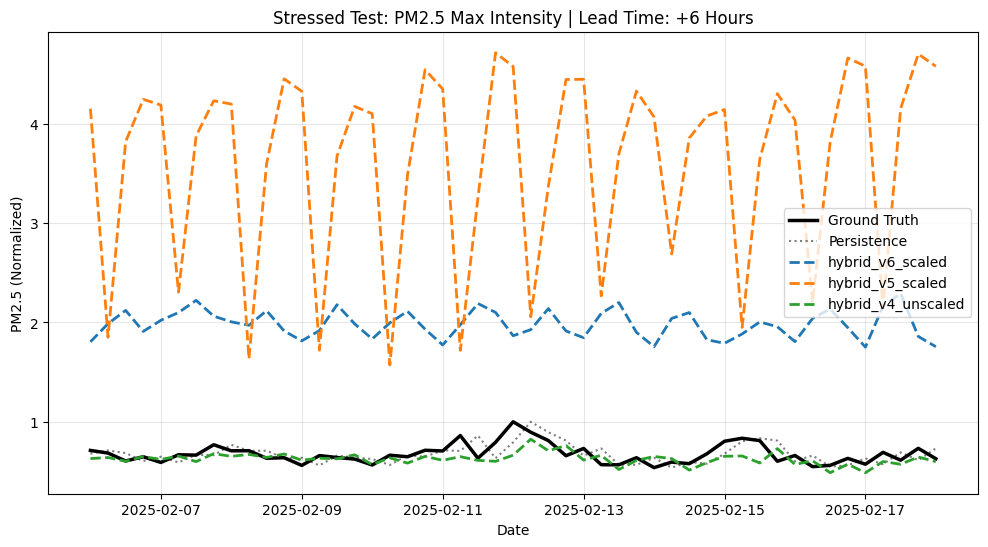

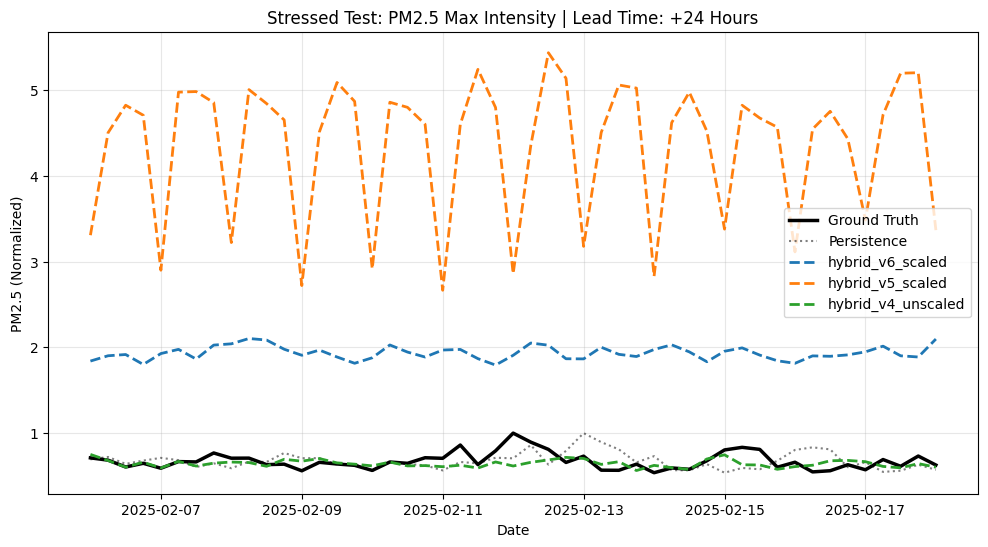

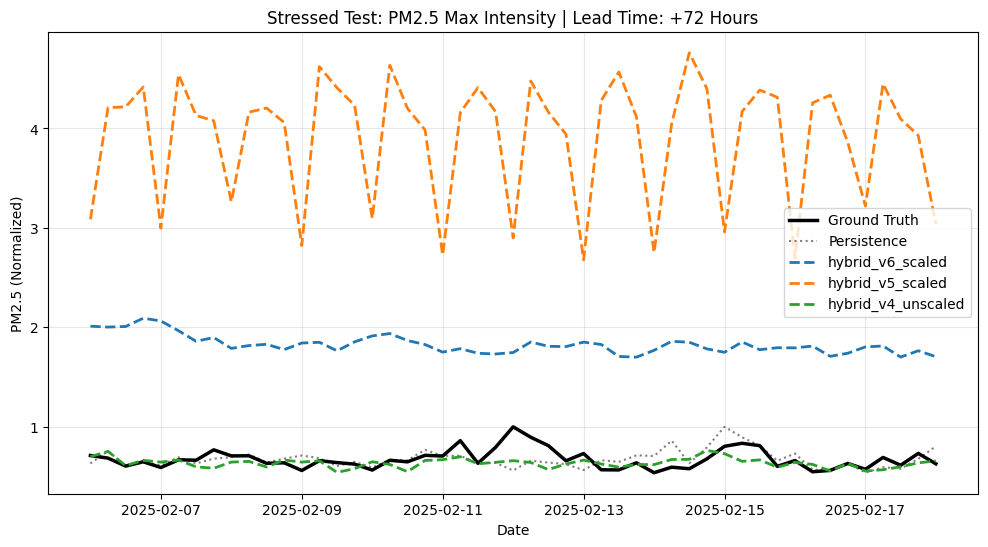

In [ ]:
import os, shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# -----------------------------
# 0) Load Data
# -----------------------------
NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    # Fallback copy if local file missing
    src = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
    if os.path.exists(src):
        shutil.copy(src, NPZ_LOCAL)
    else:
        src_alt = "/content/drive/MyDrive/isef/s.npz"
        if os.path.exists(src_alt): shutil.copy(src_alt, NPZ_LOCAL)

data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
T_total = len(X_full)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
time_index = pd.date_range("2022-01-01 00:00:00", periods=T_total, freq="6h", tz="UTC")
VAL_START = pd.Timestamp("2024-12-21 00:00:00", tz="UTC")
VAL_END   = pd.Timestamp("2025-06-30 18:00:00", tz="UTC")
PM25_IDX = 4

# -----------------------------
# 1) Corrected Model Configs
# -----------------------------
MODELS = [
    # V6 & V5: Trained WITH scaling -> Use scaling params
    {
        "name": "hybrid_v6_scaled",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
        "tp_div": 100.0, "tcrw_div": 200.0, "co_mul_x": 50.0, "co_mul_y": 50.0
    },
    {
        "name": "hybrid_v5_scaled",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        "tp_div": 100.0, "tcrw_div": 200.0, "co_mul_x": 50.0, "co_mul_y": 50.0
    },
    # V4: Trained WITHOUT scaling -> Must set params to None!
    {
       "name": "hybrid_v4_unscaled",
       "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
       # !!! FIX: Set scalers to None so V4 gets raw data !!!
       "tp_div": None, "tcrw_div": None, "co_mul_x": None, "co_mul_y": None
    },
]

# -----------------------------
# 2) Dataset (Preprocessing Logic)
# -----------------------------
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices, cfg, History, Horizon):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)
        self.cfg = cfg; self.History = History; self.Horizon = Horizon

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x_seq = torch.from_numpy(self.X[i : i + self.History]).float().clone()

        # Apply Scaling (Matches Training Config)
        if self.cfg.get("tp_div") and x_seq.shape[1] > 5:
            x_seq[:, 5, :, :] /= float(self.cfg["tp_div"])
        if self.cfg.get("tcrw_div") and x_seq.shape[1] > 6:
            x_seq[:, 6, :, :] /= float(self.cfg["tcrw_div"])
        if self.cfg.get("co_mul_x") and x_seq.shape[1] > 26:
            x_seq[:, 26, :, :] *= float(self.cfg["co_mul_x"])

        t0 = i + self.History
        t1 = t0 + self.Horizon
        if t1 > len(self.Y): t1 = len(self.Y)

        y_seq = torch.from_numpy(self.Y[t0:t1]).float().clone()
        m_seq = torch.from_numpy(self.M[t0:t1]).float()

        if self.cfg.get("co_mul_y"):
            y_seq[:, 0, :, :] *= float(self.cfg["co_mul_y"])

        if len(y_seq) < self.Horizon:
            pad = self.Horizon - len(y_seq)
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode="replicate")
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode="replicate")

        y_last = x_seq[-1, -6:, :, :]
        return x_seq, y_seq, m_seq, y_last

# -----------------------------
# 3) Architecture
# -----------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose: self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else: self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x): return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, Hid_S, Hid_T, History, Horizon):
        super().__init__()
        self.Hid_S = Hid_S; self.History = History; self.Horizon = Horizon
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, Hid_S, 3, 1, 1),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1)
        )
        mid_in = History * Hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in, Hid_T, 1, 1, 0),
            Inception(Hid_T, Hid_T), Inception(Hid_T, Hid_T),
            Inception(Hid_T, Hid_T), Inception(Hid_T, Hid_T),
        )
        self.time_projector = nn.Conv2d(Hid_T, Horizon * Hid_S, kernel_size=1)
        self.dec = nn.Sequential(
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(Hid_S, Hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(Hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, Hs, Ws = embed.shape
        embed_grouped = embed.view(B, T_in * self.Hid_S, Hs, Ws)
        features = self.mid(embed_grouped)
        future = self.time_projector(features).view(B * self.Horizon, self.Hid_S, Hs, Ws)
        delta = self.dec(future).view(B, self.Horizon, 6, H, W)
        last = x_seq[:, -1, -6:, :, :].unsqueeze(1)
        return last + delta

def infer_from_state_dict(state):
    Hid_S = int(state["enc.0.conv.weight"].shape[0])
    in_c = int(state["enc.0.conv.weight"].shape[1])
    Hid_T = int(state["mid.0.conv.weight"].shape[0])
    mid_in = int(state["mid.0.conv.weight"].shape[1])
    History = int(mid_in // Hid_S)
    Horizon = int(int(state["time_projector.weight"].shape[0]) // Hid_S)
    out_c = int(state["dec.2.weight"].shape[0])
    return in_c, out_c, Hid_S, Hid_T, History, Horizon

# -----------------------------
# 4) Helper: Find Event
# -----------------------------
def find_event_time_idx_pm25(val_start=VAL_START, val_end=VAL_END):
    start_idx = np.where(time_index.values == np.datetime64(val_start.to_datetime64()))[0][0]
    end_idx   = np.where(time_index.values == np.datetime64(val_end.to_datetime64()))[0][0]
    pm = Y_full[start_idx:end_idx+1, PM25_IDX]
    pm_max = np.nanmax(pm.reshape(pm.shape[0], -1), axis=1)
    return int(start_idx + np.argmax(pm_max))

EVENT_T_IDX = find_event_time_idx_pm25()
print(f"🔥 Event Center: {time_index[EVENT_T_IDX]}")

# -----------------------------
# 5) Stressed Series Extractor (FIXED INDEXING)
# -----------------------------
@torch.no_grad()
def stressed_series_for_model(model, cfg, History, Horizon, lead_step, window=20):
    rows = []
    # Loop over target times t
    for t in range(EVENT_T_IDX - window, EVENT_T_IDX + window + 1):

        # === FIX 1: CORRECT INDEXING LOGIC ===
        # If target is 't' and lead is 0 (+6h), last input frame is t-1.
        # Python slice [start:end] excludes end. So end must be 't - lead_step'.
        # For lead=0, end = t. Last item = t-1. Correct.
        slice_end = t - lead_step
        slice_start = slice_end - History

        # Bounds Check
        if slice_start < 0 or slice_end > T_total: continue

        # Prepare Input
        x_seq = torch.from_numpy(X_full[slice_start : slice_end]).float().clone()

        # Apply Scaling (Matches Config)
        if cfg.get("tp_div") and x_seq.shape[1] > 5: x_seq[:, 5, :, :] /= cfg["tp_div"]
        if cfg.get("tcrw_div") and x_seq.shape[1] > 6: x_seq[:, 6, :, :] /= cfg["tcrw_div"]
        if cfg.get("co_mul_x") and x_seq.shape[1] > 26: x_seq[:, 26, :, :] *= cfg["co_mul_x"]

        x_seq = x_seq.unsqueeze(0).to(DEVICE)

        # Predict
        pred_seq = model(x_seq) # (1, Horizon, 6, H, W)

        # Extract specific lead time prediction
        pred_pm = pred_seq[0, lead_step, PM25_IDX].detach().cpu().numpy()
        pred_max = float(np.nanmax(pred_pm))

        true_pm = Y_full[t, PM25_IDX]
        true_max = float(np.nanmax(true_pm))

        # Persistence Logic (Last known frame)
        last_input_idx = slice_end - 1
        pers_pm = Y_full[last_input_idx, PM25_IDX]
        pers_max = float(np.nanmax(pers_pm))

        rows.append({
            "time": time_index[t],
            "true_max": true_max,
            "pers_max": pers_max,
            "pred_max": pred_max,
        })
    return pd.DataFrame(rows).set_index("time")

# -----------------------------
# 6) Execution & Plotting
# -----------------------------
loaded_models = {}

for spec in MODELS:
    name = spec["name"]
    ckpt_path = f"/content/{name}.pth"
    if not os.path.exists(ckpt_path):
        if os.path.exists(spec["ckpt_drive"]):
            shutil.copy2(spec["ckpt_drive"], ckpt_path)
        else:
            print(f"⚠️ Checkpoint not found: {spec['ckpt_drive']}")
            continue

    state = torch.load(ckpt_path, map_location=DEVICE)
    in_c, out_c, Hid_S, Hid_T, Hist, Horiz = infer_from_state_dict(state)

    model = SimVPHybrid(in_c, out_c, Hid_S, Hid_T, Hist, Horiz).to(DEVICE)
    model.load_state_dict(state)
    model.eval()

    loaded_models[name] = {"model": model, "cfg": spec, "History": Hist, "Horizon": Horiz}
    print(f"✅ Loaded {name}")

def plot_stress_overlay(lead_hr):
    lead_step = (lead_hr // 6) - 1
    plt.figure(figsize=(12, 6))

    base_done = False
    for name, pack in loaded_models.items():
        if lead_step >= pack["Horizon"]: continue

        df = stressed_series_for_model(pack["model"], pack["cfg"],
                                      pack["History"], pack["Horizon"],
                                      lead_step, window=24) # +/- 6 days

        if not base_done:
            plt.plot(df.index, df["true_max"], 'k-', linewidth=2.5, label="Ground Truth")
            plt.plot(df.index, df["pers_max"], 'k:', alpha=0.5, label="Persistence")
            base_done = True

        plt.plot(df.index, df["pred_max"], linestyle='--', linewidth=2, label=name)

    plt.title(f"Stressed Test: PM2.5 Max Intensity | Lead Time: +{lead_hr} Hours")
    plt.ylabel("PM2.5 (Normalized)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n>>> Generating Corrected Stress Test Plots...")
plot_stress_overlay(6)
plot_stress_overlay(24)
plot_stress_overlay(72)

In [ ]:
# ============================================================
# LA DOWNTOWN (ROI) | Jan 7–31 2025 | PM2.5 maps + time series
# Forecast leads: +6h, +24h, +72h and Capture Ratio
#
# Assumptions:
# - Data cadence: 6-hourly starting 2022-01-01 00:00 UTC
# - NPZ contains arrays:
#       X: (time, C_in=32, H, W)
#       Y: (time, C_out=6, H, W)  with order ["CO","NO2","O3","PM10","PM2.5","SO2"]
#       Mask: same shape as Y
# - Model outputs: (B, Horizon, 6, H, W), where pred[:,0] is +6h, pred[:,11] is +72h
# - Your LA grid coordinates are either:
#   (A) loaded from an optional NetCDF with lat/lon coords, OR
#   (B) reconstructed from the known grid (lat 28..49.75 step 0.25, lon -135..-105.25 step 0.25)
# ============================================================

import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# ----------------------------
# USER SETTINGS (EDIT THESE)
# ----------------------------
NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"

# Put your model checkpoint here (72h model / hybrid / etc.)
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth"

# Optional NetCDF that contains lat/lon coords (recommended if you have it).
# Example: "/content/drive/MyDrive/isef/pollution_6vars.nc"
GRID_NC_PATH = ""   # leave "" to use fallback grid construction

# If your model was trained with v5-style preprocessing (tp/tcrw scaling + CO scaling), set True.
# If your model was trained like v4 (no scaling), set False.
USE_V5_PREPROC = True

# Downtown LA approx center
CENTER_LAT = 34.05
CENTER_LON = -118.25
HALF_SIZE_DEG = 0.5   # 0.5 => about 1°x1° box. Set 0.0 for nearest single grid cell.

# Time window (UTC)
START_UTC = "2025-01-05 00:00:00+00:00"
END_UTC   = "2025-01-31 18:00:00+00:00"

# Forecast lead times you want (hours)
LEADS_HOURS = [6, 24, 72]

# PM2.5 channel index in Y
PM25_IDX = 4

# Local cache paths to avoid Drive disconnects
NPZ_LOCAL  = "/content/local_data.npz"
CKPT_LOCAL = "/content/local_model.pth"

# ----------------------------
# Mount Drive
# ----------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ----------------------------
# Copy NPZ + CKPT to local disk
# ----------------------------
def safe_copy(src, dst):
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing: {src}")
    print(f"Copying -> {dst}")
    shutil.copy2(src, dst)
    print("  size:", os.path.getsize(dst))

if (not os.path.exists(NPZ_LOCAL)) or (os.path.getsize(NPZ_LOCAL) == 0):
    safe_copy(NPZ_DRIVE, NPZ_LOCAL)
else:
    print("✅ NPZ already cached locally:", NPZ_LOCAL)

safe_copy(CKPT_DRIVE, CKPT_LOCAL)

# ----------------------------
# Load data
# ----------------------------
print("Loading NPZ...")
data = np.load(NPZ_LOCAL)
X_full = data["X"]     # (T, 32, H, W)
Y_full = data["Y"]     # (T, 6, H, W)
M_full = data["Mask"]  # (T, 6, H, W)

T, C_in, H, W = X_full.shape
print("X:", X_full.shape, "Y:", Y_full.shape, "Mask:", M_full.shape)

# Build 6-hourly time index
time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6h", tz="UTC")

start_dt = pd.Timestamp(START_UTC)
end_dt   = pd.Timestamp(END_UTC)

# Indices of target times in your window
target_ts = np.where((time_index >= start_dt) & (time_index <= end_dt))[0]
if len(target_ts) == 0:
    raise RuntimeError("No timestamps found in requested window. Check START_UTC/END_UTC.")

print(f"Target window steps: {len(target_ts)}")
print("Window:", time_index[target_ts[0]], "→", time_index[target_ts[-1]])

# ----------------------------
# Lat/Lon grid
# ----------------------------
lat = None
lon = None

if GRID_NC_PATH and os.path.exists(GRID_NC_PATH):
    try:
        import xarray as xr
        ds = xr.open_dataset(GRID_NC_PATH)
        if "lat" in ds.coords and "lon" in ds.coords:
            lat = ds["lat"].values
            lon = ds["lon"].values
            print("✅ Loaded lat/lon from NetCDF:", GRID_NC_PATH)
        ds.close()
    except Exception as e:
        print("⚠️ Could not read NetCDF lat/lon, falling back to assumed grid:", e)

if lat is None or lon is None:
    # Fallback: from your earlier dataset printout (88 lat, 120 lon)
    # lat: 28.0 .. 49.75 step 0.25  (88 points)
    # lon: -135.0 .. -105.25 step 0.25 (120 points)
    lat = np.linspace(28.0, 49.75, H)
    lon = np.linspace(-135.0, -105.25, W)
    print("⚠️ Using fallback lat/lon grid (assumed regular 0.25°).")
    print("   lat range:", lat.min(), "→", lat.max(), "N=", len(lat))
    print("   lon range:", lon.min(), "→", lon.max(), "N=", len(lon))

# ----------------------------
# ROI selection: LA Downtown box
# ----------------------------
def roi_indices(lat, lon, center_lat, center_lon, half_deg):
    if half_deg <= 0:
        ilat = int(np.argmin(np.abs(lat - center_lat)))
        ilon = int(np.argmin(np.abs(lon - center_lon)))
        return np.array([ilat]), np.array([ilon])

    lat_mask = (lat >= center_lat - half_deg) & (lat <= center_lat + half_deg)
    lon_mask = (lon >= center_lon - half_deg) & (lon <= center_lon + half_deg)

    ilats = np.where(lat_mask)[0]
    ilons = np.where(lon_mask)[0]

    if len(ilats) == 0 or len(ilons) == 0:
        # fallback to nearest cell
        ilat = int(np.argmin(np.abs(lat - center_lat)))
        ilon = int(np.argmin(np.abs(lon - center_lon)))
        return np.array([ilat]), np.array([ilon])

    return ilats, ilons

ilat, ilon = roi_indices(lat, lon, CENTER_LAT, CENTER_LON, HALF_SIZE_DEG)

print("\nROI indices:")
print("  lat idx:", ilat[0], "→", ilat[-1], " | lat:", lat[ilat[0]], "→", lat[ilat[-1]])
print("  lon idx:", ilon[0], "→", ilon[-1], " | lon:", lon[ilon[0]], "→", lon[ilon[-1]])
print("  ROI shape:", len(ilat), "x", len(ilon))

# ----------------------------
# Helpers: masked ROI max / mean
# ----------------------------
def masked_roi_stat(arr2d, mask2d, ilat, ilon, mode="max"):
    # arr2d, mask2d are (H,W)
    a = arr2d[np.ix_(ilat, ilon)].astype(np.float64)
    m = mask2d[np.ix_(ilat, ilon)].astype(np.float64)
    a = np.where(m > 0.5, a, np.nan)
    if mode == "max":
        return np.nanmax(a)
    elif mode == "mean":
        return np.nanmean(a)
    else:
        raise ValueError("mode must be 'max' or 'mean'")

# ----------------------------
# Model: SimVPHybrid (same as your hybrid architecture)
# We infer hid_S, hid_T, History, Horizon from checkpoint shapes
# ----------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        # keep GroupNorm stable
        g = 8 if out_c % 8 == 0 else (4 if out_c % 4 == 0 else 2)
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T, T_in, T_out):
        super().__init__()
        self.hid_S = hid_S
        self.T_in = T_in
        self.T_out = T_out

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
        )
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, C, H, W)
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)                    # (B*T_in, hid_S, H', W')
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in * self.hid_S, Hp, Wp)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)          # (B, T_out*hid_S, Hp, Wp)

        future_flat = future_features.view(B * self.T_out, self.hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)                       # (B*T_out, 6, H, W)
        delta_seq = delta_flat.view(B, self.T_out, 6, H, W)

        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)         # (B,1,6,H,W)
        return last_frame + delta_seq                              # (B,T_out,6,H,W)

def infer_hparams_from_ckpt(state):
    # Infer hid_S from encoder first conv
    # enc.0.conv.weight: (hid_S, in_channels, 3, 3)
    k_enc = None
    for k in state.keys():
        if k.endswith("enc.0.conv.weight"):
            k_enc = k
            break
    if k_enc is None:
        raise RuntimeError("Cannot find enc.0.conv.weight in checkpoint. Is this a SimVPHybrid checkpoint?")

    hid_S = state[k_enc].shape[0]
    in_channels = state[k_enc].shape[1]

    # Infer hid_T and T_in from mid.0.conv.weight: (hid_T, T_in*hid_S, 1, 1)
    k_mid0 = None
    for k in state.keys():
        if k.endswith("mid.0.conv.weight"):
            k_mid0 = k
            break
    if k_mid0 is None:
        raise RuntimeError("Cannot find mid.0.conv.weight in checkpoint.")

    hid_T = state[k_mid0].shape[0]
    mid_in = state[k_mid0].shape[1]
    if mid_in % hid_S != 0:
        raise RuntimeError(f"mid_in ({mid_in}) not divisible by hid_S ({hid_S}); cannot infer T_in safely.")
    T_in = mid_in // hid_S

    # Infer T_out from time_projector.weight: (T_out*hid_S, hid_T, 1, 1)
    k_tp = None
    for k in state.keys():
        if k.endswith("time_projector.weight"):
            k_tp = k
            break
    if k_tp is None:
        raise RuntimeError("Cannot find time_projector.weight in checkpoint.")

    out_ch = state[k_tp].shape[0]
    if out_ch % hid_S != 0:
        raise RuntimeError(f"time_projector out_ch ({out_ch}) not divisible by hid_S ({hid_S}); cannot infer T_out safely.")
    T_out = out_ch // hid_S

    return in_channels, int(hid_S), int(hid_T), int(T_in), int(T_out)

# ----------------------------
# Preprocessing (match v5 training)
# ----------------------------
def apply_v5_preproc(x_seq_torch):
    """
    x_seq_torch: (T, 32, H, W) torch.float
    Applies:
      - tp (X[05]) /= 100
      - tcrw (X[06]) /= 200
      - CO (X[26]) *= 50
    """
    x = x_seq_torch.clone()
    x[:, 5, :, :]  = x[:, 5, :, :] / 100.0
    x[:, 6, :, :]  = x[:, 6, :, :] / 200.0
    x[:, 26, :, :] = x[:, 26, :, :] * 50.0
    return x

# ----------------------------
# Load checkpoint + build model
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nLoading checkpoint:", CKPT_LOCAL)
state = torch.load(CKPT_LOCAL, map_location=device)

# Some people save {"state_dict": ...}
if isinstance(state, dict) and "state_dict" in state and any(k.startswith("enc.") for k in state["state_dict"].keys()):
    state = state["state_dict"]

in_channels_ckpt, hid_S, hid_T, T_in, T_out = infer_hparams_from_ckpt(state)
print(f"✅ ckpt inferred: in_channels={in_channels_ckpt}, Hid_S={hid_S}, Hid_T={hid_T}, History={T_in}, Horizon={T_out}")

if in_channels_ckpt != C_in:
    print(f"⚠️ Warning: checkpoint expects in_channels={in_channels_ckpt} but X has {C_in}. "
          f"If you changed X channels, this checkpoint won't match.")

model = SimVPHybrid(in_channels=in_channels_ckpt, out_channels=6, hid_S=hid_S, hid_T=hid_T, T_in=T_in, T_out=T_out).to(device)
model.load_state_dict(state, strict=True)
model.eval()
print("✅ Model loaded & set to eval()")

# ----------------------------
# Convert lead hours -> step indices in the model output
# pred[:,0] is +6h, pred[:,3] is +24h, pred[:,11] is +72h
# ----------------------------
lead_steps = []
for h in LEADS_HOURS:
    if h % 6 != 0:
        raise ValueError("LEADS_HOURS must be multiples of 6.")
    step = h // 6
    if step < 1 or step > T_out:
        raise ValueError(f"Lead {h}h requires step={step}, but model horizon is {T_out}.")
    lead_steps.append(step)

lead_to_outidx = {h: (h//6 - 1) for h in LEADS_HOURS}
print("Lead hour -> output index:", lead_to_outidx)

# ----------------------------
# Compute truth series (ROI spatial MAX) in window
# ----------------------------
truth_max = np.full(len(target_ts), np.nan, dtype=np.float64)
for j, t in enumerate(target_ts):
    truth_max[j] = masked_roi_stat(Y_full[t, PM25_IDX], M_full[t, PM25_IDX], ilat, ilon, mode="max")

# Peak time in truth
peak_j = int(np.nanargmax(truth_max))
peak_t = int(target_ts[peak_j])
print("\nPeak truth ROI MAX(PM2.5) time:", time_index[peak_t], " value:", truth_max[peak_j])

# ----------------------------
# Prepare prediction series arrays per lead
# We'll fill these by running the model over "base times" that can produce targets in the window.
# For a target time t_target and lead step s, base time is t_base = t_target - s.
# Sample i = t_base - (T_in - 1)
# ----------------------------
pred_max = {h: np.full(len(target_ts), np.nan, dtype=np.float64) for h in LEADS_HOURS}
pers_max = {h: np.full(len(target_ts), np.nan, dtype=np.float64) for h in LEADS_HOURS}

target_pos = {int(t): j for j, t in enumerate(target_ts.tolist())}
target_set = set(target_pos.keys())

max_step = max(lead_steps)
min_step = min(lead_steps)

base_min = int(target_ts[0]) - max_step
base_max = int(target_ts[-1]) - min_step

# Clamp base range to valid
base_min = max(base_min, T_in - 1)
base_max = min(base_max, T - 1)

print(f"\nBase time range for forecasts: idx {base_min} → {base_max}")
print("Base times:", time_index[base_min], "→", time_index[base_max])

@torch.no_grad()
def run_one_base(base_t):
    """
    Runs model for a single base time index base_t (this is the last observed time).
    Returns pred_seq for PM2.5: (T_out, H, W) on CPU numpy
    """
    i = base_t - (T_in - 1)  # dataset start index for history window
    if i < 0 or (i + T_in) > T:
        return None

    x_seq = X_full[i : i + T_in]  # (T_in, 32, H, W)
    x_seq_t = torch.from_numpy(x_seq).float()

    if USE_V5_PREPROC:
        x_seq_t = apply_v5_preproc(x_seq_t)

    x_seq_t = x_seq_t.unsqueeze(0).to(device)  # (1,T_in,C,H,W)
    pred = model(x_seq_t)                      # (1,T_out,6,H,W)
    pm25_seq = pred[0, :, PM25_IDX].detach().cpu().numpy()  # (T_out,H,W)
    return pm25_seq

# Fill prediction series
print("\nRunning forecasts over base times...")
for base_t in range(base_min, base_max + 1):
    pm25_seq = run_one_base(base_t)
    if pm25_seq is None:
        continue

    for h in LEADS_HOURS:
        out_idx = lead_to_outidx[h]        # 0-based index in model output
        step = h // 6                      # 1..T_out
        target_t = base_t + step

        if target_t not in target_set:
            continue

        j = target_pos[target_t]

        # Apply *target-time* mask when computing pred max
        m_targ = M_full[target_t, PM25_IDX]         # (H,W)
        y_base = Y_full[base_t, PM25_IDX]           # persistence baseline at base time

        pred_max[h][j] = masked_roi_stat(pm25_seq[out_idx], m_targ, ilat, ilon, mode="max")
        pers_max[h][j] = masked_roi_stat(y_base,      m_targ, ilat, ilon, mode="max")

print("✅ Forecast series computed.")

# ----------------------------
# Capture ratio (amplitude and peak) per lead
# ----------------------------
def safe_amp(x):
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(np.max(x) - np.min(x))

true_amp = safe_amp(truth_max)
true_peak = float(np.nanmax(truth_max))

print("\n================ CAPTURE RATIO (ROI spatial MAX PM2.5) ================")
print(f"Truth amplitude (max-min) = {true_amp:.6f}")
print(f"Truth peak (max)          = {true_peak:.6f}")
for h in LEADS_HOURS:
    pa = safe_amp(pred_max[h])
    pp = float(np.nanmax(pred_max[h]))
    cap_amp = 100.0 * (pa / true_amp) if (np.isfinite(pa) and true_amp > 0) else np.nan
    cap_peak = 100.0 * (pp / true_peak) if (np.isfinite(pp) and true_peak > 0) else np.nan
    print(f"Lead +{h:02d}h | pred_amp={pa:.6f}  pred_peak={pp:.6f}  Capture(amp)={cap_amp:.1f}%  Capture(peak)={cap_peak:.1f}%")

# ----------------------------
# Plot time series (Truth vs Forecast vs Persistence) for each lead
# ----------------------------
times = time_index[target_ts]

for h in LEADS_HOURS:
    plt.figure(figsize=(14,5))
    plt.plot(times, truth_max, label="Truth ROI MAX(PM2.5)", linewidth=2)
    plt.plot(times, pers_max[h], label=f"Persistence MAX(PM2.5) lead +{h}h", linestyle=":", linewidth=2)
    plt.plot(times, pred_max[h], label=f"Model MAX(PM2.5) lead +{h}h", linestyle="--", linewidth=2)
    plt.title(f"LA Downtown ROI | PM2.5 Spatial MAX | {START_UTC} → {END_UTC} | Lead +{h}h", fontsize=13)
    plt.ylabel("PM2.5 (your normalized space)")
    plt.xlabel("UTC time")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# Plot maps at PEAK truth time: Truth vs Forecast(+6/+24/+72) and Abs Error
# ----------------------------
def plot_map(ax, arr2d, title, extent):
    im = ax.imshow(arr2d, origin="lower", extent=extent)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    return im

# Determine extent for ROI
lat_roi = lat[ilat]
lon_roi = lon[ilon]
extent = (lon_roi.min(), lon_roi.max(), lat_roi.min(), lat_roi.max())

# Extract truth map for peak time
truth_map_full = Y_full[peak_t, PM25_IDX]
mask_map_full  = M_full[peak_t, PM25_IDX]
truth_roi = truth_map_full[np.ix_(ilat, ilon)].astype(np.float64)
mask_roi  = mask_map_full[np.ix_(ilat, ilon)].astype(np.float64)
truth_roi = np.where(mask_roi > 0.5, truth_roi, np.nan)

# For each lead: make forecast map aligned to peak target time
for h in LEADS_HOURS:
    step = h // 6
    base_t = peak_t - step

    # If base time invalid, skip
    if base_t < (T_in - 1):
        print(f"⚠️ Cannot plot lead +{h}h at peak time; base_t too early.")
        continue

    pm25_seq = run_one_base(base_t)
    out_idx = lead_to_outidx[h]
    pred_full = pm25_seq[out_idx]  # (H,W) PM2.5
    pred_roi = pred_full[np.ix_(ilat, ilon)].astype(np.float64)
    pred_roi = np.where(mask_roi > 0.5, pred_roi, np.nan)

    err_roi = np.abs(pred_roi - truth_roi)

    fig = plt.figure(figsize=(16,4))
    ax1 = plt.subplot(1,3,1)
    ax2 = plt.subplot(1,3,2)
    ax3 = plt.subplot(1,3,3)

    im1 = plot_map(ax1, truth_roi, f"Truth PM2.5\nTarget {time_index[peak_t]}", extent)
    im2 = plot_map(ax2, pred_roi,  f"Forecast PM2.5 (+{h}h)\nBase {time_index[base_t]}", extent)
    im3 = plot_map(ax3, err_roi,   f"|Error| PM2.5 (+{h}h)", extent)

    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    plt.suptitle(f"LA Downtown ROI maps at peak truth time | Lead +{h}h", fontsize=13)
    plt.tight_layout()
    plt.show()

print("\nDONE.")


Mounting Google Drive...
Mounted at /content/drive
Copying -> /content/local_data.npz
  size: 4011023020
Copying -> /content/local_model.pth
  size: 92519611
Loading NPZ...
X: (5108, 32, 88, 120) Y: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Target window steps: 108
Window: 2025-01-05 00:00:00+00:00 → 2025-01-31 18:00:00+00:00
⚠️ Using fallback lat/lon grid (assumed regular 0.25°).
   lat range: 28.0 → 49.75 N= 88
   lon range: -135.0 → -105.25 N= 120

ROI indices:
  lat idx: 23 → 26  | lat: 33.75 → 34.5
  lon idx: 65 → 69  | lon: -118.75 → -117.75
  ROI shape: 4 x 5

Loading checkpoint: /content/local_model.pth
✅ ckpt inferred: in_channels=32, Hid_S=64, Hid_T=256, History=12, Horizon=12


RuntimeError: Error(s) in loading state_dict for SimVPHybrid:
	size mismatch for dec.2.weight: copying a param with shape torch.Size([5, 64, 3, 3]) from checkpoint, the shape in current model is torch.Size([6, 64, 3, 3]).
	size mismatch for dec.2.bias: copying a param with shape torch.Size([5]) from checkpoint, the shape in current model is torch.Size([6]).

GPT version test on malibu fire

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using cached local file: /content/local_data.npz  size: 4011023020
Using cached local file: /content/local_model.pth  size: 92521425
Device: cuda
Loading NPZ...
X: (5108, 32, 88, 120) Y: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Target window steps: 44
Window: 2025-02-07 00:00:00+00:00 → 2025-02-17 18:00:00+00:00
lat range: 28.0 → 49.75 N= 88
lon range: -135.0 → -105.25 N= 120

ROI indices:
  lat idx: 23 → 26  | lat: 33.75 → 34.5
  lon idx: 65 → 69  | lon: -118.75 → -117.75
  ROI shape: 4 x 5

Loading checkpoint: /content/local_model.pth
✅ ckpt inferred: in_channels=32, Hid_S=64, Hid_T=256, History=12, Horizon=12, out_channels=6
Model output channels: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']
PM2.5 index: truth(Y) = 4  model(pred) = 4
✅ Model loaded & set to eval()

===================== RESULTS (ROI spatial MAX of PM2.5) ========

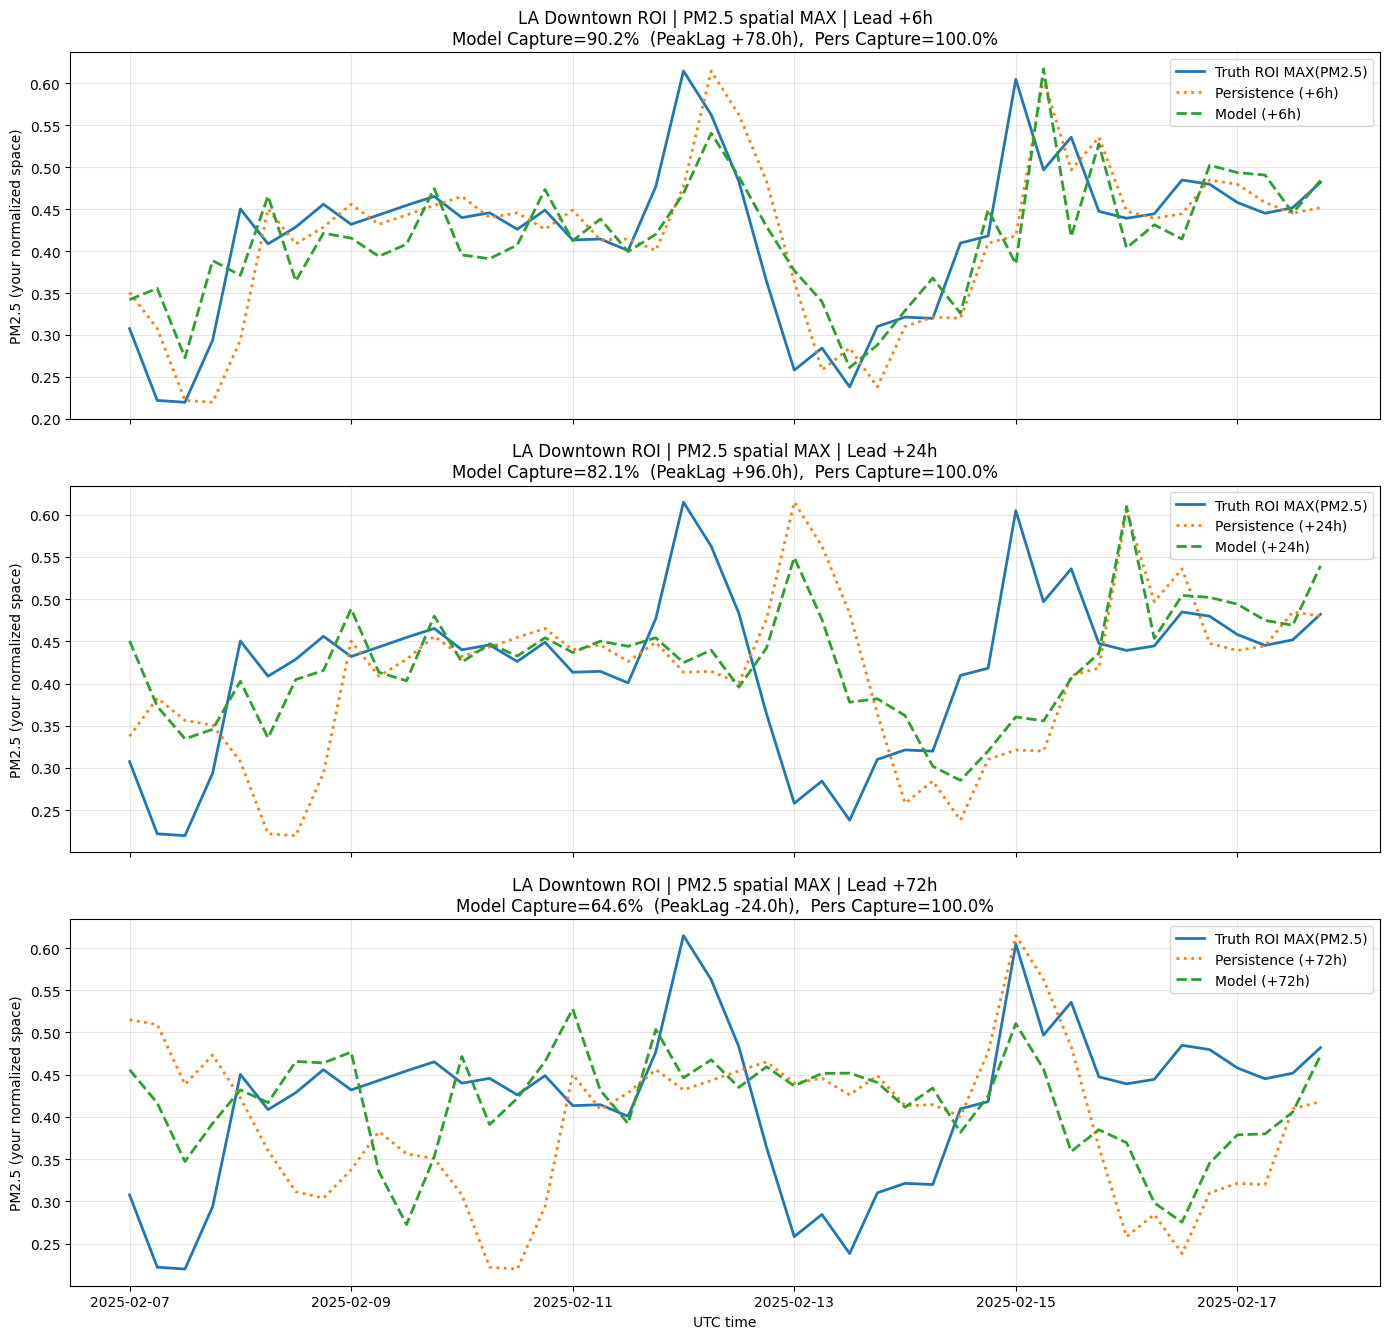


Peak truth time (in window): 2025-02-12 00:00:00+00:00


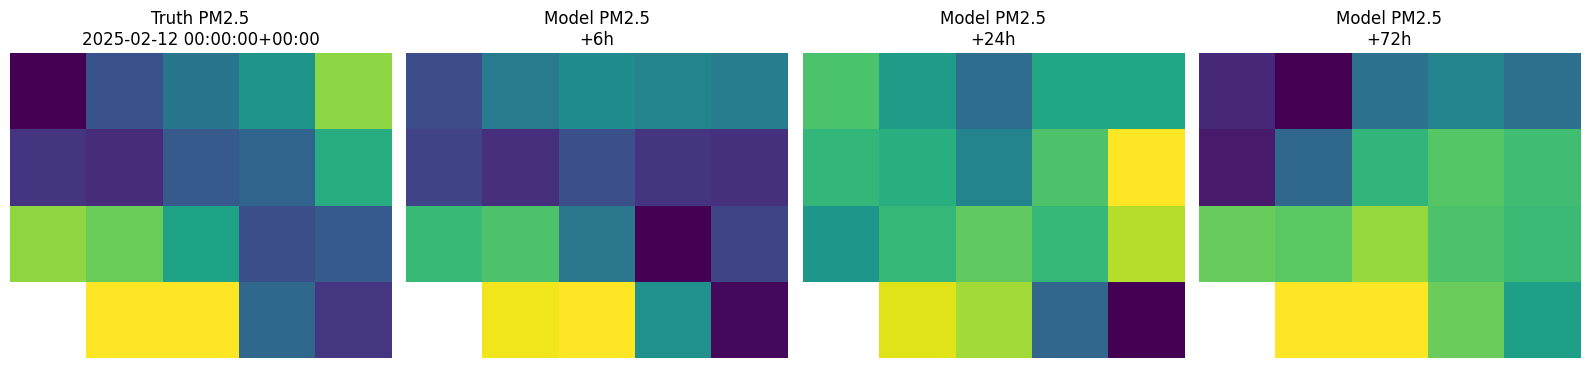

In [ ]:
# ============================================================
# FIXED COMPLETE TEST SCRIPT (Colab):
# ✅ Works for BOTH 6-output models and 5-output models (CO dropped)
# ✅ Plots LA Downtown ROI time-series during Malibu-fire window (Jan 7–31, 2025)
# ✅ Compares: Truth vs Persistence vs Model forecasts at +6h, +24h, +72h
# ✅ Computes capture ratio (spike amplitude) + MAE/MSE/R^2 on the ROI time series
#
# NOTES YOU MUST SET:
# 1) NPZ_DRIVE  -> your processed_simvp_data.npz path on Google Drive
# 2) CKPT_DRIVE -> your model checkpoint path (.pth)
# 3) If your model was trained with input scaling (tp/tcrw/CO), set DO_INPUT_SCALING=True
# ============================================================

import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# ----------------------------
# USER SETTINGS
# ----------------------------
NPZ_DRIVE  = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_DRIVE = "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth"   # <- change to your .pth

# Local cache to avoid Drive disconnects
NPZ_LOCAL  = "/content/local_data.npz"
CKPT_LOCAL = "/content/local_model.pth"

# Malibu fire window (6-hour cadence)
EVENT_START = pd.Timestamp("2025-02-07 00:00:00", tz="UTC")
EVENT_END   = pd.Timestamp("2025-02-17 18:00:00", tz="UTC")

# LA Downtown-ish ROI (edit if you want tighter/wider)
ROI_LAT_MIN, ROI_LAT_MAX = 33.75, 34.50
ROI_LON_MIN, ROI_LON_MAX = -118.75, -117.75

# Forecast leads you want to plot (must be multiples of 6 hours)
LEADS_HOURS = [6, 24, 72]

# If your training Dataset applied these scalings (like your v5 code), set True:
DO_INPUT_SCALING = True
TP_DIV   = 100.0   # X[05] era5:tp  /= 100
TCRW_DIV = 200.0   # X[06] era5:tcrw/= 200
CO_MUL   = 50.0    # X[26] pollution:CO *= 50 (input scaling)

# Coordinate/time assumptions (from your dataset description)
TIME0 = "2022-01-01 00:00:00"   # first timestep timestamp
FREQ  = "6h"                    # 6-hour cadence

# Y channel names/order (you confirmed this from xarray)
Y_TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
PM25_Y_IDX = Y_TARGET_NAMES.index("PM2.5")

# Default assumption for 5-output model order (CO dropped only):
DEFAULT_MODEL_NAMES_6 = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
DEFAULT_MODEL_NAMES_5 = ["NO2", "O3", "PM10", "PM2.5", "SO2"]


# ----------------------------
# Mount Drive + copy locally
# ----------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

def copy_if_needed(src, dst):
    if not os.path.exists(dst):
        print(f"Copying -> {dst}")
        shutil.copy2(src, dst)
        print("  size:", os.path.getsize(dst))
    else:
        print(f"Using cached local file: {dst}  size:", os.path.getsize(dst))

assert os.path.exists(NPZ_DRIVE),  f"Missing NPZ on Drive: {NPZ_DRIVE}"
assert os.path.exists(CKPT_DRIVE), f"Missing CKPT on Drive: {CKPT_DRIVE}"

copy_if_needed(NPZ_DRIVE, NPZ_LOCAL)
copy_if_needed(CKPT_DRIVE, CKPT_LOCAL)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# ----------------------------
# Load NPZ
# ----------------------------
print("Loading NPZ...")
data = np.load(NPZ_LOCAL)
X_full = data["X"]     # (time, C_in, lat, lon)
Y_full = data["Y"]     # (time, 6, lat, lon)
M_full = data["Mask"]  # (time, 6, lat, lon)

T, C_in, H, W = X_full.shape
print("X:", X_full.shape, "Y:", Y_full.shape, "Mask:", M_full.shape)


# ----------------------------
# Build time index and window indices
# ----------------------------
time_index = pd.date_range(TIME0, periods=T, freq=FREQ, tz="UTC")

win_mask = (time_index >= EVENT_START) & (time_index <= EVENT_END)
win_idx = np.where(win_mask)[0]
assert len(win_idx) > 0, "No timesteps found in the requested window."

print("Target window steps:", len(win_idx))
print("Window:", time_index[win_idx[0]], "→", time_index[win_idx[-1]])


# ----------------------------
# Lat/Lon grid (fallback)
# ----------------------------
# Your xarray showed lat: 28.0..49.75 (88), lon: -135.0..-105.25 (120), ~0.25°
lat = np.linspace(28.0, 49.75, H)
lon = np.linspace(-135.0, -105.25, W)
print("lat range:", lat[0], "→", lat[-1], "N=", len(lat))
print("lon range:", lon[0], "→", lon[-1], "N=", len(lon))

lat_idx = np.where((lat >= ROI_LAT_MIN) & (lat <= ROI_LAT_MAX))[0]
lon_idx = np.where((lon >= ROI_LON_MIN) & (lon <= ROI_LON_MAX))[0]
assert len(lat_idx) > 0 and len(lon_idx) > 0, "ROI box does not intersect the grid."

lat0, lat1 = lat_idx[0], lat_idx[-1] + 1
lon0, lon1 = lon_idx[0], lon_idx[-1] + 1

print("\nROI indices:")
print(f"  lat idx: {lat0} → {lat1-1}  | lat: {lat[lat0]} → {lat[lat1-1]}")
print(f"  lon idx: {lon0} → {lon1-1}  | lon: {lon[lon0]} → {lon[lon1-1]}")
print("  ROI shape:", (lat1-lat0), "x", (lon1-lon0))


# ----------------------------
# Helper: masked ROI spatial max time series for truth
# ----------------------------
def roi_spatial_max_from_Y(t_indices):
    # Extract PM2.5 truth and mask in one shot
    y = Y_full[t_indices, PM25_Y_IDX, lat0:lat1, lon0:lon1]
    m = M_full[t_indices, PM25_Y_IDX, lat0:lat1, lon0:lon1]
    y_masked = np.where(m > 0.5, y, np.nan)
    return np.nanmax(y_masked.reshape(len(t_indices), -1), axis=1)

truth_series = roi_spatial_max_from_Y(win_idx)


# ----------------------------
# Model definition (must match your training architecture)
# (Updated: supports out_channels=5 or 6)
# ----------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T, T_in, T_out):
        super().__init__()
        self.hid_S = hid_S
        self.T_in = T_in
        self.T_out = T_out
        self.out_channels = out_channels

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
        )

        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1),
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, C, H, W)
        B, T_in, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)  # (B*T_in, hid_S, H', W')
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in * self.hid_S, Hp, Wp)
        features = self.mid(embed_grouped)

        future_features = self.time_projector(features)  # (B, T_out*hid_S, Hp, Wp)

        future_flat = future_features.view(B * self.T_out, self.hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)               # (B*T_out, out_channels, H, W)

        delta_seq = delta_flat.view(B, self.T_out, self.out_channels, H, W)

        # Residual anchor uses last out_channels of X (CO..SO2 if 6, NO2..SO2 if 5)
        last_frame = x_seq[:, -1, -self.out_channels:, :, :].unsqueeze(1)  # (B,1,out_channels,H,W)

        return last_frame + delta_seq


# ----------------------------
# Load checkpoint robustly + infer dims (including out_channels=5 vs 6)
# ----------------------------
print("\nLoading checkpoint:", CKPT_LOCAL)
state = torch.load(CKPT_LOCAL, map_location="cpu")

# Handle wrapped checkpoints
if isinstance(state, dict) and "state_dict" in state and isinstance(state["state_dict"], dict):
    state = state["state_dict"]

# Strip possible "module." prefix
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

# Infer core dims
# enc.0.conv.weight: [hid_S, in_channels, 3, 3]
hid_S = int(state["enc.0.conv.weight"].shape[0])
in_channels_ckpt = int(state["enc.0.conv.weight"].shape[1])

# mid.0.conv.weight: [hid_T, (T_in*hid_S), 1, 1]
hid_T = int(state["mid.0.conv.weight"].shape[0])
T_in = int(state["mid.0.conv.weight"].shape[1] // hid_S)

# time_projector.weight: [T_out*hid_S, hid_T, 1, 1]
T_out = int(state["time_projector.weight"].shape[0] // hid_S)

# dec.2.weight: [out_channels, hid_S, 3, 3]
out_channels = int(state["dec.2.weight"].shape[0])

print(f"✅ ckpt inferred: in_channels={in_channels_ckpt}, Hid_S={hid_S}, Hid_T={hid_T}, History={T_in}, Horizon={T_out}, out_channels={out_channels}")

# Decide output name mapping
if out_channels == 6:
    model_out_names = DEFAULT_MODEL_NAMES_6
elif out_channels == 5:
    model_out_names = DEFAULT_MODEL_NAMES_5
else:
    raise ValueError(f"Unsupported out_channels={out_channels}. Add mapping.")

PM25_MODEL_IDX = model_out_names.index("PM2.5")
print("Model output channels:", model_out_names)
print("PM2.5 index: truth(Y) =", PM25_Y_IDX, " model(pred) =", PM25_MODEL_IDX)

# Instantiate and load model
model = SimVPHybrid(
    in_channels=in_channels_ckpt,
    out_channels=out_channels,
    hid_S=hid_S,
    hid_T=hid_T,
    T_in=T_in,
    T_out=T_out
).to(device)

model.load_state_dict(state, strict=True)
model.eval()
print("✅ Model loaded & set to eval()")


# ----------------------------
# Forecast helpers
# ----------------------------
def preprocess_x_seq(x_seq_torch):
    """
    x_seq_torch: (1, T_in, C_in, H, W) float tensor on device
    Apply SAME input scaling used in training, if enabled.
    """
    if not DO_INPUT_SCALING:
        return x_seq_torch

    # Channel indices from your mapping:
    # X[05]=tp, X[06]=tcrw, X[26]=CO
    x_seq_torch = x_seq_torch.clone()
    x_seq_torch[:, :, 5, :, :]  = x_seq_torch[:, :, 5, :, :] / TP_DIV
    x_seq_torch[:, :, 6, :, :]  = x_seq_torch[:, :, 6, :, :] / TCRW_DIV
    x_seq_torch[:, :, 26, :, :] = x_seq_torch[:, :, 26, :, :] * CO_MUL
    return x_seq_torch

@torch.no_grad()
def model_roi_series_for_lead(lead_steps):
    """
    Returns predicted ROI spatial max series aligned to win_idx.
    lead_steps: 1=+6h, 4=+24h, 12=+72h, etc.
    """
    preds = np.full(len(win_idx), np.nan, dtype=np.float32)

    for j, t_verify in enumerate(win_idx):
        # We need an input history ending at origin time t_origin = t_verify - lead_steps
        t_origin = t_verify - lead_steps

        # History window starts at i such that i+T_in-1 = t_origin  => i = t_origin - (T_in-1)
        i = t_origin - (T_in - 1)

        # Validity checks
        if i < 0:
            continue
        if i + T_in > T:
            continue
        if (lead_steps - 1) >= T_out:
            continue  # model doesn't predict that far

        x_seq_np = X_full[i:i+T_in]  # (T_in, C_in, H, W)
        x_seq = torch.from_numpy(x_seq_np).float().unsqueeze(0).to(device)  # (1,T_in,C,H,W)
        x_seq = preprocess_x_seq(x_seq)

        pred_seq = model(x_seq)  # (1,T_out,out_channels,H,W)
        pm25_map = pred_seq[0, lead_steps - 1, PM25_MODEL_IDX].detach().cpu().numpy()

        # Apply truth mask at verification time
        m = M_full[t_verify, PM25_Y_IDX, :, :]
        pm25_map = np.where(m > 0.5, pm25_map, np.nan)

        # ROI spatial max
        roi = pm25_map[lat0:lat1, lon0:lon1]
        preds[j] = np.nanmax(roi)

    return preds

def persistence_roi_series_for_lead(lead_steps):
    """
    Persistence forecast: y_hat(t) = y(t - lead)
    Computed on the same ROI with same mask at verification time.
    """
    pers = np.full(len(win_idx), np.nan, dtype=np.float32)

    for j, t_verify in enumerate(win_idx):
        t_origin = t_verify - lead_steps
        if t_origin < 0:
            continue

        y_map = Y_full[t_origin, PM25_Y_IDX, :, :]
        m_map = M_full[t_verify, PM25_Y_IDX, :, :]  # mask at verify time
        y_map = np.where(m_map > 0.5, y_map, np.nan)

        roi = y_map[lat0:lat1, lon0:lon1]
        pers[j] = np.nanmax(roi)

    return pers

def metrics_and_capture_ratio(truth, pred):
    """
    truth/pred: 1D arrays with NaNs
    Returns MAE, MSE, R2, capture_ratio(%), peak_time_lag_hours
    """
    mask = np.isfinite(truth) & np.isfinite(pred)
    if mask.sum() < 3:
        return dict(MAE=np.nan, MSE=np.nan, R2=np.nan, capture_ratio=np.nan, peak_lag_hours=np.nan)

    t = truth[mask]
    p = pred[mask]

    mae = float(np.mean(np.abs(p - t)))
    mse = float(np.mean((p - t) ** 2))

    denom = float(np.sum((t - np.mean(t)) ** 2)) + 1e-12
    r2 = float(1.0 - (np.sum((p - t) ** 2) / denom))

    # capture ratio based on amplitude in the window
    amp_t = float(np.max(t) - np.min(t))
    amp_p = float(np.max(p) - np.min(p))
    capture = float((amp_p / (amp_t + 1e-12)) * 100.0)

    # peak time lag (hours) using argmax positions within masked sequence
    # (Only within the valid masked points; approximate but useful)
    idx_t = int(np.argmax(t))
    idx_p = int(np.argmax(p))
    peak_lag_hours = float((idx_p - idx_t) * 6.0)

    return dict(MAE=mae, MSE=mse, R2=r2, capture_ratio=capture, peak_lag_hours=peak_lag_hours)


# ----------------------------
# Run: compute series for leads and plot
# ----------------------------
ts = time_index[win_idx]

fig, axes = plt.subplots(len(LEADS_HOURS), 1, figsize=(14, 4.5 * len(LEADS_HOURS)), sharex=True)
if len(LEADS_HOURS) == 1:
    axes = [axes]

print("\n===================== RESULTS (ROI spatial MAX of PM2.5) =====================")
print(f"ROI lat [{ROI_LAT_MIN}, {ROI_LAT_MAX}] lon [{ROI_LON_MIN}, {ROI_LON_MAX}]")
print("Input scaling enabled?" , DO_INPUT_SCALING)

for ax, lead_h in zip(axes, LEADS_HOURS):
    lead_steps = lead_h // 6
    assert lead_h % 6 == 0, "Lead hours must be multiple of 6"

    pers_series = persistence_roi_series_for_lead(lead_steps)
    pred_series = model_roi_series_for_lead(lead_steps)

    met_model = metrics_and_capture_ratio(truth_series, pred_series)
    met_pers  = metrics_and_capture_ratio(truth_series, pers_series)

    print(f"\n--- Lead +{lead_h:02d}h ---")
    print(f"Model:      MAE={met_model['MAE']:.5f}  MSE={met_model['MSE']:.5f}  R2={met_model['R2']:.3f}  "
          f"Capture={met_model['capture_ratio']:.1f}%  PeakLag={met_model['peak_lag_hours']:+.1f}h")
    print(f"Persistence:MAE={met_pers['MAE']:.5f}  MSE={met_pers['MSE']:.5f}  R2={met_pers['R2']:.3f}  "
          f"Capture={met_pers['capture_ratio']:.1f}%  PeakLag={met_pers['peak_lag_hours']:+.1f}h")

    ax.plot(ts, truth_series, label="Truth ROI MAX(PM2.5)", linewidth=2)
    ax.plot(ts, pers_series,  label=f"Persistence (+{lead_h}h)", linestyle=":", linewidth=2)
    ax.plot(ts, pred_series,  label=f"Model (+{lead_h}h)", linestyle="--", linewidth=2)

    ax.set_title(
        f"LA Downtown ROI | PM2.5 spatial MAX | Lead +{lead_h}h\n"
        f"Model Capture={met_model['capture_ratio']:.1f}%  (PeakLag {met_model['peak_lag_hours']:+.1f}h),  "
        f"Pers Capture={met_pers['capture_ratio']:.1f}%",
        fontsize=12
    )
    ax.set_ylabel("PM2.5 (your normalized space)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("UTC time")
plt.tight_layout()
plt.show()


# ----------------------------
# OPTIONAL: Show ROI heatmaps at the true peak time (sanity check “lag” visually)
# ----------------------------
DO_SNAPSHOT_MAPS = True

if DO_SNAPSHOT_MAPS:
    peak_j = int(np.nanargmax(truth_series))
    t_peak = win_idx[peak_j]
    t_peak_time = time_index[t_peak]
    print("\nPeak truth time (in window):", t_peak_time)

    # Plot truth map at peak
    truth_map = Y_full[t_peak, PM25_Y_IDX]
    mask_map  = M_full[t_peak, PM25_Y_IDX]
    truth_map = np.where(mask_map > 0.5, truth_map, np.nan)
    truth_roi = truth_map[lat0:lat1, lon0:lon1]

    fig, axs = plt.subplots(1, 1 + len(LEADS_HOURS), figsize=(4*(1+len(LEADS_HOURS)), 4))
    axs = np.atleast_1d(axs)

    axs[0].imshow(truth_roi, origin="lower")
    axs[0].set_title(f"Truth PM2.5\n{t_peak_time}")
    axs[0].axis("off")

    for k, lead_h in enumerate(LEADS_HOURS, start=1):
        lead_steps = lead_h // 6
        t_origin = t_peak - lead_steps
        i = t_origin - (T_in - 1)
        if i < 0:
            axs[k].set_title(f"Model +{lead_h}h\n(not enough history)")
            axs[k].axis("off")
            continue

        x_seq_np = X_full[i:i+T_in]
        x_seq = torch.from_numpy(x_seq_np).float().unsqueeze(0).to(device)
        x_seq = preprocess_x_seq(x_seq)

        with torch.no_grad():
            pred_seq = model(x_seq)
        pred_map = pred_seq[0, lead_steps-1, PM25_MODEL_IDX].detach().cpu().numpy()
        pred_map = np.where(mask_map > 0.5, pred_map, np.nan)
        pred_roi = pred_map[lat0:lat1, lon0:lon1]

        axs[k].imshow(pred_roi, origin="lower")
        axs[k].set_title(f"Model PM2.5\n+{lead_h}h")
        axs[k].axis("off")

    plt.tight_layout()
    plt.show()


Gemini version test stressed period

In [ ]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import correlate

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ==========================
# 1. SETUP & DATA LOADING
# ==========================
NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    paths = [
        "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz",
        "/content/drive/MyDrive/isef/s.npz"
    ]
    for p in paths:
        if os.path.exists(p):
            shutil.copy(p, NPZ_LOCAL)
            print(f"Loaded: {p}")
            break

data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full, Y_full = data["X"], data["Y"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Time Index (Assumed 6h steps starting 2022)
time_index = pd.date_range("2022-01-01 00:00:00", periods=len(X_full), freq="6h", tz="UTC")

# ==========================
# 2. DEFINE MODELS
# ==========================
MODELS_TO_TEST = [
    {
        "name": "V7 (Decoupled)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
        "inputs_scaled": True, "outputs_scaled": False, "has_co": True
    },
    {
        "name": "V4 (unScaled Baseline)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
        "inputs_scaled": True, "outputs_scaled": False, "has_co": False
    },
    '''
    {
        "name": "V8 (Fire Focus)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth",
        "inputs_scaled": True, "outputs_scaled": False, "has_co": False
    },
    {
        "name": "V5 (Scaled Baseline)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    }
    '''
]

# ==========================
# 3. MODEL ARCHITECTURE (Synced with Checkpoints)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose: self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else: self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x): return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Hardcoded Config to match your Training Scripts
        hid_S = 64; hid_T = 256; T_in = 12; T_out = 12
        self.Hid_S = hid_S; self.Hid_T = hid_T; self.Horizon = T_out; self.History = T_in

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T)
        )

        # Ensures name matches checkpoint key 'time_projector'
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, H_prime, W_prime = embed.shape
        embed_grouped = embed.view(B, T_in * self.Hid_S, H_prime, W_prime)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)
        future_flat = future_features.view(B * self.Horizon, self.Hid_S, H_prime, W_prime)
        delta_flat = self.dec(future_flat)
        delta_seq = delta_flat.view(B, self.Horizon, -1, H, W)
        return delta_seq

# ==========================
# 4. RUN STRESS TEST
# ==========================
def load_and_run(start="2025-01-05", end="2025-01-31"):
    mask = (time_index >= start) & (time_index <= end)
    indices = np.where(mask)[0]

    # Ground Truth: Spatial Max over H,W
    gt_data = Y_full[indices]
    gt_spatial_max = np.max(gt_data, axis=(2,3)) # (T, 6)

    results = {"Time": time_index[indices], "Truth": gt_spatial_max}

    for cfg in MODELS_TO_TEST:
        if not os.path.exists(cfg['path']):
            print(f"⚠️ Skipping {cfg['name']} (Not found)")
            continue

        print(f"Running {cfg['name']}...")
        ckpt = torch.load(cfg['path'], map_location=DEVICE)
        out_c = ckpt['dec.2.weight'].shape[0]

        # Init Model with 32 inputs
        model = SimVPHybrid(in_channels=32, out_channels=out_c).to(DEVICE)
        model.load_state_dict(ckpt)
        model.eval()

        preds = []
        with torch.no_grad():
            for t in indices:
                # Input Window: [t-12 : t] (Means input ends at t-1)
                # This aligns forecast step 0 (+6h) with truth at t.
                start_idx = t - 12
                if start_idx < 0: continue

                x_raw = torch.from_numpy(X_full[start_idx : t]).float().clone()

                # Scaling
                if cfg['inputs_scaled']:
                    x_raw[:, 5] /= 100.0; x_raw[:, 6] /= 200.0; x_raw[:, 26] *= 50.0

                x_in = x_raw.unsqueeze(0).to(DEVICE)
                delta = model(x_in)[0] # (12, Out_C, H, W)

                # Baseline (Last Frame of Input)
                if out_c == 5: base = x_raw[-1, -5:, :, :] # V8
                else:          base = x_raw[-1, -6:, :, :] # V7/V5

                # Unscale Baseline CO for V7
                if cfg['inputs_scaled'] and not cfg['outputs_scaled'] and out_c == 6:
                    base[0] /= 50.0

                # Forecast
                pred_frame = base + delta[0].cpu()
                spatial_max_val = np.max(pred_frame.numpy(), axis=(1,2))

                # Unscale Output CO for V5
                if cfg['outputs_scaled'] and out_c == 6:
                    spatial_max_val[0] /= 50.0

                preds.append(spatial_max_val)

        pad = len(indices) - len(preds)
        if pad > 0: preds = np.vstack([np.full((pad, preds[0].shape[0]), np.nan), preds])
        results[cfg['name']] = np.array(preds)

    return results

# ==========================
# 5. PLOTTING (FIXED LOOP ERROR)
# ==========================
def analyze_results(res):
    p_map = {'PM2.5': 4, 'PM10': 3, 'NO2': 1, 'CO': 0}

    for pol, p_idx in p_map.items():
        plt.figure(figsize=(14, 6))

        truth = res['Truth'][:, p_idx]
        plt.plot(res['Time'], truth, 'k-', linewidth=2.5, label='Ground Truth', alpha=0.8)

        print(f"\n📊 SCORECARD: {pol}")
        print(f"{'Model':<20} | {'Lag (hrs)':<10} | {'Peak Capture'}")
        print("-" * 50)

        # --- FIX: Iterate over config dicts to get names ---
        for cfg in MODELS_TO_TEST:
            name = cfg['name']
            if name not in res: continue

            pred_arr = res[name]

            # Handle V8 (Missing CO)
            if "V8" in name:
                if pol == "CO": continue
                curr_idx = p_idx - 1
            else:
                curr_idx = p_idx

            if curr_idx >= pred_arr.shape[1]: continue
            pred = pred_arr[:, curr_idx]

            # Metrics
            valid = ~np.isnan(pred) & ~np.isnan(truth)
            if valid.sum() < 10: continue

            xcorr = correlate(pred[valid] - pred[valid].mean(), truth[valid] - truth[valid].mean(), mode='full')
            lag = (xcorr.argmax() - (len(truth[valid]) - 1)) * 6
            peak_ratio = (np.nanmax(pred) / (np.nanmax(truth) + 1e-6)) * 100

            print(f"{name:<20} | {lag:>+6.0f}h    | {peak_ratio:>8.0f}%")
            plt.plot(res['Time'], pred, '--', linewidth=1.5, label=f"{name}")

        plt.title(f"Malibu Fire Stress Test: {pol} (Region Max)")
        plt.ylabel("Concentration")
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.show()

# RUN
results = load_and_run("2025-01-05", "2025-01-31")
analyze_results(results)

Mounting Google Drive...
Mounted at /content/drive
Running V7 (Decoupled)...
Running V4 (unScaled Baseline)...


RuntimeError: Error(s) in loading state_dict for SimVPHybrid:
	size mismatch for mid.0.conv.weight: copying a param with shape torch.Size([256, 512, 1, 1]) from checkpoint, the shape in current model is torch.Size([256, 768, 1, 1]).

In [ ]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import correlate

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ==========================
# 1. SETUP & DATA LOADING
# ==========================
NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    paths = [
        "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz",
        "/content/drive/MyDrive/isef/s.npz"
    ]
    for p in paths:
        if os.path.exists(p):
            shutil.copy(p, NPZ_LOCAL)
            print(f"Loaded: {p}")
            break

data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full, Y_full = data["X"], data["Y"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Time Index
time_index = pd.date_range("2022-01-01 00:00:00", periods=len(X_full), freq="6h", tz="UTC")

# ==========================
# 2. DEFINE MODELS
# ==========================
MODELS_TO_TEST = [
    {
        "name": "V7 (Decoupled)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
        "inputs_scaled": True,
        "outputs_scaled": False,
        "has_co": True
    },
    {
        "name": "V4 (Unscaled)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
        # FIX: V4 was trained on raw data, so inputs_scaled must be False
        "inputs_scaled": False,
        "outputs_scaled": False,
        "has_co": False
    },
    '''
    {
        "name": "V8 (without CO)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    },


    {
        "name": "V5 (Scaled Baseline)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    },
    {
        "name": "V6 (Scaled Baseline)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    }
    '''
    # NOTE: Use '#' to comment out items.
    # Do NOT use ''' triple quotes ''' inside the list, or it creates a String item!
]

# ==========================
# 3. ROBUST MODEL ARCHITECTURE
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose: self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else: self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x): return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S=64, hid_T=256, T_in=12, T_out=12):
        super().__init__()
        self.Hid_S = hid_S; self.Hid_T = hid_T; self.Horizon = T_out; self.History = T_in

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        # Dynamic Input Size
        mid_in_channels = T_in * hid_S

        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T)
        )

        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, H_prime, W_prime = embed.shape

        embed_grouped = embed.view(B, T_in * self.Hid_S, H_prime, W_prime)
        features = self.mid(embed_grouped)

        future_features = self.time_projector(features)
        future_flat = future_features.view(B * self.Horizon, self.Hid_S, H_prime, W_prime)
        delta_flat = self.dec(future_flat)
        delta_seq = delta_flat.view(B, self.Horizon, -1, H, W)
        return delta_seq

# ==========================
# 4. SMART LOADER (Fixes V4 vs V7 Mismatch)
# ==========================
def inspect_checkpoint_and_build_model(ckpt_path, device):
    print(f"   Loading weights from: {os.path.basename(ckpt_path)}")
    state = torch.load(ckpt_path, map_location='cpu')

    # 1. Auto-Fix Legacy Naming
    keys = list(state.keys())
    for k in keys:
        if "proj." in k and "time_projector" not in k:
            state[k.replace("proj.", "time_projector.")] = state.pop(k)

    # 2. Infer Hyperparameters
    # This logic checks the weight shapes to see if the model used 8 or 12 history steps
    HID_S = 64
    if 'mid.0.conv.weight' in state:
        mid_in = state['mid.0.conv.weight'].shape[1]
        history = mid_in // HID_S
    else:
        history = 12

    if 'time_projector.weight' in state:
        tp_out = state['time_projector.weight'].shape[0]
        horizon = tp_out // HID_S
    else:
        horizon = 12

    out_c = state['dec.2.weight'].shape[0]

    print(f"   -> Auto-Detected: History={history}, Horizon={horizon}, Out_Ch={out_c}")

    # 3. Build Correct Architecture
    model = SimVPHybrid(in_channels=32, out_channels=out_c,
                        hid_S=HID_S, hid_T=256,
                        T_in=history, T_out=horizon)

    model.load_state_dict(state)
    model.to(device)
    model.eval()

    return model, history, horizon, out_c

# ==========================
# 5. RUN STRESS TEST
# ==========================
def load_and_run(start="2025-05-07", end="2025-05-11"):
    mask = (time_index >= start) & (time_index <= end)
    indices = np.where(mask)[0]

    gt_data = Y_full[indices]
    gt_spatial_max = np.max(gt_data, axis=(2,3))

    results = {"Time": time_index[indices], "Truth": gt_spatial_max}

    for cfg in MODELS_TO_TEST:
        # FIX: Skip items that are strings (accidental comments)
        if not isinstance(cfg, dict):
            continue

        if not os.path.exists(cfg['path']):
            print(f"⚠️ Skipping {cfg['name']} (Not found)")
            continue

        print(f"Processing {cfg['name']}...")

        try:
            # Use Smart Loader
            model, hist, horiz, out_c = inspect_checkpoint_and_build_model(cfg['path'], DEVICE)
        except Exception as e:
            print(f"❌ Failed to load {cfg['name']}: {e}")
            continue

        preds = []
        with torch.no_grad():
            for t in indices:
                # DYNAMIC WINDOW: Use 'hist' from Smart Loader (8 or 12)
                start_idx = t - hist
                if start_idx < 0:
                    preds.append(np.full((out_c,), np.nan))
                    continue

                x_raw = torch.from_numpy(X_full[start_idx : t]).float().clone()

                # Scaling Logic
                if cfg['inputs_scaled']:
                    x_raw[:, 5] /= 100.0; x_raw[:, 6] /= 200.0; x_raw[:, 26] *= 50.0

                x_in = x_raw.unsqueeze(0).to(DEVICE)
                delta = model(x_in)[0]

                # Baseline Logic
                if out_c == 5: base = x_raw[-1, -5:, :, :]
                else:          base = x_raw[-1, -6:, :, :]

                # V7 Fix: Unscale Baseline CO
                if cfg['inputs_scaled'] and not cfg['outputs_scaled'] and out_c == 6:
                    base[0] /= 50.0

                pred_frame = base + delta[0].cpu()
                spatial_max_val = np.max(pred_frame.numpy(), axis=(1,2))

                # V5 Fix: Unscale Output CO
                if cfg['outputs_scaled'] and out_c == 6:
                    spatial_max_val[0] /= 50.0

                preds.append(spatial_max_val)

        pad = len(indices) - len(preds)
        if pad > 0: preds = np.vstack([np.full((pad, preds[0].shape[0]), np.nan), preds])
        results[cfg['name']] = np.array(preds)

    return results

# ==========================
# 6. PLOTTING
# ==========================
def analyze_results(res):
    p_map = {'PM2.5': 4, 'PM10': 3, 'NO2': 1, 'CO': 0}

    for pol, p_idx in p_map.items():
        plt.figure(figsize=(14, 6))
        truth = res['Truth'][:, p_idx]

        if np.isnan(truth).all(): continue

        plt.plot(res['Time'], truth, 'k-', linewidth=2.5, label='Ground Truth')

        print(f"\n📊 SCORECARD: {pol}")
        print(f"{'Model':<20} | {'Lag (hrs)':<10} | {'Peak Capture'}")
        print("-" * 50)

        for cfg in MODELS_TO_TEST:
            if not isinstance(cfg, dict): continue

            name = cfg['name']
            if name not in res: continue
            pred_arr = res[name]

            # Channel Mapping
            n_ch = pred_arr.shape[1]
            if n_ch == 5:
                if pol == "CO": continue
                curr_idx = p_idx - 1
            else:
                curr_idx = p_idx

            if curr_idx < 0 or curr_idx >= n_ch: continue
            pred = pred_arr[:, curr_idx]

            valid = ~np.isnan(pred) & ~np.isnan(truth)
            if valid.sum() < 10: continue

            xcorr = correlate(pred[valid] - pred[valid].mean(), truth[valid] - truth[valid].mean(), mode='full')
            lag = (xcorr.argmax() - (len(truth[valid]) - 1)) * 6
            peak_ratio = (np.nanmax(pred) / (np.nanmax(truth) + 1e-6)) * 100

            print(f"{name:<20} | {lag:>+6.0f}h    | {peak_ratio:>8.0f}%")
            plt.plot(res['Time'], pred, '--', linewidth=1.5, label=f"{name}")

        plt.title(f"Malibu Fire Stress Test: {pol} (Region Max)")
        plt.ylabel("Concentration")
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.show()

# RUN
results = load_and_run("2025-01-05", "2025-01-31")
analyze_results(results)

Mounting Google Drive...


MessageError: Error: credential propagation was unsuccessful

Tools to detect the top 3 jmps for pollution. find the time and grid. ( the jump is 48 hour rang)

Mounting Google Drive...
Mounted at /content/drive
Data Shape: (5108, 6, 88, 120)

🔎 Scanning for Top 3 Jumps (48hr Delta) from 2024-12-21 to 2025-06-30...

POLLUTANT  | RANK  | DATE         | GRID (H,W)   | JUMP    
CO         | #1    | 2025-05-26   | (np.int64(17), np.int64(84)) | 0.0086
CO         | #2    | 2025-05-16   | (np.int64(17), np.int64(84)) | 0.0079
CO         | #3    | 2025-03-02   | (np.int64(35), np.int64(105)) | 0.0075
--------------------------------------------------------------------------------
NO2        | #1    | 2025-02-01   | (np.int64(22), np.int64(97)) | 0.3390
NO2        | #2    | 2025-03-19   | (np.int64(61), np.int64(110)) | 0.3212
NO2        | #3    | 2025-01-23   | (np.int64(22), np.int64(96)) | 0.3141
--------------------------------------------------------------------------------
O3         | #1    | 2025-01-10   | (np.int64(22), np.int64(66)) | 0.1349
O3         | #2    | 2025-01-02   | (np.int64(22), np.int64(66)) | 0.1284
O3         | #3    | 2025-0

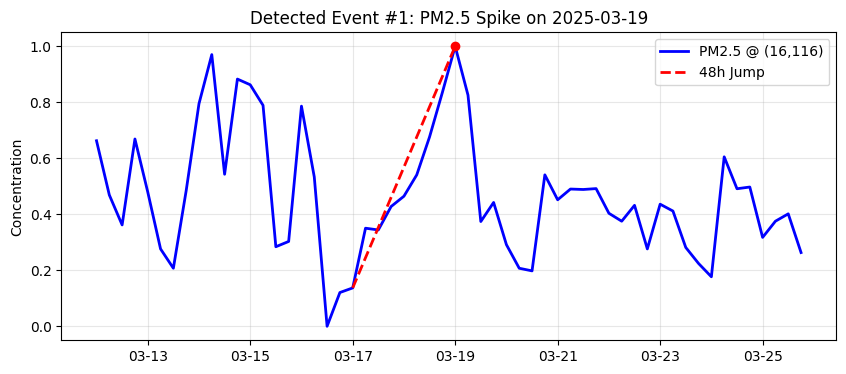

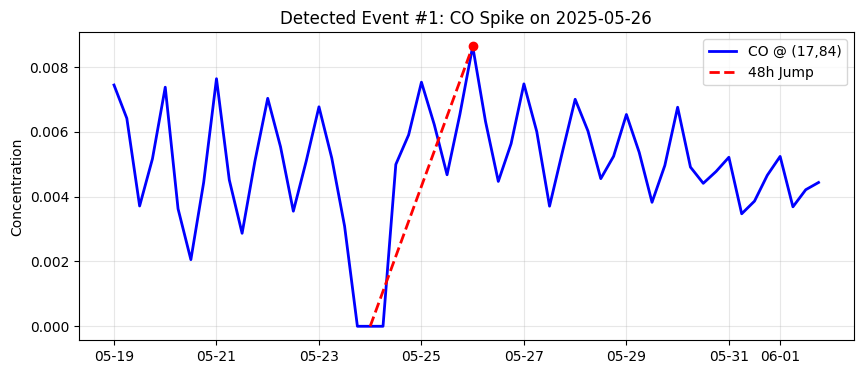

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ==========================
# 1. LOAD DATA
# ==========================
NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    paths = [
        "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz",

    ]
    for p in paths:
        if os.path.exists(p):
            shutil.copy(p, NPZ_LOCAL)
            print(f"Loaded: {p}")
            break

data = np.load(NPZ_LOCAL, allow_pickle=False)
Y_full = data["Y"] # (Time, 6, H, W)
print(f"Data Shape: {Y_full.shape}")

# Time Index
time_index = pd.date_range("2022-01-01 00:00:00", periods=len(Y_full), freq="6h", tz="UTC")

# ==========================
# 2. SCANNING CONFIGURATION
# ==========================
SEARCH_START = "2024-12-21"
SEARCH_END   = "2025-06-30"
JUMP_WINDOW  = 8  # 48 hours / 6h steps = 8 steps
POLLUTANTS   = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# NMS Settings (To ensure we find DISTINCT events)
SUPPRESS_TIME = 12  # +/- 3 days (12 steps)
SUPPRESS_SPACE = 15 # +/- 15 pixels radius

# ==========================
# 3. SCANNING ENGINE
# ==========================
def scan_for_jumps():
    print(f"\n🔎 Scanning for Top 3 Jumps (48hr Delta) from {SEARCH_START} to {SEARCH_END}...")

    # Filter Time Range
    mask = (time_index >= SEARCH_START) & (time_index <= SEARCH_END)
    indices = np.where(mask)[0]

    if len(indices) < JUMP_WINDOW:
        print("❌ Search window too short.")
        return {}

    # Extract Data Slice
    data_roi = Y_full[indices]

    # Calculate 48h Jump: Delta[t] = Value[t] - Value[t-48h]
    # This finds Rapid Intensification
    delta_roi = data_roi[JUMP_WINDOW:] - data_roi[:-JUMP_WINDOW]

    valid_indices = indices[JUMP_WINDOW:] # Aligns with the "End Time" of the jump
    events_found = {}

    for p_idx, pol_name in enumerate(POLLUTANTS):
        # Copy the volume so we can mask it out as we find peaks
        pol_delta = delta_roi[:, p_idx, :, :].copy()
        top_3 = []

        for rank in range(1, 4):
            # Find global max in the 3D volume
            flat_idx = np.argmax(pol_delta)
            t_rel, h, w = np.unravel_index(flat_idx, pol_delta.shape)
            max_val = pol_delta[t_rel, h, w]

            if max_val <= 0.001: break # No more significant jumps

            # Get Absolute Info
            abs_t_idx = valid_indices[t_rel]
            event_time = time_index[abs_t_idx]

            # Store Event
            top_3.append({
                "Rank": rank,
                "Date": event_time,
                "Grid": (h, w),
                "Jump": max_val,
                "Start_Val": Y_full[abs_t_idx - JUMP_WINDOW, p_idx, h, w],
                "End_Val": Y_full[abs_t_idx, p_idx, h, w]
            })

            # NMS: Suppress neighborhood to find DIFFERENT events next time
            t_min = max(0, t_rel - SUPPRESS_TIME)
            t_max = min(pol_delta.shape[0], t_rel + SUPPRESS_TIME)
            h_min = max(0, h - SUPPRESS_SPACE)
            h_max = min(pol_delta.shape[1], h + SUPPRESS_SPACE)
            w_min = max(0, w - SUPPRESS_SPACE)
            w_max = min(pol_delta.shape[2], w + SUPPRESS_SPACE)

            pol_delta[t_min:t_max, h_min:h_max, w_min:w_max] = -999.0

        events_found[pol_name] = top_3

    return events_found

# ==========================
# 4. VISUALIZER
# ==========================
def plot_event_history(event):
    p_idx = POLLUTANTS.index(event['Pollutant'])
    h, w = event['Grid']

    # Find index of event time
    idx = np.where(time_index == event['Date'])[0][0]

    # Plot +/- 7 days around event
    win = 28
    start = max(0, idx - win)
    end = min(len(Y_full), idx + win)

    times = time_index[start:end]
    values = Y_full[start:end, p_idx, h, w]

    plt.figure(figsize=(10, 4))
    plt.plot(times, values, 'b-', linewidth=2, label=f"{event['Pollutant']} @ ({h},{w})")

    # Highlight 48h Jump
    t_start = time_index[idx - JUMP_WINDOW]
    t_end = time_index[idx]
    plt.plot([t_start, t_end], [event['Start_Val'], event['End_Val']], 'r--', linewidth=2, label="48h Jump")
    plt.scatter([t_end], [event['End_Val']], color='red', zorder=5)

    plt.title(f"Detected Event #{event['Rank']}: {event['Pollutant']} Spike on {event['Date'].date()}")
    plt.ylabel("Concentration")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.show()

# ==========================
# 5. RUN IT
# ==========================
results = scan_for_jumps()

print("\n" + "="*80)
print(f"{'POLLUTANT':<10} | {'RANK':<5} | {'DATE':<12} | {'GRID (H,W)':<12} | {'JUMP':<8}")
print("="*80)

for pol in POLLUTANTS:
    for e in results[pol]:
        e['Pollutant'] = pol # Add name for plotter
        print(f"{pol:<10} | #{e['Rank']:<4} | {e['Date'].strftime('%Y-%m-%d')}   | {str(e['Grid']):<12} | {e['Jump']:.4f}")
    print("-" * 80)

# Plot the #1 Event for Critical Pollutants
print("\n>>> Visualizing Top Events...")
if len(results['PM2.5']) > 0: plot_event_history(results['PM2.5'][0])
if len(results['CO']) > 0: plot_event_history(results['CO'][0])

test top 5% or 1% pollution metrics for differnt lead time and compare with baseline

In [ ]:
# ============================================================
# EXTREME-ONLY ROI METRICS (Top 5% / 1% configurable)
# - compares multiple models + persistence baseline
# - reports MSE/RMSE/MAE/MSA(bias) + Skill(MSE) vs persistence
# - for multiple lead times: 6h,24h,72h... or every 6h to 72h
#
# Assumes NPZ contains:
#   X: (T, C_in, H, W)
#   Y: (T, 6,    H, W)    in this order:
#       ["CO","NO2","O3","PM10","PM2.5","SO2"]  (your confirmed order)
#   Mask: (T, 6, H, W)
#
# Works with SimVPHybrid checkpoints (multi-step output).
# ============================================================

import os, shutil, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ---------------------------
# USER SETTINGS (EDIT HERE)
# ---------------------------

# 1) Paths (Drive -> local copy to avoid Drive disconnects)
NPZ_DRIVE = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
NPZ_LOCAL = "/content/local_data.npz"

# 2) Validation time window (targets evaluated in this window)
EVAL_START = "2024-12-21 00:00:00"
EVAL_END   = "2025-06-30 18:00:00"

# 3) Which pollutant to evaluate
POLLUTANT = "PM2.5"   # e.g. "PM2.5", "PM10", "NO2", "O3", "SO2", "CO"

# 4) Lead hours: either explicit list, or every 6h up to 72h
LEAD_HOURS = [6, 24, 72]
# LEAD_HOURS = list(range(6, 73, 6))   # uncomment to do 6,12,...,72

# 5) Extreme selection: "top X%" => quantile = 1 - X
TOP_PCTS = [0.99, 0.01]     # top 5% and top 1%
# TOP_PCTS = [0.10]         # top 10% only
QUANTILES = [1.0 - p for p in TOP_PCTS]  # e.g. [0.95, 0.99]

# 6) ROI by INDEX slices (lat and lon are not in NPZ, so use indices)
# Example from your earlier LA ROI:
ROI_LAT_SLICE = slice(23, 27)   # inclusive start, exclusive end
ROI_LON_SLICE = slice(65, 70)

# 7) Models to compare
# - Each model: name, ckpt_drive_path
# - Optional: input preprocessing to match training (per-model!)
#   Use x_ops: list of ("mul"/"div", channel_index, factor)
# - Optional: output_unscale: dict pollutant_name -> divisor (e.g. {"CO": 50.0})
MODELS = [
    {
        "name": "hybrid_v4_unscaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
        "x_ops": [],              # v4: no special scaling
        "output_unscale": {},     # v4: no output scaling
    },
    {
        "name": "hybrid_v5_scaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        # v5 training did: x[:,5]/=100, x[:,6]/=200, x[:,26]*=50
        "x_ops": [("div", 5, 100.0), ("div", 6, 200.0), ("mul", 26, 50.0)],
        # v5 training scaled CO output by 50 (only CO channel)
        "output_unscale": {"CO": 50.0},
    },
    {
        "name": "V7 (Decoupled)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
        "x_ops": [("div", 5, 100.0), ("div", 6, 200.0), ("mul", 26, 50.0)],              # v4: no special scaling
        "output_unscale": {},     # v4: no output scaling
    },


    {
        "name": "V8 (without CO)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    },

    #{
    #    "name": "V5 (Scaled Baseline)",
    #    "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #    "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    #},
    {
        "name": "V6 (Scaled Baseline)",
        "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
        "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    }

]

# Reduce GPU memory during eval
EVAL_BATCH = 1

# ---------------------------
# Constants / known ordering
# ---------------------------
Y_ORDER_6 = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# If a checkpoint outputs 5 channels and "skips CO", we assume it outputs:
Y_ORDER_5_NOCO = ["NO2", "O3", "PM10", "PM2.5", "SO2"]

# ---------------------------
# Mount Drive + copy NPZ local
# ---------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount("/content/drive")

def copy_to_local(src, dst):
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing: {src}")
    if (not os.path.exists(dst)) or (os.path.getsize(dst) != os.path.getsize(src)):
        print(f"Copying -> {dst}")
        shutil.copy2(src, dst)
        print("  size:", os.path.getsize(dst))
    else:
        print(f"✅ Local already up-to-date: {dst}")

copy_to_local(NPZ_DRIVE, NPZ_LOCAL)

# Load NPZ as memmap (saves RAM)
print("Loading NPZ (mmap_mode='r') ...")
data = np.load(NPZ_LOCAL, mmap_mode="r")
X = data["X"]      # (T, C_in, H, W)
Y = data["Y"]      # (T, 6, H, W)
M = data["Mask"]   # (T, 6, H, W)
T = Y.shape[0]
C_in = X.shape[1]
H, W = X.shape[2], X.shape[3]
print("X:", X.shape, "Y:", Y.shape, "Mask:", M.shape)

# Build time index (6-hour cadence)
time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6h", tz="UTC")
eval_start = pd.Timestamp(EVAL_START, tz="UTC")
eval_end   = pd.Timestamp(EVAL_END, tz="UTC")
is_eval_target = (time_index >= eval_start) & (time_index <= eval_end)

# Convert lead hours -> lead steps
def hours_to_steps(hours):
    if hours % 6 != 0:
        raise ValueError("Lead hours must be multiple of 6.")
    return hours // 6

LEAD_STEPS = [hours_to_steps(h) for h in LEAD_HOURS]
max_lead = max(LEAD_STEPS)

# ROI slices
roi_lat = ROI_LAT_SLICE
roi_lon = ROI_LON_SLICE

# ---------------------------
# Model definition: SimVPHybrid (parametric, ckpt-compatible)
# ---------------------------
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        # keep groups=8 if possible (matches your training style)
        g = 8 if out_c % 8 == 0 else (4 if out_c % 4 == 0 else 2)
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    """
    x_seq: (B, T_in, C_in, H, W)
    out:   (B, T_out, C_out, H, W)
    """
    def __init__(self, in_channels, out_channels, hid_S, hid_T, T_in, T_out):
        super().__init__()
        self.hid_S = hid_S
        self.hid_T = hid_T
        self.T_in = T_in
        self.T_out = T_out
        self.out_channels = out_channels

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
        )

        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1),
        )

    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in * self.hid_S, Hp, Wp)
        feat = self.mid(embed_grouped)
        future_feat = self.time_projector(feat)  # (B, T_out*hid_S, Hp, Wp)

        future_flat = future_feat.view(B * self.T_out, self.hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)       # (B*T_out, C_out, H, W)
        delta_seq = delta_flat.view(B, self.T_out, self.out_channels, H, W)

        # residual anchor: last observed pollution channels in x_seq
        # assumes pollution are last 6 input channels per timestep
        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)  # (B,1,6,H,W)
        # If model outputs fewer than 6, slice last_frame accordingly
        last_frame = last_frame[:, :, :self.out_channels, :, :]
        return last_frame + delta_seq

# ---------------------------
# Checkpoint inference helpers
# ---------------------------
def infer_hybrid_from_state(state):
    # Infer hid_S + in_channels
    key_enc = "enc.0.conv.weight"
    if key_enc not in state:
        raise KeyError(f"Expected key '{key_enc}' not found. This evaluator currently targets SimVPHybrid ckpts.")

    hid_S = state[key_enc].shape[0]
    in_channels = state[key_enc].shape[1]

    # Infer out_channels
    key_out = "dec.2.weight"
    out_channels = state[key_out].shape[0]

    # Infer hid_T and T_in from mid.0 conv
    # mid.0.conv.weight: (hid_T, T_in*hid_S, 1, 1)
    key_mid = "mid.0.conv.weight"
    hid_T = state[key_mid].shape[0]
    mid_in = state[key_mid].shape[1]
    if mid_in % hid_S != 0:
        raise ValueError(f"Cannot infer T_in: mid_in={mid_in} not divisible by hid_S={hid_S}")
    T_in = mid_in // hid_S

    # Infer T_out from time_projector weight: (T_out*hid_S, hid_T, 1, 1)
    key_tp = "time_projector.weight"
    tp_out = state[key_tp].shape[0]
    if tp_out % hid_S != 0:
        raise ValueError(f"Cannot infer T_out: tp_out={tp_out} not divisible by hid_S={hid_S}")
    T_out = tp_out // hid_S

    return dict(in_channels=in_channels, out_channels=out_channels, hid_S=hid_S, hid_T=hid_T, T_in=T_in, T_out=T_out)

def apply_x_ops(x_seq_np, x_ops):
    # x_seq_np: (T_in, C_in, H, W)
    if not x_ops:
        return x_seq_np
    x = x_seq_np.copy()
    for op, ch, factor in x_ops:
        if op == "mul":
            x[:, ch, :, :] *= factor
        elif op == "div":
            x[:, ch, :, :] /= factor
        else:
            raise ValueError(f"Unknown op: {op}")
    return x

# ---------------------------
# Build common evaluation origin indices (shared across models)
# ---------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

import os

def _normalize_models(MODELS):
    # Case 1: user passed a dict: {"model_name": "/path/to.ckpt", ...}
    if isinstance(MODELS, dict):
        out = []
        for name, ckpt_path in MODELS.items():
            out.append({
                "name": str(name),
                "ckpt_drive": str(ckpt_path),
                "x_ops": [],
                "output_unscale": {},
            })
        return out

    # Case 2: user passed a list
    if isinstance(MODELS, list):
        # 2a) list of strings: ["/path/a.pth", "/path/b.pth"]
        if all(isinstance(x, str) for x in MODELS):
            out = []
            for p in MODELS:
                out.append({
                    "name": os.path.splitext(os.path.basename(p))[0],
                    "ckpt_drive": p,
                    "x_ops": [],
                    "output_unscale": {},
                })
            return out

        # 2b) list of dicts (expected)
        if all(isinstance(x, dict) for x in MODELS):
            out = []
            for d in MODELS:
                # accept a few common key variants
                ckpt = d.get("ckpt_drive", d.get("ckpt", d.get("path", None)))
                if ckpt is None:
                    raise ValueError(f"Model dict missing ckpt path. Got keys: {list(d.keys())}")
                out.append({
                    "name": d.get("name", os.path.splitext(os.path.basename(str(ckpt)))[0]),
                    "ckpt_drive": str(ckpt),
                    "x_ops": d.get("x_ops", []),
                    "output_unscale": d.get("output_unscale", {}),
                })
            return out

        raise TypeError("MODELS must be a list of dicts OR a list of strings OR a dict(name->path).")

    # Case 3: single string: "/path/model.pth"
    if isinstance(MODELS, str):
        return [{
            "name": os.path.splitext(os.path.basename(MODELS))[0],
            "ckpt_drive": MODELS,
            "x_ops": [],
            "output_unscale": {},
        }]

    raise TypeError(f"Unsupported MODELS type: {type(MODELS)}")

# --- apply normalization ---
MODELS = _normalize_models(MODELS)

print("✅ Normalized MODELS:")
for m in MODELS:
    print(" -", m["name"], "=>", m["ckpt_drive"])

# Load all checkpoints first to get (T_in, T_out) for common origin selection
model_infos = []
for ms in MODELS:
    ckpt = ms["ckpt_drive"]
    if not os.path.exists(ckpt):
        print(f"⚠️ Missing checkpoint (skipping): {ckpt}")
        continue
    # copy ckpt to local for speed
    ckpt_local = f"/content/{os.path.basename(ckpt)}"
    copy_to_local(ckpt, ckpt_local)

    state = torch.load(ckpt_local, map_location="cpu")
    info = infer_hybrid_from_state(state)
    info.update({
        "name": ms["name"],
        "ckpt_local": ckpt_local,
        "x_ops": ms.get("x_ops", []),
        "output_unscale": ms.get("output_unscale", {}),
        "state": state,
    })
    model_infos.append(info)
    print(f"✅ {ms['name']} inferred:", info)

if len(model_infos) == 0:
    raise RuntimeError("No valid checkpoints found in MODELS list.")

common_T_in = max(mi["T_in"] for mi in model_infos)
common_T_out = min(mi["T_out"] for mi in model_infos)  # common horizon across models
max_lead_needed = max(LEAD_STEPS)

if max_lead_needed > common_T_out:
    raise ValueError(f"Requested max lead step {max_lead_needed} but common model horizon is only {common_T_out} steps.")

# Origins must have enough history and enough future
# origin_idx is the "issue time" (last history frame time index)
origin_min = common_T_in - 1
origin_max = T - 1 - max_lead_needed
origins_all = np.arange(origin_min, origin_max + 1)

# Precompute origins per lead where target time is inside eval window
origins_by_lead = {}
for L in LEAD_STEPS:
    tgt = origins_all + L
    keep = is_eval_target[tgt]
    origins_by_lead[L] = origins_all[keep]
    print(f"Lead {L*6:>3d}h: {len(origins_by_lead[L])} origins")

# ---------------------------
# Pollutant index mapping (truth vs model outputs)
# ---------------------------
if POLLUTANT not in Y_ORDER_6:
    raise ValueError(f"POLLUTANT must be one of {Y_ORDER_6}, got {POLLUTANT}")

gt_ch = Y_ORDER_6.index(POLLUTANT)

def pred_channel_index(out_channels, pollutant_name):
    if out_channels == 6:
        order = Y_ORDER_6
    elif out_channels == 5:
        # assume CO dropped
        order = Y_ORDER_5_NOCO
    else:
        raise ValueError(f"Unsupported out_channels={out_channels}")
    if pollutant_name not in order:
        return None
    return order.index(pollutant_name)

# ---------------------------
# Compute thresholds per lead and quantile (based on TRUE values in ROI)
# ---------------------------
def compute_thresholds():
    thresholds = {}  # (lead_step, quantile) -> value

    for L in LEAD_STEPS:
        origins = origins_by_lead[L]
        if len(origins) == 0:
            for q in QUANTILES:
                thresholds[(L, q)] = np.nan
            continue

        # Gather all valid truth values inside ROI for this lead
        vals = []
        for o in origins:
            t = o + L
            y_roi = np.asarray(Y[t, gt_ch, roi_lat, roi_lon], dtype=np.float32)
            m_roi = np.asarray(M[t, gt_ch, roi_lat, roi_lon], dtype=np.float32)
            v = y_roi[m_roi > 0.5]
            if v.size > 0:
                vals.append(v)

        if len(vals) == 0:
            for q in QUANTILES:
                thresholds[(L, q)] = np.nan
            continue

        vals = np.concatenate(vals, axis=0)
        for q in QUANTILES:
            thresholds[(L, q)] = float(np.quantile(vals, q))

    return thresholds

thresholds = compute_thresholds()

print("\nExtreme thresholds (TRUE values in ROI):")
for L in LEAD_STEPS:
    for q in QUANTILES:
        top_pct = (1.0 - q) * 100.0
        print(f"  lead={L*6:>3d}h  top={top_pct:>5.1f}%  thr={thresholds[(L,q)]:.6f}")

# ---------------------------
# Metric accumulator
# ---------------------------
def new_acc():
    return {"n": 0, "sum_abs": 0.0, "sum_sq": 0.0, "sum_signed": 0.0}

def add_err(acc, err):
    # err: numpy array of selected errors
    if err.size == 0:
        return
    acc["n"] += int(err.size)
    acc["sum_abs"] += float(np.abs(err).sum())
    acc["sum_sq"] += float((err**2).sum())
    acc["sum_signed"] += float(err.sum())

def finalize(acc):
    if acc["n"] == 0:
        return {"MAE": np.nan, "MSE": np.nan, "RMSE": np.nan, "MSA": np.nan, "N": 0}
    mse = acc["sum_sq"] / acc["n"]
    return {
        "MAE": acc["sum_abs"] / acc["n"],
        "MSE": mse,
        "RMSE": math.sqrt(mse),
        "MSA": acc["sum_signed"] / acc["n"],  # mean signed error (bias)
        "N": acc["n"],
    }

# ---------------------------
# Evaluate persistence baseline on extremes
# ---------------------------
def eval_persistence():
    # dict: (lead_step, quantile) -> acc
    base_acc = {(L,q): new_acc() for L in LEAD_STEPS for q in QUANTILES}

    for L in LEAD_STEPS:
        thr_map = {q: thresholds[(L,q)] for q in QUANTILES}
        origins = origins_by_lead[L]

        for o in origins:
            t = o + L
            y_true = np.asarray(Y[t, gt_ch, roi_lat, roi_lon], dtype=np.float32)
            m_true = np.asarray(M[t, gt_ch, roi_lat, roi_lon], dtype=np.float32) > 0.5

            # persistence uses last observed at origin time o
            y_pers = np.asarray(Y[o, gt_ch, roi_lat, roi_lon], dtype=np.float32)

            for q in QUANTILES:
                thr = thr_map[q]
                if not np.isfinite(thr):
                    continue
                sel = m_true & (y_true >= thr)
                if sel.any():
                    err = (y_pers - y_true)[sel]
                    add_err(base_acc[(L,q)], err)

    return base_acc

print("\nEvaluating persistence baseline on extremes...")
base_acc = eval_persistence()

# ---------------------------
# Evaluate a model on extremes (one forward per origin, reuse for all leads)
# ---------------------------
@torch.no_grad()
def eval_model(mi):
    name = mi["name"]
    state = mi["state"]
    in_channels = mi["in_channels"]
    out_channels = mi["out_channels"]
    hid_S = mi["hid_S"]
    hid_T = mi["hid_T"]
    T_in = mi["T_in"]
    T_out = mi["T_out"]
    x_ops = mi.get("x_ops", [])
    out_unscale = mi.get("output_unscale", {})  # pollutant -> divisor

    pred_ch = pred_channel_index(out_channels, POLLUTANT)
    if pred_ch is None:
        print(f"⚠️ {name}: model does not output pollutant '{POLLUTANT}' (out_channels={out_channels}). Skipping.")
        return None

    # Build model with ckpt-matching params
    model = SimVPHybrid(in_channels=in_channels, out_channels=out_channels,
                        hid_S=hid_S, hid_T=hid_T, T_in=T_in, T_out=T_out).to(device)
    model.load_state_dict(state, strict=True)
    model.eval()

    # Prepare accumulators per (lead,quantile)
    acc = {(L,q): new_acc() for L in LEAD_STEPS for q in QUANTILES}

    # We'll iterate origins in batches for speed
    origins_all = np.unique(np.concatenate([origins_by_lead[L] for L in LEAD_STEPS]))
    origins_all = origins_all.astype(int)

    # Only origins that are valid for this model's history & horizon
    origins_all = origins_all[(origins_all >= (T_in - 1)) & (origins_all + max_lead_needed < T)]

    for start in range(0, len(origins_all), EVAL_BATCH):
        batch_origins = origins_all[start:start+EVAL_BATCH]
        B = len(batch_origins)

        # Build input batch: (B, T_in, C_in, H, W)
        x_batch = np.empty((B, T_in, C_in, H, W), dtype=np.float32)
        for bi, o in enumerate(batch_origins):
            sidx = o - (T_in - 1)
            x_seq = np.asarray(X[sidx:o+1], dtype=np.float32)  # (T_in, C_in, H, W)
            x_seq = apply_x_ops(x_seq, x_ops)
            x_batch[bi] = x_seq

        x_t = torch.from_numpy(x_batch).to(device)
        pred_seq = model(x_t).detach().cpu().numpy()  # (B, T_out, C_out, H, W)

        # Optional: unscale the model outputs back to NPZ space for fair comparison
        # (only applies if model trained with scaling on that pollutant)
        if POLLUTANT in out_unscale and out_unscale[POLLUTANT] != 0:
            pred_seq[:, :, pred_ch, :, :] = pred_seq[:, :, pred_ch, :, :] / float(out_unscale[POLLUTANT])

        # Accumulate errors for each lead/quantile (only when target in eval window)
        for bi, o in enumerate(batch_origins):
            for L in LEAD_STEPS:
                t = o + L
                if not is_eval_target[t]:
                    continue
                if (L - 1) >= pred_seq.shape[1]:
                    continue

                y_true = np.asarray(Y[t, gt_ch, roi_lat, roi_lon], dtype=np.float32)
                m_true = (np.asarray(M[t, gt_ch, roi_lat, roi_lon], dtype=np.float32) > 0.5)

                y_hat = pred_seq[bi, L-1, pred_ch, roi_lat, roi_lon].astype(np.float32)

                for q in QUANTILES:
                    thr = thresholds[(L,q)]
                    if not np.isfinite(thr):
                        continue
                    sel = m_true & (y_true >= thr)
                    if sel.any():
                        err = (y_hat - y_true)[sel]
                        add_err(acc[(L,q)], err)

    return acc

# ---------------------------
# Run all models
# ---------------------------
results_rows = []

# Baseline rows
for L in LEAD_STEPS:
    for q in QUANTILES:
        met = finalize(base_acc[(L,q)])
        results_rows.append({
            "model": "persistence",
            "lead_hours": L*6,
            "top_pct": (1.0-q)*100.0,
            "pollutant": POLLUTANT,
            **met,
            "Skill_MSE_vs_Persistence": 0.0 if met["N"] > 0 else np.nan
        })

# Model rows
for mi in model_infos:
    print(f"\n=== Evaluating model: {mi['name']} ===")
    acc = eval_model(mi)
    if acc is None:
        continue

    for L in LEAD_STEPS:
        for q in QUANTILES:
            met_m = finalize(acc[(L,q)])
            met_b = finalize(base_acc[(L,q)])

            skill = np.nan
            if np.isfinite(met_m["MSE"]) and np.isfinite(met_b["MSE"]) and met_b["MSE"] > 0:
                skill = 1.0 - (met_m["MSE"] / met_b["MSE"])

            results_rows.append({
                "model": mi["name"],
                "lead_hours": L*6,
                "top_pct": (1.0-q)*100.0,
                "pollutant": POLLUTANT,
                **met_m,
                "Skill_MSE_vs_Persistence": skill
            })

df = pd.DataFrame(results_rows)

# Pretty print
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

print("\n==================== EXTREME-ONLY ROI RESULTS ====================")
print(df.sort_values(["top_pct", "lead_hours", "model"]).to_string(index=False))

# Ranking: higher Skill is better, lower MSE is better
print("\n==================== RANKING (by Skill, then MSE) ====================")
rank_df = df[df["model"] != "persistence"].copy()
rank_df = rank_df.sort_values(["top_pct", "lead_hours", "Skill_MSE_vs_Persistence", "MSE"],
                              ascending=[True, True, False, True])
print(rank_df[["top_pct","lead_hours","model","N","MSE","RMSE","MAE","MSA","Skill_MSE_vs_Persistence"]].to_string(index=False))


Streaming output truncated to the last 5000 lines.
        -0.0171,  0.0021, -0.0176, -0.0319,  0.0041,  0.0289,  0.0018,  0.0167,
        -0.0137,  0.0125,  0.0037,  0.0141,  0.0085, -0.0161,  0.0216, -0.0123,
        -0.0100,  0.0160, -0.0447, -0.0380, -0.0049,  0.0030, -0.0011, -0.0222,
        -0.0302, -0.0128,  0.0089,  0.0130, -0.0048, -0.0376, -0.0212, -0.0420,
        -0.0418, -0.0416, -0.0062, -0.0123, -0.0016,  0.0187, -0.0291,  0.0410,
         0.0398, -0.0153, -0.0259,  0.0080, -0.0322, -0.0214, -0.0265, -0.0273,
        -0.0025,  0.0119, -0.0248, -0.0033, -0.0116, -0.0291, -0.0291, -0.0158,
        -0.0134,  0.0021,  0.0183, -0.0273,  0.0217,  0.0211, -0.0192, -0.0566,
         0.0267, -0.0222,  0.0333, -0.0243, -0.0069,  0.0465,  0.0221, -0.0353,
        -0.0100,  0.0398, -0.0383, -0.0091, -0.0307, -0.0150, -0.0192, -0.0034,
         0.0467,  0.0127,  0.0614, -0.0200,  0.0110, -0.0198, -0.0275, -0.0008,
         0.0327, -0.0247, -0.0381, -0.0186, -0.0081, -0.0514, -0.0115

GPT version for stressed test on top 5%

In [ ]:
# ============================================================
# ROI + Horizon Evaluator (Model vs Persistence + Skill MSE)
# - ROI: lat in [33,35], lon in [-119.5,-116.5]
# - Horizons: 6h, 24h, 72h  => steps 1,4,12 (6h cadence)
# - Metrics per pollutant: MAE, MSE, RMSE, R^2
# - Baseline: Persistence y(t+h)=y(t)
# - Skill_MSE = 1 - MSE_model / MSE_persistence
# - "Stressed" subset: top_p% times by ROI spatial-max of TRUE per pollutant & horizon
# ============================================================

import os, shutil
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# USER SETTINGS
# ----------------------------
NPZ_DRIVE = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"

# Put your checkpoints here (you can evaluate multiple models)
# For each model you can optionally specify:
#   - x_scale: dict {x_channel_index: multiply_factor} applied to X before model
#   - pred_unscale: dict {pred_channel_index: multiply_factor} applied to model outputs
# Notes:
#   * If a model outputs 5 channels, we assume it skipped CO and outputs [NO2,O3,PM10,PM2.5,SO2]
MODELS = [
    # Example (EDIT THESE PATHS):
    # {"name": "hybrid_v4_unscaledCO", "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth"},
    # {"name": "hybrid_v5_scaledCO",   "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #  "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},     # TP/=100, TCRW/=200, CO*=50
    #  "pred_unscale": {0: 1/50.0}},                 # unscale predicted CO back
    {
        "name": "v4_unscaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth"},

    {
        "name": "v5_scaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},
        "pred_unscale": {0: 1/50.0}},
    {
        "name": "V7 (Decoupled)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
    },


    {
        "name": "V8 (without CO)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth",
    },

    #{
    #    "name": "V5 (Scaled Baseline)",
    #    "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #    "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    #},
    {
        "name": "V6 (Scaled Baseline)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
        "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},
        "pred_unscale": {0: 1/50.0},
    }
]

# ROI lat/lon bounds
ROI_LAT = (33.0, 35.0)
ROI_LON = (-119.5, -116.5)

# Validation window (your known split)
VAL_START = "2024-12-21 00:00:00"
VAL_END   = "2025-06-30 18:00:00"

# Horizons in hours
HORIZON_HOURS = [6, 24, 72]   # => steps [1,4,12]

# Stress definition: top p% times by ROI spatial-max of TRUE (per pollutant & horizon)
TOP_PCT = 0.05  # change to 0.01 for top 1%

# Runtime settings
BATCH_SIZE = 4
NUM_WORKERS = 0  # set 2 if it works stably for you
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Pollutant channel order in Y (you confirmed this earlier)
POLLUTANTS = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

print("Device:", DEVICE)

# ----------------------------
# Mount Drive + copy NPZ locally (avoid Drive disconnect)
# ----------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    print("Copying NPZ -> local:", NPZ_LOCAL)
    shutil.copy2(NPZ_DRIVE, NPZ_LOCAL)
print("Local NPZ size:", os.path.getsize(NPZ_LOCAL))

# ----------------------------
# Load NPZ
# ----------------------------
data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full = data["X"]     # (T, Cx, H, W)
Y_full = data["Y"]     # (T, Cy, H, W)  Cy=6
M_full = data["Mask"]  # (T, Cy, H, W)

T, Cx, H, W = X_full.shape
Cy = Y_full.shape[1]
assert Cy == 6, f"Expected Y to have 6 channels, got {Cy}"
print("X:", X_full.shape, "Y:", Y_full.shape, "Mask:", M_full.shape)

# ----------------------------
# Build time index (6-hour cadence)
# ----------------------------
time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6h", tz="UTC")
val_start = pd.Timestamp(VAL_START, tz="UTC")
val_end   = pd.Timestamp(VAL_END, tz="UTC")
val_start_idx = int(np.where(time_index == val_start)[0][0])
val_end_idx   = int(np.where(time_index == val_end)[0][0])
print(f"VAL window idx: {val_start_idx} → {val_end_idx}  ({time_index[val_start_idx]} → {time_index[val_end_idx]})")

# ----------------------------
# Lat/Lon grid (try from NPZ, else fallback to regular 0.25°)
# ----------------------------
lat = data["lat"] if "lat" in data.files else (28.0 + 0.25*np.arange(H))
lon = data["lon"] if "lon" in data.files else (-135.0 + 0.25*np.arange(W))

lat = np.array(lat)
lon = np.array(lon)

# ROI indices (assumes lat/lon ascending)
lat_mask = (lat >= ROI_LAT[0]) & (lat <= ROI_LAT[1])
lon_mask = (lon >= ROI_LON[0]) & (lon <= ROI_LON[1])

lat_idx = np.where(lat_mask)[0]
lon_idx = np.where(lon_mask)[0]

assert len(lat_idx) > 0 and len(lon_idx) > 0, "ROI selection returned empty indices. Check ROI bounds vs grid."
lat0, lat1 = int(lat_idx[0]), int(lat_idx[-1] + 1)
lon0, lon1 = int(lon_idx[0]), int(lon_idx[-1] + 1)

print("ROI lat idx:", lat0, "→", lat1-1, "lat:", float(lat[lat0]), "→", float(lat[lat1-1]))
print("ROI lon idx:", lon0, "→", lon1-1, "lon:", float(lon[lon0]), "→", float(lon[lon1-1]))
print("ROI shape:", (lat1-lat0), "x", (lon1-lon0))

# ----------------------------
# Horizon steps
# ----------------------------
H_STEPS = [h//6 for h in HORIZON_HOURS]  # 6->1, 24->4, 72->12
assert all(h % 6 == 0 for h in HORIZON_HOURS)
max_step = max(H_STEPS)

# ============================================================
# Dataset: returns origin index + x_seq
# We build a "global origin list" that covers all horizons, then
# we filter per horizon by valid_time ∈ [VAL_START, VAL_END].
# ============================================================
class OriginDataset(Dataset):
    def __init__(self, X, origin_indices, T_in):
        self.X = X
        self.origin = np.array(origin_indices, dtype=np.int64)
        self.T_in = int(T_in)

    def __len__(self):
        return len(self.origin)

    def __getitem__(self, idx):
        t_origin = int(self.origin[idx])
        i_start = t_origin - (self.T_in - 1)           # history start index
        x_seq = self.X[i_start : i_start + self.T_in]  # (T_in, Cx, H, W)
        return torch.from_numpy(x_seq).float(), t_origin, idx  # idx is "position id" for stress masks

# ============================================================
# Model definition for SimVPHybrid (same structure you trained)
# (We infer dimensions from checkpoint, so it loads robustly.)
# ============================================================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T, T_in, T_out):
        super().__init__()
        self.hid_S = hid_S
        self.hid_T = hid_T
        self.T_in  = T_in
        self.T_out = T_out

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
        )

        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1),
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, Cx, H, W)
        B, T_in, Cx_, H_, W_ = x_seq.shape
        x_flat = x_seq.view(B * T_in, Cx_, H_, W_)
        embed = self.enc(x_flat)
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in * self.hid_S, Hp, Wp)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)                 # (B, T_out*hid_S, Hp, Wp)

        future_flat = future_features.view(B * self.T_out, self.hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)                              # (B*T_out, C_out, H, W)
        delta_seq = delta_flat.view(B, self.T_out, -1, H_, W_)          # (B, T_out, C_out, H, W)

        # Residual anchor uses last 6 channels of inputs (pollution)
        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)               # (B,1,6,H,W)
        # If model outputs !=6 channels (e.g., 5), we still add residual,
        # but must match channel count: we will slice last_frame later during eval.
        return last_frame, delta_seq  # return both so evaluator can align channels safely

def infer_hybrid_dims(state):
    # enc.0.conv.weight: (hid_S, in_channels, 3,3)
    hid_S, in_channels = state["enc.0.conv.weight"].shape[0], state["enc.0.conv.weight"].shape[1]
    hid_T = state["mid.0.conv.weight"].shape[0]
    mid_in = state["mid.0.conv.weight"].shape[1]
    T_in = mid_in // hid_S
    T_out = state["time_projector.weight"].shape[0] // hid_S
    out_channels = state["dec.2.weight"].shape[0]
    return int(in_channels), int(out_channels), int(hid_S), int(hid_T), int(T_in), int(T_out)

# ============================================================
# Helpers: scaling, mapping predicted channels -> Y channels
# ============================================================
def apply_x_scale(x_seq, x_scale):
    # x_seq: (B,T,C,H,W)
    if not x_scale:
        return x_seq
    for ch, factor in x_scale.items():
        x_seq[:, :, ch, :, :] = x_seq[:, :, ch, :, :] * float(factor)
    return x_seq

def apply_pred_unscale(pred, pred_unscale):
    # pred: (B,T,C_out,H,W)
    if not pred_unscale:
        return pred
    for ch, factor in pred_unscale.items():
        pred[:, :, ch, :, :] = pred[:, :, ch, :, :] * float(factor)
    return pred

def default_pred_to_y_map(c_out):
    # if 6 outputs: assume [CO,NO2,O3,PM10,PM2.5,SO2]
    if c_out == 6:
        return [0,1,2,3,4,5]
    # if 5 outputs: assume CO skipped => [NO2,O3,PM10,PM2.5,SO2]
    if c_out == 5:
        return [1,2,3,4,5]
    # otherwise: you must specify manually
    raise ValueError(f"Unsupported output channels: {c_out}. Provide custom mapping.")

# ============================================================
# Build origin list (covers all horizons in VAL window)
# ============================================================
def build_origin_indices(T_in):
    # origins must allow history and cover valid times for at least one horizon
    # We'll create a wide origin range and later filter per horizon by valid_time in val window.
    origin_min = val_start_idx - max_step
    origin_max = val_end_idx - 1

    origin_min = max(origin_min, T_in - 1)   # ensure history start >=0
    origin_max = min(origin_max, T - 1)      # ensure origin within array

    origins = np.arange(origin_min, origin_max + 1, dtype=np.int64)
    print(f"Origin range: idx {origins[0]}→{origins[-1]} ({time_index[origins[0]]}→{time_index[origins[-1]]}), N={len(origins)}")
    return origins

# ============================================================
# Stress masks (top-pct times by ROI spatial-max of TRUE)
# per horizon-step and per pollutant (Y index)
# ============================================================
def build_stress_masks(origins, T_in, steps_list, top_pct):
    # masks: dict step -> bool array shape (6, N_origins)
    stress = {}
    N = len(origins)

    for step in steps_list:
        valid_t = origins + step

        # only consider valid times inside val window
        in_val = (valid_t >= val_start_idx) & (valid_t <= val_end_idx)
        stress_step = np.zeros((6, N), dtype=bool)

        for ych in range(6):
            scores = np.full(N, np.nan, dtype=np.float64)

            vt = valid_t[in_val]
            # ROI truth and mask
            y_roi = Y_full[vt, ych, lat0:lat1, lon0:lon1]
            m_roi = M_full[vt, ych, lat0:lat1, lon0:lon1]
            y_roi = np.where(m_roi > 0.5, y_roi, np.nan)

            # spatial max per time
            s = np.nanmax(y_roi.reshape(y_roi.shape[0], -1), axis=1)
            scores[in_val] = s

            # threshold from non-nan scores
            good = np.isfinite(scores)
            if good.sum() < 10:
                continue  # not enough data
            thr = np.nanquantile(scores[good], 1.0 - top_pct)
            stress_step[ych, :] = (scores >= thr)

        stress[step] = stress_step

    return stress

# ============================================================
# Metric accumulator + finalize
# ============================================================
def new_acc():
    # shape: (6,) for Y channels
    z = lambda: np.zeros(6, dtype=np.float64)
    return {
        "sum_m": z(),
        "sum_y": z(),
        "sum_y2": z(),
        "sum_abs_model": z(),
        "sum_sq_model": z(),
        "sum_abs_pers": z(),
        "sum_sq_pers": z(),
    }

def finalize_metrics(acc):
    eps = 1e-12
    out = {}
    sum_m = acc["sum_m"]
    sum_y = acc["sum_y"]
    sum_y2 = acc["sum_y2"]

    y_mean = sum_y / (sum_m + eps)
    ss_tot = sum_y2 - 2.0*y_mean*sum_y + (y_mean**2)*sum_m

    mse_model = acc["sum_sq_model"] / (sum_m + eps)
    mse_pers  = acc["sum_sq_pers"]  / (sum_m + eps)
    mae_model = acc["sum_abs_model"] / (sum_m + eps)
    mae_pers  = acc["sum_abs_pers"]  / (sum_m + eps)
    rmse_model = np.sqrt(mse_model)
    rmse_pers  = np.sqrt(mse_pers)

    r2_model = 1.0 - (acc["sum_sq_model"] / (ss_tot + eps))
    r2_pers  = 1.0 - (acc["sum_sq_pers"]  / (ss_tot + eps))

    skill_mse = 1.0 - (mse_model / (mse_pers + eps))

    out["mse_model"] = mse_model
    out["rmse_model"] = rmse_model
    out["mae_model"] = mae_model
    out["r2_model"] = r2_model

    out["mse_pers"] = mse_pers
    out["rmse_pers"] = rmse_pers
    out["mae_pers"] = mae_pers
    out["r2_pers"] = r2_pers

    out["skill_mse"] = skill_mse
    out["count_mask"] = sum_m

    return out

# ============================================================
# Main evaluation for one model
# ============================================================
@torch.no_grad()
def evaluate_one_model(model_info):
    ckpt_drive = model_info["ckpt_drive"]
    name = model_info.get("name", os.path.basename(ckpt_drive))
    x_scale = model_info.get("x_scale", {})
    pred_unscale = model_info.get("pred_unscale", {})
    pred_to_y = model_info.get("pred_to_y", None)

    if not os.path.exists(ckpt_drive):
        print(f"⚠️ Missing checkpoint: {ckpt_drive} (skip)")
        return None

    # copy ckpt locally
    ckpt_local = "/content/local_model.pth"
    shutil.copy2(ckpt_drive, ckpt_local)

    state = torch.load(ckpt_local, map_location="cpu")
    in_ch, out_ch, hid_S, hid_T, T_in, T_out = infer_hybrid_dims(state)

    print(f"\n=== {name} ===")
    print(f"Infer: in_ch={in_ch} out_ch={out_ch} hid_S={hid_S} hid_T={hid_T} T_in={T_in} T_out={T_out}")

    if pred_to_y is None:
        pred_to_y = default_pred_to_y_map(out_ch)

    # Build origin list and dataloader
    origins = build_origin_indices(T_in)
    ds = OriginDataset(X_full, origins, T_in)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Stress masks per horizon step & pollutant (Y index)
    stress_masks = build_stress_masks(origins, T_in, H_STEPS, TOP_PCT)

    # Build model and load
    model = SimVPHybrid(in_channels=in_ch, out_channels=out_ch, hid_S=hid_S, hid_T=hid_T, T_in=T_in, T_out=T_out).to(DEVICE)
    model.load_state_dict(state, strict=True)
    model.eval()

    # Prepare accumulators:
    # For each horizon step we store:
    #   acc_all[step] for full val window
    #   acc_stress[step] for stressed subset
    acc_all = {step: new_acc() for step in H_STEPS}
    acc_str = {step: new_acc() for step in H_STEPS}

    # Loop batches
    for x_seq, t_origin, pos in dl:
        # x_seq: (B,T,C,H,W)
        x_seq = x_seq.to(DEVICE, non_blocking=True)
        t_origin = t_origin.numpy().astype(np.int64)
        pos = pos.numpy().astype(np.int64)

        # Apply model-specific X scaling (if any)
        x_seq = apply_x_scale(x_seq, x_scale)

        # Forward
        last_frame6, delta_seq = model(x_seq)  # last_frame6: (B,1,6,H,W), delta_seq: (B,T_out,out_ch,H,W)

        # Construct pred as residual:
        # If out_ch==6 -> add last_frame6 directly
        # If out_ch==5 -> we slice last_frame6 to match [NO2,O3,PM10,PM2.5,SO2] => indices [1..5]
        if out_ch == 6:
            pred_seq = last_frame6 + delta_seq
        elif out_ch == 5:
            base = last_frame6[:, :, 1:, :, :]  # drop CO
            pred_seq = base + delta_seq
        else:
            raise ValueError("Only supports out_ch 5 or 6 in this evaluator.")

        # Unscale predictions if needed (e.g., CO back by /50)
        pred_seq = apply_pred_unscale(pred_seq, pred_unscale)

        # For each requested horizon:
        for hours, step in zip(HORIZON_HOURS, H_STEPS):
            step_idx = step - 1  # step=1 -> idx0, step=4 -> idx3, step=12 -> idx11
            if step_idx < 0 or step_idx >= pred_seq.shape[1]:
                # model doesn't provide this horizon
                continue

            valid_t = t_origin + step
            in_val = (valid_t >= val_start_idx) & (valid_t <= val_end_idx)
            if not np.any(in_val):
                continue

            sel = np.where(in_val)[0]
            vt = valid_t[sel]
            ot = t_origin[sel]
            ps = pos[sel]

            # pred ROI: (Bsel, out_ch, Hroi, Wroi)
            pred_roi = pred_seq[sel, step_idx, :, lat0:lat1, lon0:lon1]

            # truth ROI + mask ROI in Y-index space
            # We'll gather only the Y channels that this model predicts
            y_idx_map = pred_to_y  # length out_ch
            y_true = torch.from_numpy(Y_full[vt][:, y_idx_map, lat0:lat1, lon0:lon1]).to(DEVICE)
            m_true = torch.from_numpy(M_full[vt][:, y_idx_map, lat0:lat1, lon0:lon1]).to(DEVICE)

            # persistence baseline: y(t_origin)
            y_pers = torch.from_numpy(Y_full[ot][:, y_idx_map, lat0:lat1, lon0:lon1]).to(DEVICE)

            # effective mask
            m = m_true

            # errors
            diff_m = pred_roi - y_true
            diff_p = y_pers - y_true

            abs_m = diff_m.abs() * m
            sq_m  = (diff_m**2) * m
            abs_p = diff_p.abs() * m
            sq_p  = (diff_p**2) * m

            # Also accumulate y and y^2 for R2 (in Y channel space)
            y_masked = y_true * m
            y2_masked = (y_true**2) * m
            m_sum = m.sum(dim=(0,2,3)).detach().cpu().numpy()
            y_sum = y_masked.sum(dim=(0,2,3)).detach().cpu().numpy()
            y2_sum = y2_masked.sum(dim=(0,2,3)).detach().cpu().numpy()

            # Write into full 6-channel accumulator:
            # (model channels map to y channels)
            for j_pred, j_y in enumerate(y_idx_map):
                acc_all[step]["sum_m"][j_y] += m_sum[j_pred]
                acc_all[step]["sum_y"][j_y] += y_sum[j_pred]
                acc_all[step]["sum_y2"][j_y] += y2_sum[j_pred]
                acc_all[step]["sum_abs_model"][j_y] += abs_m[:, j_pred].sum().item()
                acc_all[step]["sum_sq_model"][j_y]  += sq_m[:, j_pred].sum().item()
                acc_all[step]["sum_abs_pers"][j_y]  += abs_p[:, j_pred].sum().item()
                acc_all[step]["sum_sq_pers"][j_y]   += sq_p[:, j_pred].sum().item()

            # ---- stressed subset accumulation (top p% times) ----
            # stress_masks[step] is shape (6, N_origins). We index by dataset position "ps"
            stress_step = stress_masks[step]  # (6, N)
            for j_pred, j_y in enumerate(y_idx_map):
                sel_time = stress_step[j_y, ps]  # (Bsel,)
                if not np.any(sel_time):
                    continue
                # apply time selection
                sel_time_t = torch.from_numpy(sel_time.astype(np.float32)).to(DEVICE)  # (Bsel,)
                sel_time_t = sel_time_t[:, None, None]  # (Bsel,1,1)
                m_st = m[:, j_pred] * sel_time_t  # (Bsel,Hroi,Wroi)

                # if no mask, skip
                denom = m_st.sum().item()
                if denom <= 0:
                    continue

                # accumulate y/y^2 with stressed mask
                yj = y_true[:, j_pred]
                acc_str[step]["sum_m"][j_y] += m_st.sum().item()
                acc_str[step]["sum_y"][j_y] += (yj * m_st).sum().item()
                acc_str[step]["sum_y2"][j_y] += ((yj**2) * m_st).sum().item()

                acc_str[step]["sum_abs_model"][j_y] += (diff_m[:, j_pred].abs() * m_st).sum().item()
                acc_str[step]["sum_sq_model"][j_y]  += ((diff_m[:, j_pred]**2) * m_st).sum().item()
                acc_str[step]["sum_abs_pers"][j_y]  += (diff_p[:, j_pred].abs() * m_st).sum().item()
                acc_str[step]["sum_sq_pers"][j_y]   += ((diff_p[:, j_pred]**2) * m_st).sum().item()

    # finalize -> DataFrame
    rows = []
    for hours, step in zip(HORIZON_HOURS, H_STEPS):
        all_m = finalize_metrics(acc_all[step])
        str_m = finalize_metrics(acc_str[step])

        for ych, pol in enumerate(POLLUTANTS):
            rows.append({
                "model": name, "subset": "ALL", "horizon_h": hours, "pollutant": pol,
                "MSE_model": all_m["mse_model"][ych],
                "RMSE_model": all_m["rmse_model"][ych],
                "MAE_model": all_m["mae_model"][ych],
                "R2_model": all_m["r2_model"][ych],
                "MSE_persist": all_m["mse_pers"][ych],
                "RMSE_persist": all_m["rmse_pers"][ych],
                "MAE_persist": all_m["mae_pers"][ych],
                "R2_persist": all_m["r2_pers"][ych],
                "Skill_MSE": all_m["skill_mse"][ych],
                "mask_count": all_m["count_mask"][ych],
            })
            rows.append({
                "model": name, "subset": f"TOP{int(TOP_PCT*100)}%_TIMES", "horizon_h": hours, "pollutant": pol,
                "MSE_model": str_m["mse_model"][ych],
                "RMSE_model": str_m["rmse_model"][ych],
                "MAE_model": str_m["mae_model"][ych],
                "R2_model": str_m["r2_model"][ych],
                "MSE_persist": str_m["mse_pers"][ych],
                "RMSE_persist": str_m["rmse_pers"][ych],
                "MAE_persist": str_m["mae_pers"][ych],
                "R2_persist": str_m["r2_pers"][ych],
                "Skill_MSE": str_m["skill_mse"][ych],
                "mask_count": str_m["count_mask"][ych],
            })

    return pd.DataFrame(rows)

# ============================================================
# Run evaluator for all models
# ============================================================
if len(MODELS) == 0:
    print("\n⚠️ MODELS list is empty.")
    print("Add your checkpoints to MODELS (see examples at the top), then rerun.")
else:
    dfs = []
    for m in MODELS:
        if not isinstance(m, dict):
            raise TypeError("Each item in MODELS must be a dict like {'name':..., 'ckpt_drive':...}.")
        dfm = evaluate_one_model(m)
        if dfm is not None:
            dfs.append(dfm)

    if len(dfs) == 0:
        print("No models evaluated (missing checkpoints?)")
    else:
        df = pd.concat(dfs, ignore_index=True)

        # Pretty display: per subset/horizon/pollutant show Model vs Persistence + Skill
        pd.set_option("display.max_rows", 200)
        pd.set_option("display.max_columns", 30)

        print("\n=== RESULTS (first 60 rows) ===")
        print(df.head(60))

        # Optional: save CSV
        out_csv = "/content/drive/MyDrive/graphcast_project/roi_horizon_eval_results.csv"
        df.to_csv(out_csv, index=False)
        print("\nSaved CSV:", out_csv)


Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local NPZ size: 4011023020
X: (5108, 32, 88, 120) Y: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
VAL window idx: 4340 → 5107  (2024-12-21 00:00:00+00:00 → 2025-06-30 18:00:00+00:00)
ROI lat idx: 20 → 28 lat: 33.0 → 35.0
ROI lon idx: 62 → 74 lon: -119.5 → -116.5
ROI shape: 9 x 13

=== v4_unscaledCO ===
Infer: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=8 T_out=12
Origin range: idx 4328→5106 (2024-12-18 00:00:00+00:00→2025-06-30 12:00:00+00:00), N=779


/tmp/ipython-input-2978648613.py:338: RuntimeWarning: All-NaN slice encountered
  s = np.nanmax(y_roi.reshape(y_roi.shape[0], -1), axis=1)



=== v5_scaledCO ===
Infer: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Origin range: idx 4328→5106 (2024-12-18 00:00:00+00:00→2025-06-30 12:00:00+00:00), N=779

=== V7 (Decoupled) ===
Infer: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Origin range: idx 4328→5106 (2024-12-18 00:00:00+00:00→2025-06-30 12:00:00+00:00), N=779

=== V8 (without CO) ===
Infer: in_ch=32 out_ch=5 hid_S=64 hid_T=256 T_in=12 T_out=12
Origin range: idx 4328→5106 (2024-12-18 00:00:00+00:00→2025-06-30 12:00:00+00:00), N=779

=== V6 (Scaled Baseline) ===
Infer: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Origin range: idx 4328→5106 (2024-12-18 00:00:00+00:00→2025-06-30 12:00:00+00:00), N=779

=== RESULTS (first 60 rows) ===
            model       subset  horizon_h pollutant     MSE_model  RMSE_model  \
0   v4_unscaledCO          ALL          6        CO  1.348293e-06    0.001161   
1   v4_unscaledCO  TOP5%_TIMES          6        CO  3.513978e-06    0.001875   
2   v4_unscaledCO       

GPT validation code as the logic as above but covers entire validation period plus entire California

In [ ]:
# ============================================================
# FULL-GRID + CALIFORNIA Evaluation (ALL + TOP% stressed times)
# For all models, all 6 pollutants, horizons 6/24/72
# Outputs CSV with:
#   - model metrics: MAE/MSE/RMSE/R2
#   - persistence metrics: MAE/MSE/RMSE/R2
#   - Skill_MSE = 1 - MSE_model / MSE_persist
# Regions included:
#   - FULL_GRID (entire forecast area)
#   - CALIFORNIA_BBOX (approx CA bounding box)
# Stress subset:
#   - TOP{p%}_TIMES where stress score = spatial max of TRUE over region (per pollutant, per horizon)
# ============================================================

import os, shutil
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# USER SETTINGS
# ----------------------------
NPZ_DRIVE = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"

# Add your models here (all must be SimVPHybrid checkpoints with same key names)
# Optional:
#   x_scale: {x_channel_index: multiply_factor} applied to X before model
#   pred_unscale: {pred_channel_index: multiply_factor} applied to model predictions after residual is formed
#   pred_to_y: list mapping prediction channels -> Y indices (length = out_ch)
MODELS = [
    # مثال:
    # {"name": "hybrid_v4_unscaledCO",
    #  "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth"},
    #
    # {"name": "hybrid_v5_scaledCO",
    #  "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #  "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},       # TP/=100, TCRW/=200, CO*=50
    #  "pred_unscale": {0: 1/50.0}},                   # unscale predicted CO back
    {
        "name": "v4_unscaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth"},

    {
        "name": "v5_scaledCO",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
        "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},
        "pred_unscale": {0: 1/50.0}},
    {
        "name": "V7 (Decoupled)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth",
    },


    {
        "name": "V8 (without CO)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth",
    },

    #{
    #    "name": "V5 (Scaled Baseline)",
    #    "path": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth",
    #    "inputs_scaled": True, "outputs_scaled": True, "has_co": True
    #},
    {
        "name": "V6 (Scaled Baseline)",
        "ckpt_drive": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth",
        "x_scale": {5: 0.01, 6: 0.005, 26: 50.0},
        "pred_unscale": {0: 1/50.0},
    }
]

# Validation window (your known split)
VAL_START = "2024-12-21 00:00:00"
VAL_END   = "2025-06-30 18:00:00"

# Horizons in hours (6-hour cadence)
HORIZON_HOURS = [6, 24, 72]   # -> steps [1,4,12]
TOP_PCT = 0.05                # stressed-times fraction, set 0.01 for top 1%

# Regions:
# FULL_GRID = whole forecast grid
# CALIFORNIA_BBOX = approximate CA bounding box; adjust if needed
REGIONS = [
    {"name": "FULL_GRID", "lat": None, "lon": None},
    {"name": "CALIFORNIA_BBOX", "lat": (32.0, 42.0), "lon": (-124.5, -114.0)},
]

# Runtime
BATCH_SIZE = 4
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Pollutants order in Y (you confirmed earlier)
POLLUTANTS = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# Output CSV
OUT_CSV_LOCAL = "/content/validation_fullgrid_california_metrics.csv"
OUT_CSV_DRIVE = "/content/drive/MyDrive/graphcast_project/validation_fullgrid_california_metrics.csv"  # optional

print("Device:", DEVICE)

# ----------------------------
# Mount Drive + copy NPZ locally (avoid Drive disconnect)
# ----------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

NPZ_LOCAL = "/content/local_data.npz"
if not os.path.exists(NPZ_LOCAL):
    print("Copying NPZ -> local:", NPZ_LOCAL)
    shutil.copy2(NPZ_DRIVE, NPZ_LOCAL)
print("Local NPZ size:", os.path.getsize(NPZ_LOCAL))

# ----------------------------
# Load NPZ
# ----------------------------
data = np.load(NPZ_LOCAL, allow_pickle=False)
X_full = data["X"]     # (T, Cx, H, W)
Y_full = data["Y"]     # (T, 6, H, W)
M_full = data["Mask"]  # (T, 6, H, W)

T, Cx, H, W = X_full.shape
assert Y_full.shape[1] == 6, "Expected Y to have 6 channels."
print("X:", X_full.shape, "Y:", Y_full.shape, "Mask:", M_full.shape)

# ----------------------------
# Build time index (6-hour cadence)
# ----------------------------
time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6h", tz="UTC")
val_start = pd.Timestamp(VAL_START, tz="UTC")
val_end   = pd.Timestamp(VAL_END, tz="UTC")

val_start_idx = int(np.where(time_index == val_start)[0][0])
val_end_idx   = int(np.where(time_index == val_end)[0][0])
print(f"VAL window idx: {val_start_idx} → {val_end_idx}  ({time_index[val_start_idx]} → {time_index[val_end_idx]})")

# ----------------------------
# Lat/Lon grid (try from NPZ, else fallback to your common grid)
# ----------------------------
lat = np.array(data["lat"]) if "lat" in data.files else (28.0 + 0.25*np.arange(H))
lon = np.array(data["lon"]) if "lon" in data.files else (-135.0 + 0.25*np.arange(W))

# ----------------------------
# Helper: slice indices from bounds (supports ascending/descending coords)
# ----------------------------
def bounds_to_slice(coord, lo, hi):
    coord = np.asarray(coord)
    if coord[0] <= coord[-1]:
        m = (coord >= lo) & (coord <= hi)
        idx = np.where(m)[0]
    else:
        m = (coord <= hi) & (coord >= lo)
        idx = np.where(m)[0]
    if len(idx) == 0:
        return None
    return int(idx[0]), int(idx[-1] + 1)

# Build region slices
REGION_SLICES = []
for r in REGIONS:
    if r["lat"] is None or r["lon"] is None:
        REGION_SLICES.append({"name": r["name"], "lat0": 0, "lat1": H, "lon0": 0, "lon1": W})
    else:
        sl_lat = bounds_to_slice(lat, r["lat"][0], r["lat"][1])
        sl_lon = bounds_to_slice(lon, r["lon"][0], r["lon"][1])
        assert sl_lat is not None and sl_lon is not None, f"Region {r['name']} out of bounds."
        lat0, lat1 = sl_lat
        lon0, lon1 = sl_lon
        REGION_SLICES.append({"name": r["name"], "lat0": lat0, "lat1": lat1, "lon0": lon0, "lon1": lon1})

print("\nRegions used:")
for rs in REGION_SLICES:
    print(f"  {rs['name']:>14s} lat[{rs['lat0']}:{rs['lat1']}] lon[{rs['lon0']}:{rs['lon1']}] "
          f"shape={(rs['lat1']-rs['lat0'])}x{(rs['lon1']-rs['lon0'])}")

# ----------------------------
# Horizons
# ----------------------------
assert all(h % 6 == 0 for h in HORIZON_HOURS)
H_STEPS = [h // 6 for h in HORIZON_HOURS]   # [1,4,12]
MAX_STEP = max(H_STEPS)

# ============================================================
# Dataset: returns x_seq + origin index + dataset position id
# ============================================================
class OriginDataset(Dataset):
    def __init__(self, X, origin_indices, T_in):
        self.X = X
        self.origin = np.array(origin_indices, dtype=np.int64)
        self.T_in = int(T_in)

    def __len__(self):
        return len(self.origin)

    def __getitem__(self, idx):
        t_origin = int(self.origin[idx])
        i0 = t_origin - (self.T_in - 1)
        x_seq = self.X[i0 : i0 + self.T_in]   # (T_in, Cx, H, W)
        return torch.from_numpy(x_seq).float(), t_origin, idx

# ============================================================
# Model definition (SimVPHybrid) + infer dims
# ============================================================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T, T_in, T_out):
        super().__init__()
        self.hid_S = int(hid_S)
        self.hid_T = int(hid_T)
        self.T_in  = int(T_in)
        self.T_out = int(T_out)

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, self.hid_S, 3, 1, 1),
            BasicConv2d(self.hid_S, self.hid_S, 3, 2, 1),
            BasicConv2d(self.hid_S, self.hid_S, 3, 2, 1),
        )

        mid_in = self.T_in * self.hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in, self.hid_T, 1, 1, 0),
            Inception(self.hid_T, self.hid_T),
            Inception(self.hid_T, self.hid_T),
            Inception(self.hid_T, self.hid_T),
            Inception(self.hid_T, self.hid_T),
        )

        self.time_projector = nn.Conv2d(self.hid_T, self.T_out * self.hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(self.hid_S, self.hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(self.hid_S, self.hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(self.hid_S, out_channels, 3, 1, 1),
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, Cx, H, W)
        B, T_in, Cx_, H_, W_ = x_seq.shape
        x_flat = x_seq.view(B * T_in, Cx_, H_, W_)
        embed = self.enc(x_flat)                       # (B*T_in, hid_S, Hp, Wp)
        _, _, Hp, Wp = embed.shape

        embed_grouped = embed.view(B, T_in * self.hid_S, Hp, Wp)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)                # (B, T_out*hid_S, Hp, Wp)

        future_flat = future_features.view(B * self.T_out, self.hid_S, Hp, Wp)
        delta_flat = self.dec(future_flat)                             # (B*T_out, out_ch, H, W)
        delta_seq = delta_flat.view(B, self.T_out, -1, H_, W_)

        # Always produce 6-channel last frame (pollution) from X
        last_frame6 = x_seq[:, -1, -6:, :, :].unsqueeze(1)             # (B,1,6,H,W)
        return last_frame6, delta_seq

def infer_hybrid_dims(state):
    hid_S = state["enc.0.conv.weight"].shape[0]
    in_ch = state["enc.0.conv.weight"].shape[1]
    hid_T = state["mid.0.conv.weight"].shape[0]
    mid_in = state["mid.0.conv.weight"].shape[1]
    T_in = mid_in // hid_S
    T_out = state["time_projector.weight"].shape[0] // hid_S
    out_ch = state["dec.2.weight"].shape[0]
    return int(in_ch), int(out_ch), int(hid_S), int(hid_T), int(T_in), int(T_out)

def default_pred_to_y_map(out_ch):
    # 6 outputs => [CO,NO2,O3,PM10,PM2.5,SO2]
    if out_ch == 6:
        return [0,1,2,3,4,5]
    # 5 outputs => assume CO skipped => [NO2,O3,PM10,PM2.5,SO2]
    if out_ch == 5:
        return [1,2,3,4,5]
    raise ValueError(f"Unsupported out_ch={out_ch}. Provide model_info['pred_to_y'].")

def apply_x_scale(x_seq, x_scale):
    # x_seq: (B,T,C,H,W)
    if not x_scale:
        return x_seq
    for ch, factor in x_scale.items():
        x_seq[:, :, int(ch), :, :] = x_seq[:, :, int(ch), :, :] * float(factor)
    return x_seq

def apply_pred_unscale(pred_seq, pred_unscale):
    # pred_seq: (B,T,out_ch,H,W)
    if not pred_unscale:
        return pred_seq
    for ch, factor in pred_unscale.items():
        pred_seq[:, :, int(ch), :, :] = pred_seq[:, :, int(ch), :, :] * float(factor)
    return pred_seq

# ============================================================
# Origin indices for a given T_in (History)
# ============================================================
def build_origins(T_in):
    # origin must allow history and leave room for horizon step
    origin_min = max((T_in - 1), (val_start_idx - MAX_STEP))
    origin_max = min((T - 1), (val_end_idx - 1))
    origins = np.arange(origin_min, origin_max + 1, dtype=np.int64)
    print(f"Origins: idx {origins[0]}→{origins[-1]}  N={len(origins)}")
    return origins

# ============================================================
# Stress masks per region, step, pollutant:
# stress score = spatial max of TRUE over region at valid time
# returns dict: stress[region_name][step] -> bool array (6, N_origins)
# ============================================================
def build_stress_masks(origins, region_slices, top_pct):
    stress = {rs["name"]: {} for rs in region_slices}
    N = len(origins)

    for rs in region_slices:
        rname = rs["name"]
        lat0, lat1, lon0, lon1 = rs["lat0"], rs["lat1"], rs["lon0"], rs["lon1"]

        for step in H_STEPS:
            valid_t = origins + step
            in_val = (valid_t >= val_start_idx) & (valid_t <= val_end_idx)
            stress_step = np.zeros((6, N), dtype=bool)

            for ych in range(6):
                scores = np.full(N, np.nan, dtype=np.float64)
                vt = valid_t[in_val]

                y = Y_full[vt, ych, lat0:lat1, lon0:lon1]
                m = M_full[vt, ych, lat0:lat1, lon0:lon1]
                y_masked = np.where(m > 0.5, y, np.nan)

                # spatial max per time
                s = np.nanmax(y_masked.reshape(y_masked.shape[0], -1), axis=1)
                scores[in_val] = s

                good = np.isfinite(scores)
                if good.sum() < 10:
                    continue

                thr = np.nanquantile(scores[good], 1.0 - top_pct)
                stress_step[ych, :] = (scores >= thr)

            stress[rname][step] = stress_step

    return stress

# ============================================================
# Metric accumulators
# We accumulate truth sums for all 6 channels (for R^2),
# persistence errors for all 6,
# model errors only for predicted channels (others remain NaN later).
# ============================================================
def new_acc():
    z = lambda: np.zeros(6, dtype=np.float64)
    return {
        "sum_m": z(),
        "sum_y": z(),
        "sum_y2": z(),
        "sum_abs_model": z(),
        "sum_sq_model": z(),
        "sum_abs_pers": z(),
        "sum_sq_pers": z(),
    }

def finalize(acc, predicted_channels_set):
    eps = 1e-12
    sum_m = acc["sum_m"]
    sum_y = acc["sum_y"]
    sum_y2 = acc["sum_y2"]

    y_mean = sum_y / (sum_m + eps)
    ss_tot = sum_y2 - 2.0*y_mean*sum_y + (y_mean**2)*sum_m

    mse_model = acc["sum_sq_model"] / (sum_m + eps)
    mae_model = acc["sum_abs_model"] / (sum_m + eps)
    rmse_model = np.sqrt(mse_model)

    mse_pers = acc["sum_sq_pers"] / (sum_m + eps)
    mae_pers = acc["sum_abs_pers"] / (sum_m + eps)
    rmse_pers = np.sqrt(mse_pers)

    r2_model = 1.0 - (acc["sum_sq_model"] / (ss_tot + eps))
    r2_pers  = 1.0 - (acc["sum_sq_pers"]  / (ss_tot + eps))

    skill_mse = 1.0 - (mse_model / (mse_pers + eps))

    # If a channel is not predicted by the model, mark model metrics as NaN (not fake zeros)
    for ch in range(6):
        if ch not in predicted_channels_set:
            mse_model[ch] = np.nan
            rmse_model[ch] = np.nan
            mae_model[ch] = np.nan
            r2_model[ch] = np.nan
            skill_mse[ch] = np.nan

    return {
        "MSE_model": mse_model, "RMSE_model": rmse_model, "MAE_model": mae_model, "R2_model": r2_model,
        "MSE_persist": mse_pers, "RMSE_persist": rmse_pers, "MAE_persist": mae_pers, "R2_persist": r2_pers,
        "Skill_MSE": skill_mse,
        "mask_count": sum_m,
    }

# ============================================================
# Evaluate one model across all regions
# ============================================================
@torch.no_grad()
def evaluate_model(model_info):
    ckpt_drive = model_info["ckpt_drive"]
    name = model_info.get("name", os.path.basename(ckpt_drive))
    x_scale = model_info.get("x_scale", {})
    pred_unscale = model_info.get("pred_unscale", {})
    pred_to_y = model_info.get("pred_to_y", None)

    if not os.path.exists(ckpt_drive):
        print(f"⚠️ Missing checkpoint: {ckpt_drive} (skip)")
        return None

    ckpt_local = "/content/local_model.pth"
    shutil.copy2(ckpt_drive, ckpt_local)
    state = torch.load(ckpt_local, map_location="cpu")

    in_ch, out_ch, hid_S, hid_T, T_in, T_out = infer_hybrid_dims(state)
    if pred_to_y is None:
        pred_to_y = default_pred_to_y_map(out_ch)

    predicted_y_channels = set(pred_to_y)

    print(f"\n=== {name} ===")
    print(f"Infer dims: in_ch={in_ch} out_ch={out_ch} hid_S={hid_S} hid_T={hid_T} T_in={T_in} T_out={T_out}")
    print("Pred->Y map:", pred_to_y, " (predicted Y channels:", sorted(list(predicted_y_channels)), ")")

    origins = build_origins(T_in)
    ds = OriginDataset(X_full, origins, T_in)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Stress masks for this model's origin list (depends on T_in)
    stress_masks = build_stress_masks(origins, REGION_SLICES, TOP_PCT)

    model = SimVPHybrid(in_channels=in_ch, out_channels=out_ch, hid_S=hid_S, hid_T=hid_T, T_in=T_in, T_out=T_out).to(DEVICE)
    model.load_state_dict(state, strict=True)
    model.eval()

    # Accumulators per (region, step) for ALL and STRESS
    acc_all = {(rs["name"], step): new_acc() for rs in REGION_SLICES for step in H_STEPS}
    acc_str = {(rs["name"], step): new_acc() for rs in REGION_SLICES for step in H_STEPS}

    for x_seq, t_origin, pos in dl:
        # x_seq: (B,T,C,H,W)
        x_seq = x_seq.to(DEVICE, non_blocking=True)
        t_origin = t_origin.numpy().astype(np.int64)
        pos = pos.numpy().astype(np.int64)

        # scale inputs if needed (to match training)
        x_seq = apply_x_scale(x_seq, x_scale)

        last_frame6, delta_seq = model(x_seq)  # last_frame6: (B,1,6,H,W) ; delta_seq: (B,T_out,out_ch,H,W)

        # Build prediction sequence in model-output channel space
        if out_ch == 6:
            pred_seq = last_frame6 + delta_seq
        elif out_ch == 5:
            base = last_frame6[:, :, 1:, :, :]   # drop CO to match [NO2,O3,PM10,PM2.5,SO2]
            pred_seq = base + delta_seq
        else:
            raise ValueError("Evaluator supports out_ch=5 or 6 only.")

        pred_seq = apply_pred_unscale(pred_seq, pred_unscale)

        # Loop horizons
        for hours, step in zip(HORIZON_HOURS, H_STEPS):
            step_idx = step - 1
            if step_idx < 0 or step_idx >= pred_seq.shape[1]:
                continue

            valid_t = t_origin + step
            in_val = (valid_t >= val_start_idx) & (valid_t <= val_end_idx)
            if not np.any(in_val):
                continue

            sel = np.where(in_val)[0]
            vt = valid_t[sel]
            ot = t_origin[sel]
            ps = pos[sel]

            # pred at this horizon (Bsel, out_ch, H, W)
            pred_step = pred_seq[sel, step_idx]  # torch

            # For each region compute metrics
            for rs in REGION_SLICES:
                rname = rs["name"]
                lat0, lat1, lon0, lon1 = rs["lat0"], rs["lat1"], rs["lon0"], rs["lon1"]

                # Truth + mask for ALL 6 channels (so persistence always computed for all 6)
                y_true_all = torch.from_numpy(Y_full[vt, :, lat0:lat1, lon0:lon1]).to(DEVICE)
                m_all = torch.from_numpy(M_full[vt, :, lat0:lat1, lon0:lon1]).to(DEVICE)

                # Persistence baseline uses Y at origin time for same region
                y_pers_all = torch.from_numpy(Y_full[ot, :, lat0:lat1, lon0:lon1]).to(DEVICE)

                # accumulate truth sums (for R2) ONCE (applies to both model and persistence)
                m_sum = m_all.sum(dim=(0,2,3)).detach().cpu().numpy()
                y_sum = (y_true_all * m_all).sum(dim=(0,2,3)).detach().cpu().numpy()
                y2_sum = ((y_true_all**2) * m_all).sum(dim=(0,2,3)).detach().cpu().numpy()

                A = acc_all[(rname, step)]
                A["sum_m"]  += m_sum
                A["sum_y"]  += y_sum
                A["sum_y2"] += y2_sum

                # persistence errors for all 6
                diff_p = (y_pers_all - y_true_all)
                A["sum_abs_pers"] += (diff_p.abs() * m_all).sum(dim=(0,2,3)).detach().cpu().numpy()
                A["sum_sq_pers"]  += ((diff_p**2) * m_all).sum(dim=(0,2,3)).detach().cpu().numpy()

                # model errors only for predicted channels
                # slice pred region
                pred_roi = pred_step[:, :, lat0:lat1, lon0:lon1]
                y_true_pred = y_true_all[:, pred_to_y, :, :]
                m_pred = m_all[:, pred_to_y, :, :]
                diff_m = pred_roi - y_true_pred

                # add into the correct Y channels
                abs_m = (diff_m.abs() * m_pred).sum(dim=(0,2,3)).detach().cpu().numpy()
                sq_m  = ((diff_m**2) * m_pred).sum(dim=(0,2,3)).detach().cpu().numpy()
                for j_pred, j_y in enumerate(pred_to_y):
                    A["sum_abs_model"][j_y] += abs_m[j_pred]
                    A["sum_sq_model"][j_y]  += sq_m[j_pred]

                # ---------------- STRESS subset ----------------
                S = acc_str[(rname, step)]
                stress_step = stress_masks[rname][step]  # (6, N_origins)
                # For each pollutant, apply time-selection to mask
                for ych in range(6):
                    sel_time = stress_step[ych, ps]  # bool (Bsel,)
                    if not np.any(sel_time):
                        continue
                    sel_time_t = torch.from_numpy(sel_time.astype(np.float32)).to(DEVICE)[:, None, None]  # (Bsel,1,1)

                    # stressed mask for that pollutant
                    m_st = m_all[:, ych] * sel_time_t
                    denom = float(m_st.sum().item())
                    if denom <= 0:
                        continue

                    # truth sums for R2 (stressed)
                    ych_true = y_true_all[:, ych]
                    S["sum_m"][ych]  += denom
                    S["sum_y"][ych]  += float((ych_true * m_st).sum().item())
                    S["sum_y2"][ych] += float(((ych_true**2) * m_st).sum().item())

                    # persistence errors (stressed)
                    diffp_ch = (y_pers_all[:, ych] - ych_true)
                    S["sum_abs_pers"][ych] += float((diffp_ch.abs() * m_st).sum().item())
                    S["sum_sq_pers"][ych]  += float(((diffp_ch**2) * m_st).sum().item())

                    # model errors (stressed) only if model predicts that channel
                    if ych in predicted_y_channels:
                        # find its pred index
                        j_pred = pred_to_y.index(ych)
                        diffm_ch = (pred_roi[:, j_pred] - ych_true)
                        S["sum_abs_model"][ych] += float((diffm_ch.abs() * m_st).sum().item())
                        S["sum_sq_model"][ych]  += float(((diffm_ch**2) * m_st).sum().item())

    # Build dataframe rows
    rows = []
    for rs in REGION_SLICES:
        rname = rs["name"]
        for hours, step in zip(HORIZON_HOURS, H_STEPS):
            all_metrics = finalize(acc_all[(rname, step)], predicted_y_channels)
            str_metrics = finalize(acc_str[(rname, step)], predicted_y_channels)

            for ych, pol in enumerate(POLLUTANTS):
                rows.append({
                    "model": name, "region": rname, "subset": "ALL",
                    "horizon_h": hours, "pollutant": pol,
                    "MSE_model": all_metrics["MSE_model"][ych],
                    "RMSE_model": all_metrics["RMSE_model"][ych],
                    "MAE_model": all_metrics["MAE_model"][ych],
                    "R2_model": all_metrics["R2_model"][ych],
                    "MSE_persist": all_metrics["MSE_persist"][ych],
                    "RMSE_persist": all_metrics["RMSE_persist"][ych],
                    "MAE_persist": all_metrics["MAE_persist"][ych],
                    "R2_persist": all_metrics["R2_persist"][ych],
                    "Skill_MSE": all_metrics["Skill_MSE"][ych],
                    "mask_count": all_metrics["mask_count"][ych],
                    "top_pct": np.nan,
                })
                rows.append({
                    "model": name, "region": rname, "subset": f"TOP{int(TOP_PCT*100)}%_TIMES",
                    "horizon_h": hours, "pollutant": pol,
                    "MSE_model": str_metrics["MSE_model"][ych],
                    "RMSE_model": str_metrics["RMSE_model"][ych],
                    "MAE_model": str_metrics["MAE_model"][ych],
                    "R2_model": str_metrics["R2_model"][ych],
                    "MSE_persist": str_metrics["MSE_persist"][ych],
                    "RMSE_persist": str_metrics["RMSE_persist"][ych],
                    "MAE_persist": str_metrics["MAE_persist"][ych],
                    "R2_persist": str_metrics["R2_persist"][ych],
                    "Skill_MSE": str_metrics["Skill_MSE"][ych],
                    "mask_count": str_metrics["mask_count"][ych],
                    "top_pct": TOP_PCT,
                })

    return pd.DataFrame(rows)

# ============================================================
# RUN FOR ALL MODELS + SAVE CSV
# ============================================================
if len(MODELS) == 0:
    print("\n⚠️ MODELS is empty. Add your checkpoints to MODELS at the top and rerun.")
else:
    all_dfs = []
    for m in MODELS:
        if not isinstance(m, dict):
            raise TypeError("Each item in MODELS must be a dict: {'name':..., 'ckpt_drive':...}")
        dfm = evaluate_model(m)
        if dfm is not None:
            all_dfs.append(dfm)

    if len(all_dfs) == 0:
        print("No models evaluated (missing checkpoints?)")
    else:
        df = pd.concat(all_dfs, ignore_index=True)

        # save local
        df.to_csv(OUT_CSV_LOCAL, index=False)
        print("\n✅ Saved CSV (local):", OUT_CSV_LOCAL)

        # save to drive (optional)
        try:
            df.to_csv(OUT_CSV_DRIVE, index=False)
            print("✅ Saved CSV (drive):", OUT_CSV_DRIVE)
        except Exception as e:
            print("⚠️ Could not save to Drive:", e)

        # quick peek
        print("\nPreview:")
        print(df.head(30))


Device: cuda
Mounted at /content/drive
Copying NPZ -> local: /content/local_data.npz
Local NPZ size: 4011023020
X: (5108, 32, 88, 120) Y: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
VAL window idx: 4340 → 5107  (2024-12-21 00:00:00+00:00 → 2025-06-30 18:00:00+00:00)

Regions used:
       FULL_GRID lat[0:88] lon[0:120] shape=88x120
  CALIFORNIA_BBOX lat[16:57] lon[42:85] shape=41x43

=== v4_unscaledCO ===
Infer dims: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=8 T_out=12
Pred->Y map: [0, 1, 2, 3, 4, 5]  (predicted Y channels: [0, 1, 2, 3, 4, 5] )
Origins: idx 4328→5106  N=779


/tmp/ipython-input-396056079.py:352: RuntimeWarning: All-NaN slice encountered
  s = np.nanmax(y_masked.reshape(y_masked.shape[0], -1), axis=1)



=== v5_scaledCO ===
Infer dims: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Pred->Y map: [0, 1, 2, 3, 4, 5]  (predicted Y channels: [0, 1, 2, 3, 4, 5] )
Origins: idx 4328→5106  N=779

=== V7 (Decoupled) ===
Infer dims: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Pred->Y map: [0, 1, 2, 3, 4, 5]  (predicted Y channels: [0, 1, 2, 3, 4, 5] )
Origins: idx 4328→5106  N=779

=== V8 (without CO) ===
Infer dims: in_ch=32 out_ch=5 hid_S=64 hid_T=256 T_in=12 T_out=12
Pred->Y map: [1, 2, 3, 4, 5]  (predicted Y channels: [1, 2, 3, 4, 5] )
Origins: idx 4328→5106  N=779

=== V6 (Scaled Baseline) ===
Infer dims: in_ch=32 out_ch=6 hid_S=64 hid_T=256 T_in=12 T_out=12
Pred->Y map: [0, 1, 2, 3, 4, 5]  (predicted Y channels: [0, 1, 2, 3, 4, 5] )
Origins: idx 4328→5106  N=779

✅ Saved CSV (local): /content/validation_fullgrid_california_metrics.csv
✅ Saved CSV (drive): /content/drive/MyDrive/graphcast_project/validation_fullgrid_california_metrics.csv

Preview:
            model     reg

Gemini validation code

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.path import Path
import os
from tqdm import tqdm

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
# ==========================
# 1. CONFIGURATION
# ==========================
# 🔴 ACTION: Add your 12 models here
MODELS_TO_COMPARE = {
    "Residual SimVP (Best)": "/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth",
    # "Model 2": "/content/drive/MyDrive/graphcast_project/model_v2.pth",
    # "Model 3": "...",
}

DATA_PATH = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'
REF_NC_PATH = '/content/drive/MyDrive/graphcast_project/Training Data/pollution_la_2022_to_2025_avg_gemini.nc'
OUTPUT_CSV = '/content/drive/MyDrive/graphcast_project/final_12model_comparison.csv'

CONFIG = {
    'History': 8,          # 48 hours
    'Max_Horizon_Steps': 12, # 12 * 6h = 72 Hours
    'Eval_Horizons': [1, 4, 12], # Steps to record (6h, 24h, 72h)
    'Batch_Size': 32,
    'Scale_Factor': 7.0,   # Approx max value to convert Log -> Real
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

POLLUTANTS = ['O3', 'SO2', 'CO', 'NO2', 'PM10', 'PM2.5']

# ==========================
# 2. MODEL DEFINITION
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = 128, 256
        self.enc = nn.Sequential(BasicConv2d(in_channels, hid_S, 3, 1, 1), BasicConv2d(hid_S, hid_S, 3, 2, 1), BasicConv2d(hid_S, hid_S, 3, 2, 1))
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True), BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True), nn.Conv2d(hid_S, out_channels, 3, 1, 1))

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        delta = self.dec(mid)
        # Last 6 channels are pollution (Indices 26-31)
        last_known = x[:, -6:, :, :]
        return last_known + delta

# ==========================
# 3. HELPER: CA MASK
# ==========================
def get_california_mask(reference_nc_path):
    ds = xr.open_dataset(reference_nc_path)
    lats, lons = ds.lat.values, ds.lon.values
    ca_poly = [(42.0, -124.4), (42.0, -120.0), (39.0, -120.0), (35.0, -114.6),
               (32.7, -114.7), (32.5, -117.1), (34.4, -120.5), (40.4, -124.4), (42.0, -124.4)]
    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
    points = np.vstack((lat_grid.flatten(), lon_grid.flatten())).T
    p = Path(ca_poly)
    mask_2d = p.contains_points(points).reshape(len(lats), len(lons)).astype(np.float32)
    return torch.from_numpy(mask_2d).float().to(CONFIG['Device'])

# ==========================
# 4. MAIN EVALUATION LOGIC
# ==========================
def run_benchmark():
    print(">>> Loading Data...")
    data = np.load(DATA_PATH)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    # Generate Geo Mask
    geo_mask = get_california_mask(REF_NC_PATH)

    # Validation Split
    total_len = len(X_full)
    val_start = int(total_len * 0.85)
    # End earlier to allow full 72h rollout
    val_end = total_len - CONFIG['History'] - CONFIG['Max_Horizon_Steps']
    eval_indices = range(val_start, val_end, 8) # Stride 8 (48h) to speed up test

    print(f"    Validation Samples: {len(eval_indices)} (Rollout capable)")

    results = []

    for model_name, model_path in MODELS_TO_COMPARE.items():
        if not os.path.exists(model_path):
            print(f"❌ Skipping {model_name} (File not found)")
            continue

        print(f"\n🧪 Evaluating Model: {model_name}")

        # Init Model
        in_dim = 32 * CONFIG['History']
        model = ResidualSimVP(in_dim, 6).to(CONFIG['Device'])
        model.load_state_dict(torch.load(model_path, map_location=CONFIG['Device']), strict=False)
        model.eval()

        # Accumulators: {Horizon: {Pollutant: {Stats}}}
        agg_stats = {h: {p: {'sq_err': 0, 'abs_err': 0, 'sq_err_base': 0, 'sum_y': 0, 'sum_sq_y': 0, 'count': 0}
                         for p in POLLUTANTS} for h in CONFIG['Eval_Horizons']}

        # Batch Loop
        batch_loader = DataLoader(eval_indices, batch_size=CONFIG['Batch_Size'], shuffle=False)

        with torch.no_grad():
            for batch_idxs in tqdm(batch_loader, desc=model_name):
                # 1. Prepare Initial History & Persistence Baseline
                curr_history_list = []
                persistence_list = []

                for idx in batch_idxs:
                    # History Window: [t, t+8]
                    curr_history_list.append(X_full[idx : idx + CONFIG['History']])
                    # Persistence: The LAST observed pollution at t=0
                    # This is index (idx + History - 1)
                    persistence_list.append(X_full[idx + CONFIG['History'] - 1, -6:, :, :])

                curr_history = torch.FloatTensor(np.array(curr_history_list)).to(CONFIG['Device'])
                persistence_pred = torch.FloatTensor(np.array(persistence_list)).to(CONFIG['Device'])

                # 2. Rollout Loop (1 to 12 steps)
                for step in range(1, CONFIG['Max_Horizon_Steps'] + 1):
                    # Flatten for Model
                    B, T, C, H, W = curr_history.shape
                    model_in = curr_history.view(B, -1, H, W)

                    # Predict Next Step
                    pred_next_log = model(model_in) # (B, 6, H, W)

                    # 3. Evaluate if this is a target horizon
                    if step in CONFIG['Eval_Horizons']:
                        # Get Targets (idx + History + step - 1)
                        target_idxs = batch_idxs + CONFIG['History'] + step - 1
                        y_target_log = torch.FloatTensor(Y_full[target_idxs]).to(CONFIG['Device'])
                        m_target = torch.FloatTensor(M_full[target_idxs]).to(CONFIG['Device'])

                        # Apply CA Mask
                        final_mask = m_target * geo_mask

                        # Convert to Real Units (for MAE/MSE interpretation)
                        pred_real = torch.expm1(pred_next_log * CONFIG['Scale_Factor'])
                        y_target_real = torch.expm1(y_target_log * CONFIG['Scale_Factor'])
                        persistence_real = torch.expm1(persistence_pred * CONFIG['Scale_Factor'])

                        # Compute Errors per Pollutant
                        for p_i, pol in enumerate(POLLUTANTS):
                            mask_p = final_mask[:, p_i, :, :]
                            valid_n = mask_p.sum().item()

                            if valid_n > 0:
                                p_pred = pred_real[:, p_i, :, :]
                                p_true = y_target_real[:, p_i, :, :]
                                p_pers = persistence_real[:, p_i, :, :]

                                # Model Error
                                diff = (p_pred - p_true) * mask_p
                                sq_err = (diff ** 2).sum().item()
                                abs_err = diff.abs().sum().item()

                                # Persistence Error
                                diff_base = (p_pers - p_true) * mask_p
                                sq_err_base = (diff_base ** 2).sum().item()

                                # Target Stats (for R2)
                                sum_y = (p_true * mask_p).sum().item()
                                sum_sq_y = (p_true**2 * mask_p).sum().item()

                                # Log
                                stat = agg_stats[step][pol]
                                stat['sq_err'] += sq_err
                                stat['abs_err'] += abs_err
                                stat['sq_err_base'] += sq_err_base
                                stat['sum_y'] += sum_y
                                stat['sum_sq_y'] += sum_sq_y
                                stat['count'] += valid_n

                    # 4. Prepare Next Input (Autoregression)
                    if step < CONFIG['Max_Horizon_Steps']:
                        # We need Weather/Traffic for the NEXT step (t+1)
                        # The frame corresponding to t+1 is at index: idx + History + step - 1
                        next_input_idxs = batch_idxs + CONFIG['History'] + step - 1

                        # Get full ground truth frame (32 channels)
                        next_gt_frame = torch.FloatTensor(X_full[next_input_idxs]).to(CONFIG['Device'])

                        # Create Hybrid Frame: GT Weather (0-25) + Pred Pollution (26-31)
                        hybrid_frame = next_gt_frame.clone()
                        hybrid_frame[:, -6:, :, :] = pred_next_log.detach() # Inject prediction

                        # Shift Window: Drop oldest (0), Add new
                        curr_history = torch.cat([curr_history[:, 1:], hybrid_frame.unsqueeze(1)], dim=1)

        # --- COMPUTE AGGREGATE METRICS ---
        for h in CONFIG['Eval_Horizons']:
            for pol in POLLUTANTS:
                s = agg_stats[h][pol]
                if s['count'] > 0:
                    mse = s['sq_err'] / s['count']
                    mae = s['abs_err'] / s['count']
                    mse_base = s['sq_err_base'] / s['count']

                    # Skill Score (1 - MSE/MSE_Base)
                    skill = 1.0 - (mse / (mse_base + 1e-8))

                    # R2 (1 - SS_res / SS_tot)
                    # SS_tot = sum(y^2) - (sum(y)^2)/N
                    ss_tot = s['sum_sq_y'] - (s['sum_y']**2 / s['count'])
                    r2 = 1.0 - (s['sq_err'] / (ss_tot + 1e-8))

                    results.append({
                        "Model": model_name,
                        "Horizon_Hours": h * 6,
                        "Pollutant": pol,
                        "MSE": mse,
                        "MAE": mae,
                        "R2": r2,
                        "Skill_Score": skill
                    })

    # --- SAVE RESULTS ---
    df = pd.DataFrame(results)
    # Sort for easy reading
    df = df.sort_values(by=['Horizon_Hours', 'Pollutant', 'Skill_Score'], ascending=[True, True, False])

    print("\n========= FINAL COMPARISON RESULTS =========")
    print(df.to_string())

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ Saved to {OUTPUT_CSV}")

if __name__ == "__main__":
    run_benchmark()

Mounting Google Drive...
Mounted at /content/drive
>>> Loading Data...
    Validation Samples: 94 (Rollout capable)

🧪 Evaluating Model: Residual SimVP (Best)


RuntimeError: Error(s) in loading state_dict for ResidualSimVP:
	size mismatch for enc.0.norm.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.0.norm.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.0.conv.weight: copying a param with shape torch.Size([64, 32, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 256, 3, 3]).
	size mismatch for enc.0.conv.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.1.norm.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.1.norm.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.1.conv.wei